<a href="https://colab.research.google.com/github/cpapad06/DSC511_PROJECT/blob/main/BigData_weather_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data Analytics — Semester Project
## Weather Pattern Analysis with Open Meteo API
**Phases covered:** Phase 0 — Data Acquisition · Phase 1 — Exploratory Data Analysis · Phase 2A — Machine Learning with Spark MLlib

---
**Dataset:** Open Meteo Historical Weather API  
**Time range:** 2019–2025 (5 years, hourly resolution)  
**Cities:** 12 global cities across diverse climate zones  
**Tech stack:** Python · Apache Spark · Spark MLlib · Pandas · Matplotlib · Seaborn


# DSC511_PROJECT - Weather Analysis for 12 cities (2019-2025)

# Project Overview
This project builds an end-to-end big-data pipeline on seven years of hourly weather data (2019–2025) for twelve globally distributed cities, sourced from the Open-Meteo API. The 736,416-row dataset flows through four phases:
-  ingestion
-  exploratory analysis with Apache Spark
-  machine learning with Spark MLlib (a GBT regressor predicting next-hour temperature at R² = 0.884)
-  climate-similarity analysis combining KMeans clustering with GraphFrames and NetworkX.
These techniques were used to cover multiple concepts taught throughout the course.

# Dataset

The dataset comes from the **Open-Meteo Historical Weather Archive API**, a free reanalysis-based service providing hourly weather data with global coverage. We collected seven years of observations (**2019-01-01 → 2025-12-31**) for **twelve cities** spanning diverse climate zones — Mediterranean (Athens, Nicosia), Desert (Cairo), Continental (Moscow, Berlin), Oceanic (London, Sydney), Humid Subtropical (New York, Tokyo), Tropical (Mumbai, São Paulo), and Tropical Highland (Nairobi). Each city contributes exactly **61,368 hourly rows**, yielding a master dataset of **736,416 rows × 27 columns** (≈ 290 MB in memory, 9.1 MB compressed as Snappy Parquet) with **zero missing values** after ingestion.

### Variables

Ten hourly weather variables were fetched per city:
- **`temperature_2m`** (air temperature 2 m above ground, °C)
- **`apparent_temperature`** (perceived temperature accounting for humidity and wind, °C)
- **`relative_humidity_2m`** (%)
- **`precipitation`** (mm/hr)
- **`wind_speed_10m`** (km/h)
- **`wind_direction_10m`** (degrees)
- **`surface_pressure`** (hPa)
- **`cloud_cover`** (%)
- **`shortwave_radiation`** (incoming solar, W/m²)
- **`et0_fao_evapotranspiration`** (FAO Penman–Monteith reference evapotranspiration, mm/hr)
-  metadata (city, latitude, longitude, climate label) and time features (year, month, day, hour, day-of-week, day-of-year, hemisphere-aware season, plus sine/cosine cyclical encodings of hour and month for ML).

---
# Phase 0 — Data Acquisition
## 0.1 Imports & Configuration

We define all cities, variables, and date ranges here. All configuration is in one place so it is easy to extend (add cities, extend the time range, add variables).


In [1]:
import os
import time
import requests
import warnings
import pandas as pd
import numpy as np
from pathlib import Path

warnings.filterwarnings("ignore")

# ── City list: 12 cities across diverse climate zones  Select this cities because they came from differente climates and areas across earth
CITIES = [
    {"name": "Nicosia",   "lat": 35.17,  "lon":  33.36,  "timezone": "Asia/Nicosia",           "climate": "Mediterranean"},
    {"name": "Athens",    "lat": 37.98,  "lon":  23.73,  "timezone": "Europe/Athens",           "climate": "Mediterranean"},
    {"name": "London",    "lat": 51.51,  "lon":  -0.13,  "timezone": "Europe/London",           "climate": "Oceanic"},
    {"name": "Berlin",    "lat": 52.52,  "lon":  13.41,  "timezone": "Europe/Berlin",           "climate": "Continental"},
    {"name": "Moscow",    "lat": 55.75,  "lon":  37.62,  "timezone": "Europe/Moscow",           "climate": "Continental"},
    {"name": "Cairo",     "lat": 30.06,  "lon":  31.25,  "timezone": "Africa/Cairo",            "climate": "Desert"},
    {"name": "Mumbai",    "lat": 19.08,  "lon":  72.88,  "timezone": "Asia/Kolkata",            "climate": "Tropical"},
    {"name": "Tokyo",     "lat": 35.68,  "lon": 139.69,  "timezone": "Asia/Tokyo",              "climate": "Humid Subtropical"},
    {"name": "New_York",  "lat": 40.71,  "lon": -74.01,  "timezone": "America/New_York",        "climate": "Humid Subtropical"},
    {"name": "Sao_Paulo", "lat": -23.55, "lon": -46.63,  "timezone": "America/Sao_Paulo",       "climate": "Tropical"},
    {"name": "Sydney",    "lat": -33.87, "lon": 151.21,  "timezone": "Australia/Sydney",        "climate": "Oceanic"},
    {"name": "Nairobi",   "lat":  -1.29, "lon":  36.82,  "timezone": "Africa/Nairobi",          "climate": "Tropical Highland"},
]

# ── Weather variables to fetch
HOURLY_VARS = [
    "temperature_2m", # Air temperature measured at 2
    "apparent_temperature", # The "feels-like" temperature
    "relative_humidity_2m", # The percentage of moisture in the air at 2 meters
    "precipitation", # Total liquid-equivalent precipitation (rain, snow, etc.) accumulated over the hour, usually in millimeters.
    "wind_speed_10m", # Wind speed measured at 10 meters above the ground
    "wind_direction_10m", # Wind direction (in degrees) measured at 10 meters above the ground
    "surface_pressure", # Atmospheric pressure at the actual ground surface elevation
    "cloud_cover", # The percentage of the sky covered by clouds.
    "shortwave_radiation", #  Incoming solar radiation reaching the surface, measured in watts per square meter (W/m²)
    "et0_fao_evapotranspiration", # Reference evapotranspiration computed via the FAO Penman-Monteith equation, estimating water loss from a standard grass surface
]

START_DATE = "2019-01-01"
END_DATE   = "2025-12-31"

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Cities     : {len(CITIES)}")
print(f"Variables  : {len(HOURLY_VARS)}")
print(f"Date range : {START_DATE} → {END_DATE}")
print(f"Est. rows  : ~{len(CITIES) * 5 * 8760:,} (12 cities × 5 years × 8760 hrs)")

Cities     : 12
Variables  : 10
Date range : 2019-01-01 → 2025-12-31
Est. rows  : ~525,600 (12 cities × 5 years × 8760 hrs)


## 0.2 Fetching Function

The function calls the Open Meteo `/v1/archive` endpoint for one city and returns a tidy Pandas DataFrame.  
It adds derived time columns (year, month, hour, season, hemisphere-aware) which will be used across all later phases.


In [2]:
BASE_URL = "https://archive-api.open-meteo.com/v1/archive"

def fetch_city(city: dict, start: str, end: str, retries: int = 3) -> pd.DataFrame:
    """
    Fetch historical hourly weather data for one city from Open Meteo API.
    Returns a tidy Pandas DataFrame with metadata and time-feature columns added.
    """
    params = {
        "latitude":   city["lat"],
        "longitude":  city["lon"],
        "start_date": start,
        "end_date":   end,
        "hourly":     ",".join(HOURLY_VARS),
        "timezone":   city["timezone"],
    }

    for attempt in range(1, retries + 1):
        try:
            resp = requests.get(BASE_URL, params=params, timeout=90)
            resp.raise_for_status()
            break
        except Exception as e:
            if attempt == retries:
                raise
            print(f"    Retry {attempt}/{retries} for {city['name']}: {e}")
            time.sleep(2 ** attempt)

    data = resp.json()
    df = pd.DataFrame(data["hourly"])
    df.rename(columns={"time": "timestamp"}, inplace=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # ── Metadata columns ────────────────────────────────────────────────────────
    df["city"]      = city["name"]
    df["latitude"]  = city["lat"]
    df["longitude"] = city["lon"]
    df["timezone"]  = city["timezone"]
    df["climate"]   = city["climate"]

    # ── Time features ───────────────────────────────────────────────────────────
    df["year"]      = df["timestamp"].dt.year
    df["month"]     = df["timestamp"].dt.month
    df["day"]       = df["timestamp"].dt.day
    df["hour"]      = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["dayofyear"] = df["timestamp"].dt.dayofyear

    # Hemisphere-aware season
    is_southern = city["lat"] < 0
    def get_season(m, southern):
        if m in [12, 1, 2]:   return "Summer" if southern else "Winter"
        if m in [3, 4, 5]:    return "Autumn" if southern else "Spring"
        if m in [6, 7, 8]:    return "Winter" if southern else "Summer"
        return "Spring" if southern else "Autumn"
    df["season"] = df["month"].apply(lambda m: get_season(m, is_southern))

    # Cyclical encoding for hour and month (useful for ML)
    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"]  / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"]  / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df

print("fetch_city() function defined.")

fetch_city() function defined.


## 0.3 Main Ingestion Loop

Iterates over all cities, fetches data, saves individual Parquet files per city, and assembles the master dataset.


In [3]:
all_dfs = []
failed  = []

print(f"Starting ingestion for {len(CITIES)} cities...\n")

for i, city in enumerate(CITIES, 1):
    city_file = DATA_DIR / f"{city['name'].lower()}.parquet"

    # Skip if already downloaded (re-run safe)
    if city_file.exists():
        df = pd.read_parquet(city_file)
        print(f"  [{i:02d}/{len(CITIES)}] {city['name']:12s} — loaded from cache ({len(df):,} rows)")
        all_dfs.append(df)
        continue

    try:
        df = fetch_city(city, START_DATE, END_DATE)
        df.to_parquet(city_file, index=False, engine="pyarrow", compression="snappy")
        all_dfs.append(df)
        print(f"  [{i:02d}/{len(CITIES)}] {city['name']:12s} — fetched & saved ({len(df):,} rows)")
        time.sleep(0.6)  # polite rate limiting

    except Exception as e:
        print(f"  [{i:02d}/{len(CITIES)}] {city['name']:12s} — FAILED: {e}")
        failed.append(city["name"])

print(f"\nIngestion complete: {len(all_dfs)}/{len(CITIES)} cities OK", end="")
print(f" | Failed: {failed}" if failed else " | No failures")

Starting ingestion for 12 cities...

  [01/12] Nicosia      — fetched & saved (61,368 rows)
  [02/12] Athens       — fetched & saved (61,368 rows)
  [03/12] London       — fetched & saved (61,368 rows)
  [04/12] Berlin       — fetched & saved (61,368 rows)
  [05/12] Moscow       — fetched & saved (61,368 rows)
  [06/12] Cairo        — fetched & saved (61,368 rows)
  [07/12] Mumbai       — fetched & saved (61,368 rows)
  [08/12] Tokyo        — fetched & saved (61,368 rows)
    Retry 1/3 for New_York: 429 Client Error: Too Many Requests for url: https://archive-api.open-meteo.com/v1/archive?latitude=40.71&longitude=-74.01&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m%2Capparent_temperature%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m%2Cwind_direction_10m%2Csurface_pressure%2Ccloud_cover%2Cshortwave_radiation%2Cet0_fao_evapotranspiration&timezone=America%2FNew_York
    Retry 2/3 for New_York: 429 Client Error: Too Many Requests for url: https://archive-api.ope

In [4]:
import random

RETRY_CITIES = [c for c in CITIES if c["name"] in failed]
print(f"Retrying {len(RETRY_CITIES)} cities with backoff: {[c['name'] for c in RETRY_CITIES]}\n")

for i, city in enumerate(RETRY_CITIES):
    city_file = DATA_DIR / f"{city['name'].lower()}.parquet"

    for attempt in range(1, 7):
        wait = (2 ** attempt) + random.uniform(2, 6)
        print(f"  [{city['name']}] Attempt {attempt}/6 — waiting {wait:.1f}s first...")
        time.sleep(wait)

        try:
            df = fetch_city(city, START_DATE, END_DATE)
            df.to_parquet(city_file, index=False, engine="pyarrow", compression="snappy")
            all_dfs.append(df)
            failed.remove(city["name"])
            print(f"  [{city['name']}] ✓ Success — {len(df):,} rows saved")
            break

        except Exception as e:
            print(f"  [{city['name']}] ✗ Attempt {attempt} failed: {e}")
            if attempt == 6:
                print(f"  [{city['name']}] Giving up after 6 attempts.")

    # Long pause between cities
    if i < len(RETRY_CITIES) - 1:
        pause = random.uniform(20, 35)
        print(f"\n  Cooling down {pause:.0f}s before next city...\n")
        time.sleep(pause)

# Rebuild master parquet with all cities
master_df = pd.concat(all_dfs, ignore_index=True)
master_df.sort_values(["city", "timestamp"], inplace=True)
master_df.reset_index(drop=True, inplace=True)
master_df.to_parquet(DATA_DIR / "weather_all_cities.parquet",
                     index=False, engine="pyarrow", compression="snappy")

print(f"\nFinal: {len(all_dfs)}/{len(CITIES)} cities | Still failed: {failed if failed else 'none'}")
print(f"Master parquet rebuilt: {master_df.shape[0]:,} rows")

Retrying 4 cities with backoff: ['New_York', 'Sao_Paulo', 'Sydney', 'Nairobi']

  [New_York] Attempt 1/6 — waiting 4.1s first...
    Retry 1/3 for New_York: 429 Client Error: Too Many Requests for url: https://archive-api.open-meteo.com/v1/archive?latitude=40.71&longitude=-74.01&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m%2Capparent_temperature%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m%2Cwind_direction_10m%2Csurface_pressure%2Ccloud_cover%2Cshortwave_radiation%2Cet0_fao_evapotranspiration&timezone=America%2FNew_York
    Retry 2/3 for New_York: 429 Client Error: Too Many Requests for url: https://archive-api.open-meteo.com/v1/archive?latitude=40.71&longitude=-74.01&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m%2Capparent_temperature%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m%2Cwind_direction_10m%2Csurface_pressure%2Ccloud_cover%2Cshortwave_radiation%2Cet0_fao_evapotranspiration&timezone=America%2FNew_York
  [New_York] ✓ Su

## 0.4 Merge & Save Master Dataset


In [5]:
# master_df = pd.concat(all_dfs, ignore_index=True)

# # Sort for deterministic Parquet layout
# master_df.sort_values(["city", "timestamp"], inplace=True)
# master_df.reset_index(drop=True, inplace=True)

master_path = DATA_DIR / "weather_all_cities.parquet"
# master_df.to_parquet(master_path, index=False, engine="pyarrow", compression="snappy")

print("=== Master Dataset ===")
print(f"Shape            : {master_df.shape[0]:,} rows × {master_df.shape[1]} columns")
print(f"Memory (approx)  : {master_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Parquet file size: {master_path.stat().st_size / 1e6:.1f} MB")
print(f"Date range       : {master_df['timestamp'].min()} → {master_df['timestamp'].max()}")
print(f"Cities           : {sorted(master_df['city'].unique())}")
print(f"\nColumn types:\n{master_df.dtypes}")

=== Master Dataset ===
Shape            : 736,416 rows × 27 columns
Memory (approx)  : 289.5 MB
Parquet file size: 9.1 MB
Date range       : 2019-01-01 00:00:00 → 2025-12-31 23:00:00
Cities           : ['Athens', 'Berlin', 'Cairo', 'London', 'Moscow', 'Mumbai', 'Nairobi', 'New_York', 'Nicosia', 'Sao_Paulo', 'Sydney', 'Tokyo']

Column types:
timestamp                     datetime64[ns]
temperature_2m                       float64
apparent_temperature                 float64
relative_humidity_2m                   int64
precipitation                        float64
wind_speed_10m                       float64
wind_direction_10m                     int64
surface_pressure                     float64
cloud_cover                            int64
shortwave_radiation                  float64
et0_fao_evapotranspiration           float64
city                                  object
latitude                             float64
longitude                            float64
timezone                   

## 0.5 Data Validation


In [6]:
print("=== NULL COUNTS PER COLUMN ===")
nulls = master_df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No nulls found.")

print("\n=== ROW COUNT PER CITY ===")
print(master_df.groupby("city")["timestamp"].agg(["count","min","max"]).rename(
    columns={"count":"rows","min":"first","max":"last"}))

print("\n=== TEMPERATURE RANGE PER CITY (°C) ===")
print(master_df.groupby("city")["temperature_2m"]
      .agg(["min","mean","max"]).round(1)
      .sort_values("mean", ascending=False))

=== NULL COUNTS PER COLUMN ===
No nulls found.

=== ROW COUNT PER CITY ===
            rows      first                last
city                                           
Athens     61368 2019-01-01 2025-12-31 23:00:00
Berlin     61368 2019-01-01 2025-12-31 23:00:00
Cairo      61368 2019-01-01 2025-12-31 23:00:00
London     61368 2019-01-01 2025-12-31 23:00:00
Moscow     61368 2019-01-01 2025-12-31 23:00:00
Mumbai     61368 2019-01-01 2025-12-31 23:00:00
Nairobi    61368 2019-01-01 2025-12-31 23:00:00
New_York   61368 2019-01-01 2025-12-31 23:00:00
Nicosia    61368 2019-01-01 2025-12-31 23:00:00
Sao_Paulo  61368 2019-01-01 2025-12-31 23:00:00
Sydney     61368 2019-01-01 2025-12-31 23:00:00
Tokyo      61368 2019-01-01 2025-12-31 23:00:00

=== TEMPERATURE RANGE PER CITY (°C) ===
            min  mean   max
city                       
Mumbai     13.0  26.8  41.3
Cairo       3.7  23.5  45.1
Nicosia    -0.9  20.2  44.4
Sao_Paulo   1.4  19.5  38.1
Nairobi     8.8  19.0  31.5
Athens     -2.5 

---
# Phase 1 — Exploratory Data Analysis (EDA)
## 1.1 Initialise Spark Session


In [7]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

spark = SparkSession.builder \
    .appName("WeatherEDA") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")

Spark version: 4.0.2


## 1.2 Load Data into Spark


In [8]:
# Fix: rewrite parquet files with microsecond timestamps (Spark-compatible)
import pyarrow as pa
import pyarrow.parquet as pq

master_path = DATA_DIR / "weather_all_cities.parquet"

table = pq.read_table(str(master_path))

# Cast timestamp column from nanoseconds to microseconds
table = table.cast(
    table.schema.set(
        table.schema.get_field_index("timestamp"),
        pa.field("timestamp", pa.timestamp("us"))
    )
)

pq.write_table(table, str(master_path), compression="snappy")
print("Master parquet rewritten with microsecond timestamps — Spark compatible.")

Master parquet rewritten with microsecond timestamps — Spark compatible.


In [9]:
sdf = spark.read.parquet(str(DATA_DIR / "weather_all_cities.parquet"))

print("Schema:")
sdf.printSchema()
print(f"Total rows: {sdf.count():,}")
print(f"Partitions : {sdf.rdd.getNumPartitions()}")

Schema:
root
 |-- timestamp: timestamp_ntz (nullable = true)
 |-- temperature_2m: double (nullable = true)
 |-- apparent_temperature: double (nullable = true)
 |-- relative_humidity_2m: long (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- wind_speed_10m: double (nullable = true)
 |-- wind_direction_10m: long (nullable = true)
 |-- surface_pressure: double (nullable = true)
 |-- cloud_cover: long (nullable = true)
 |-- shortwave_radiation: double (nullable = true)
 |-- et0_fao_evapotranspiration: double (nullable = true)
 |-- city: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- timezone: string (nullable = true)
 |-- climate: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- season: string (nulla

## 1.3 Basic Descriptive Statistics


In [10]:
numeric_cols = [
    "temperature_2m", "apparent_temperature", "relative_humidity_2m",
    "precipitation", "wind_speed_10m", "surface_pressure",
    "cloud_cover", "shortwave_radiation"
]

print("=== Global descriptive statistics ===")
sdf.select(numeric_cols).describe().show(truncate=False)

=== Global descriptive statistics ===
+-------+------------------+--------------------+--------------------+-------------------+-----------------+-----------------+-----------------+-------------------+
|summary|temperature_2m    |apparent_temperature|relative_humidity_2m|precipitation      |wind_speed_10m   |surface_pressure |cloud_cover      |shortwave_radiation|
+-------+------------------+--------------------+--------------------+-------------------+-----------------+-----------------+-----------------+-------------------+
|count  |736416            |736416              |736416              |736416             |736416           |736416           |736416           |736416             |
|mean   |16.910602702820235|16.0118735877552    |69.92585033459349   |0.11175734910701161|11.69336041042057|986.6947510646103|52.7272777886412 |186.37445547082083 |
|stddev |9.216305562762278 |11.270969239279164  |20.637124609105978  |0.5850288616476476 |6.726384674569503|49.70710947458857|42.49948658

In [11]:
print("=== Records per city ===")
sdf.groupBy("city") \
   .agg(F.count("*").alias("rows"),
        F.round(F.mean("temperature_2m"), 2).alias("avg_temp_C"),
        F.round(F.min("temperature_2m"), 2).alias("min_temp_C"),
        F.round(F.max("temperature_2m"), 2).alias("max_temp_C")) \
   .orderBy(F.desc("avg_temp_C")) \
   .show(20, truncate=False)

=== Records per city ===
+---------+-----+----------+----------+----------+
|city     |rows |avg_temp_C|min_temp_C|max_temp_C|
+---------+-----+----------+----------+----------+
|Mumbai   |61368|26.78     |13.0      |41.3      |
|Cairo    |61368|23.49     |3.7       |45.1      |
|Nicosia  |61368|20.2      |-0.9      |44.4      |
|Sao_Paulo|61368|19.53     |1.4       |38.1      |
|Nairobi  |61368|18.99     |8.8       |31.5      |
|Athens   |61368|18.25     |-2.5      |43.5      |
|Sydney   |61368|17.52     |2.4       |42.0      |
|Tokyo    |61368|16.02     |-7.7      |39.3      |
|New_York |61368|12.69     |-17.2     |40.4      |
|London   |61368|11.6      |-10.3     |37.9      |
|Berlin   |61368|11.01     |-14.9     |37.7      |
|Moscow   |61368|6.84      |-31.0     |35.0      |
+---------+-----+----------+----------+----------+



## 1.4 Monthly Average Temperature per City


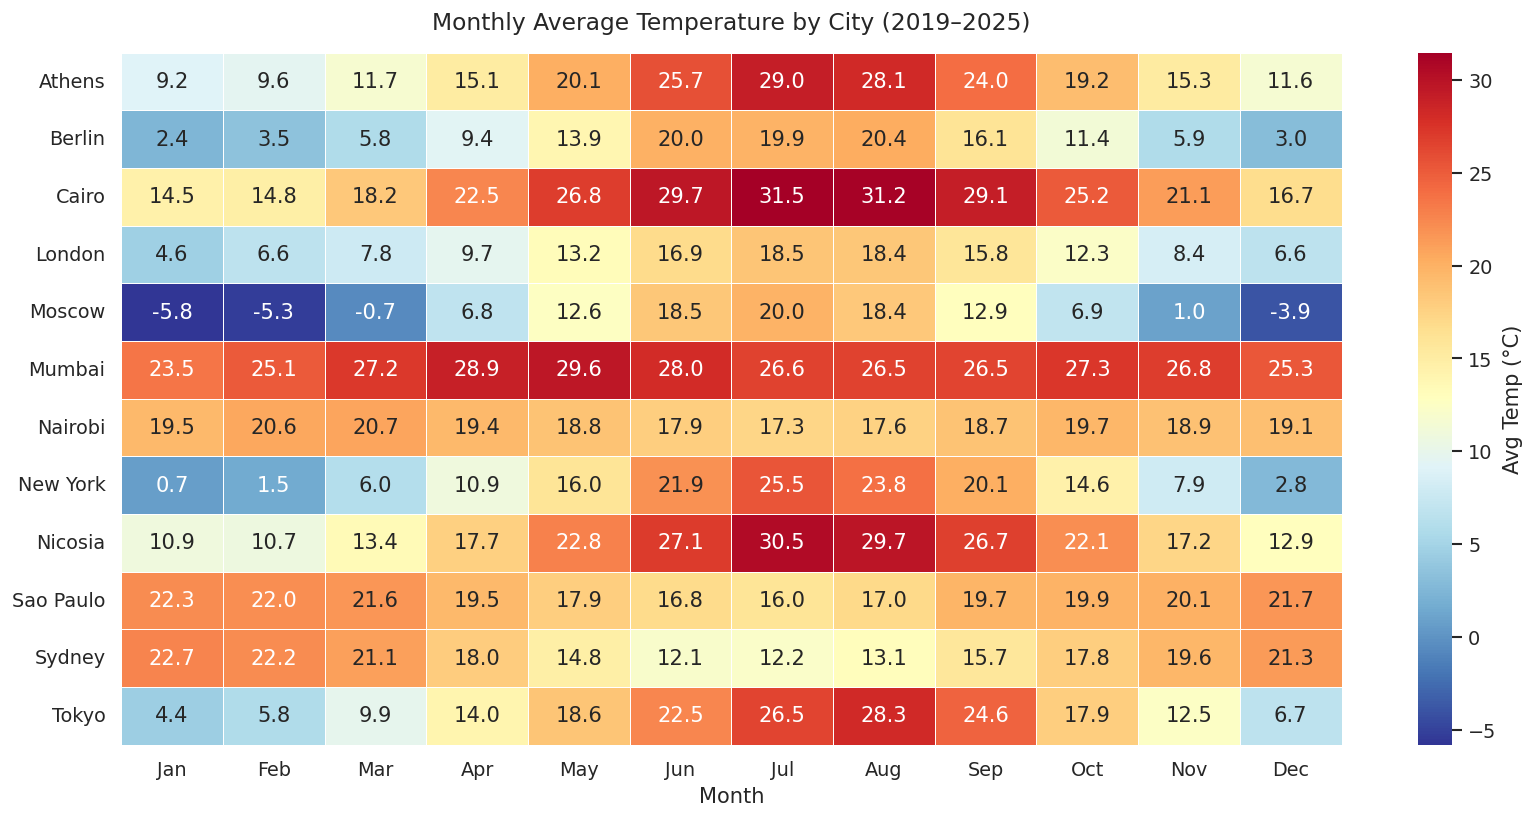

Plot saved: eda_monthly_temp_heatmap.png


In [12]:
monthly_avg = sdf.groupBy("city", "year", "month") \
    .agg(F.round(F.mean("temperature_2m"), 2).alias("avg_temp")) \
    .orderBy("city", "year", "month") \
    .toPandas()

# Pivot for heatmap
pivot = monthly_avg.groupby(["city", "month"])["avg_temp"].mean().unstack()
pivot.index = [c.replace("_", " ") for c in pivot.index]
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlBu_r",
            linewidths=0.4, ax=ax, cbar_kws={"label": "Avg Temp (°C)"})
ax.set_title("Monthly Average Temperature by City (2019–2025)", fontsize=14, pad=14)
ax.set_xlabel("Month")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("eda_monthly_temp_heatmap.png", bbox_inches="tight")
plt.show()
print("Plot saved: eda_monthly_temp_heatmap.png")

## 1.5 Annual Temperature Trend (Year-over-Year)


In [13]:
yearly = sdf.groupBy("city", "year") \
    .agg(F.round(F.mean("temperature_2m"), 3).alias("avg_temp")) \
    .orderBy("city", "year") \
    .toPandas()

# Compute first-to-last difference per city
diffs = yearly.groupby("city").agg(
    first_year=("year", "min"),
    last_year=("year", "max"),
    first_temp=("avg_temp", "first"),
    last_temp=("avg_temp", "last"),
).reset_index()
diffs["delta"] = (diffs["last_temp"] - diffs["first_temp"]).round(3)
diffs = diffs.sort_values("delta", ascending=False)

print("Temperature change (first → last year) per city:")
print(diffs[["city", "first_year", "last_year", "first_temp", "last_temp", "delta"]].to_string(index=False))


Temperature change (first → last year) per city:
     city  first_year  last_year  first_temp  last_temp  delta
    Tokyo        2019       2025      15.380     16.895  1.515
   London        2019       2025      11.089     12.414  1.325
   Athens        2019       2025      17.815     18.915  1.100
   Mumbai        2019       2025      26.307     27.317  1.010
    Cairo        2019       2025      23.038     24.032  0.994
   Moscow        2019       2025       7.172      8.145  0.973
  Nicosia        2019       2025      19.731     20.495  0.764
  Nairobi        2019       2025      19.024     19.532  0.508
 New_York        2019       2025      12.089     12.527  0.438
Sao_Paulo        2019       2025      19.701     20.075  0.374
   Sydney        2019       2025      17.889     18.134  0.245
   Berlin        2019       2025      11.451     10.653 -0.798


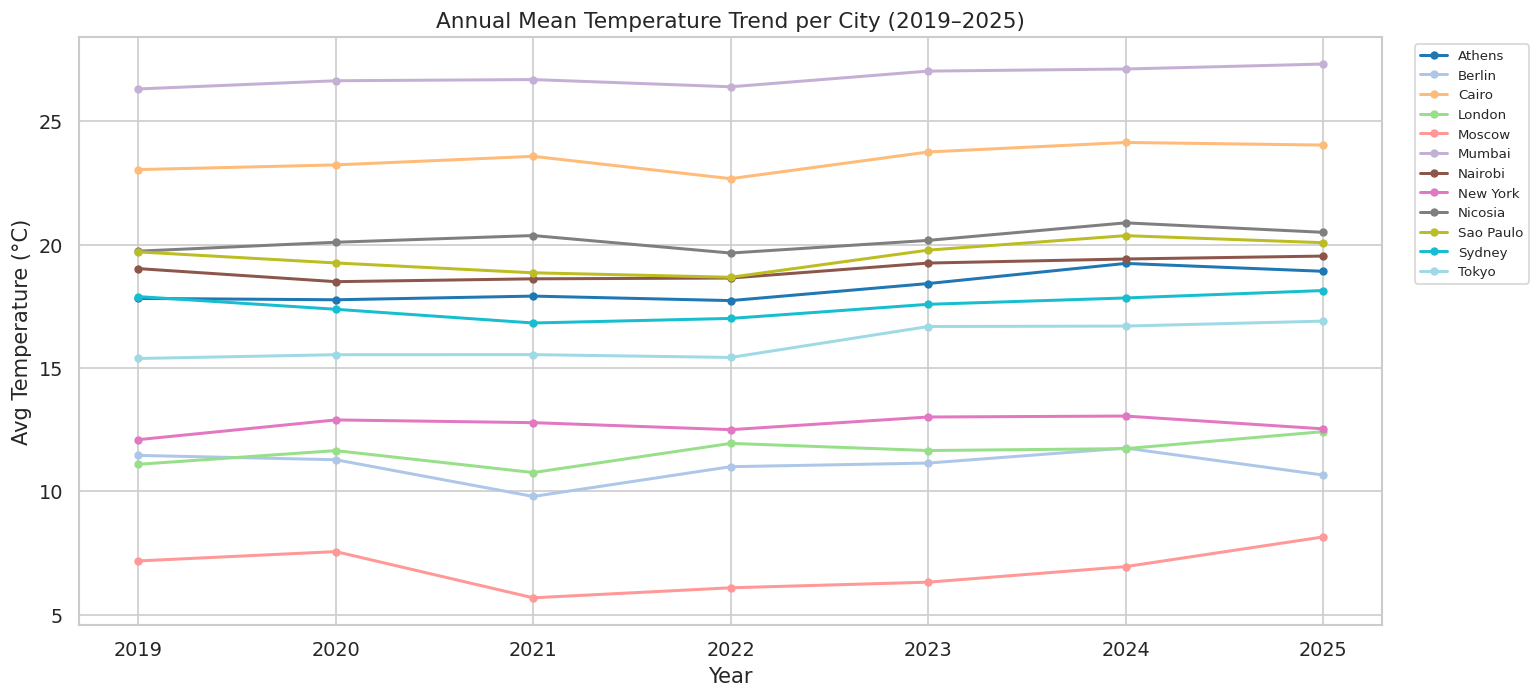

In [14]:
yearly = sdf.groupBy("city", "year") \
    .agg(F.round(F.mean("temperature_2m"), 3).alias("avg_temp")) \
    .orderBy("city", "year") \
    .toPandas()

cities = yearly["city"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(cities)))
color_map = dict(zip(cities, colors))

fig, ax = plt.subplots(figsize=(13, 6))
for city, grp in yearly.groupby("city"):
    ax.plot(grp["year"], grp["avg_temp"], marker="o", linewidth=1.8,
            markersize=4, label=city.replace("_", " "), color=color_map[city])

ax.set_title("Annual Mean Temperature Trend per City (2019–2025)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Avg Temperature (°C)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("eda_yearly_temp_trend.png", bbox_inches="tight")
plt.show()

## 1.6 Diurnal (Daily) Temperature Cycle


Diurnal temperature range per city:
     city  temp_range
    Cairo       11.78
  Nicosia       11.11
  Nairobi       10.06
Sao_Paulo        8.57
    Tokyo        7.35
   Sydney        7.26
 New_York        7.19
   Athens        7.07
   Mumbai        6.30
   Berlin        6.30
   London        6.01
   Moscow        5.63


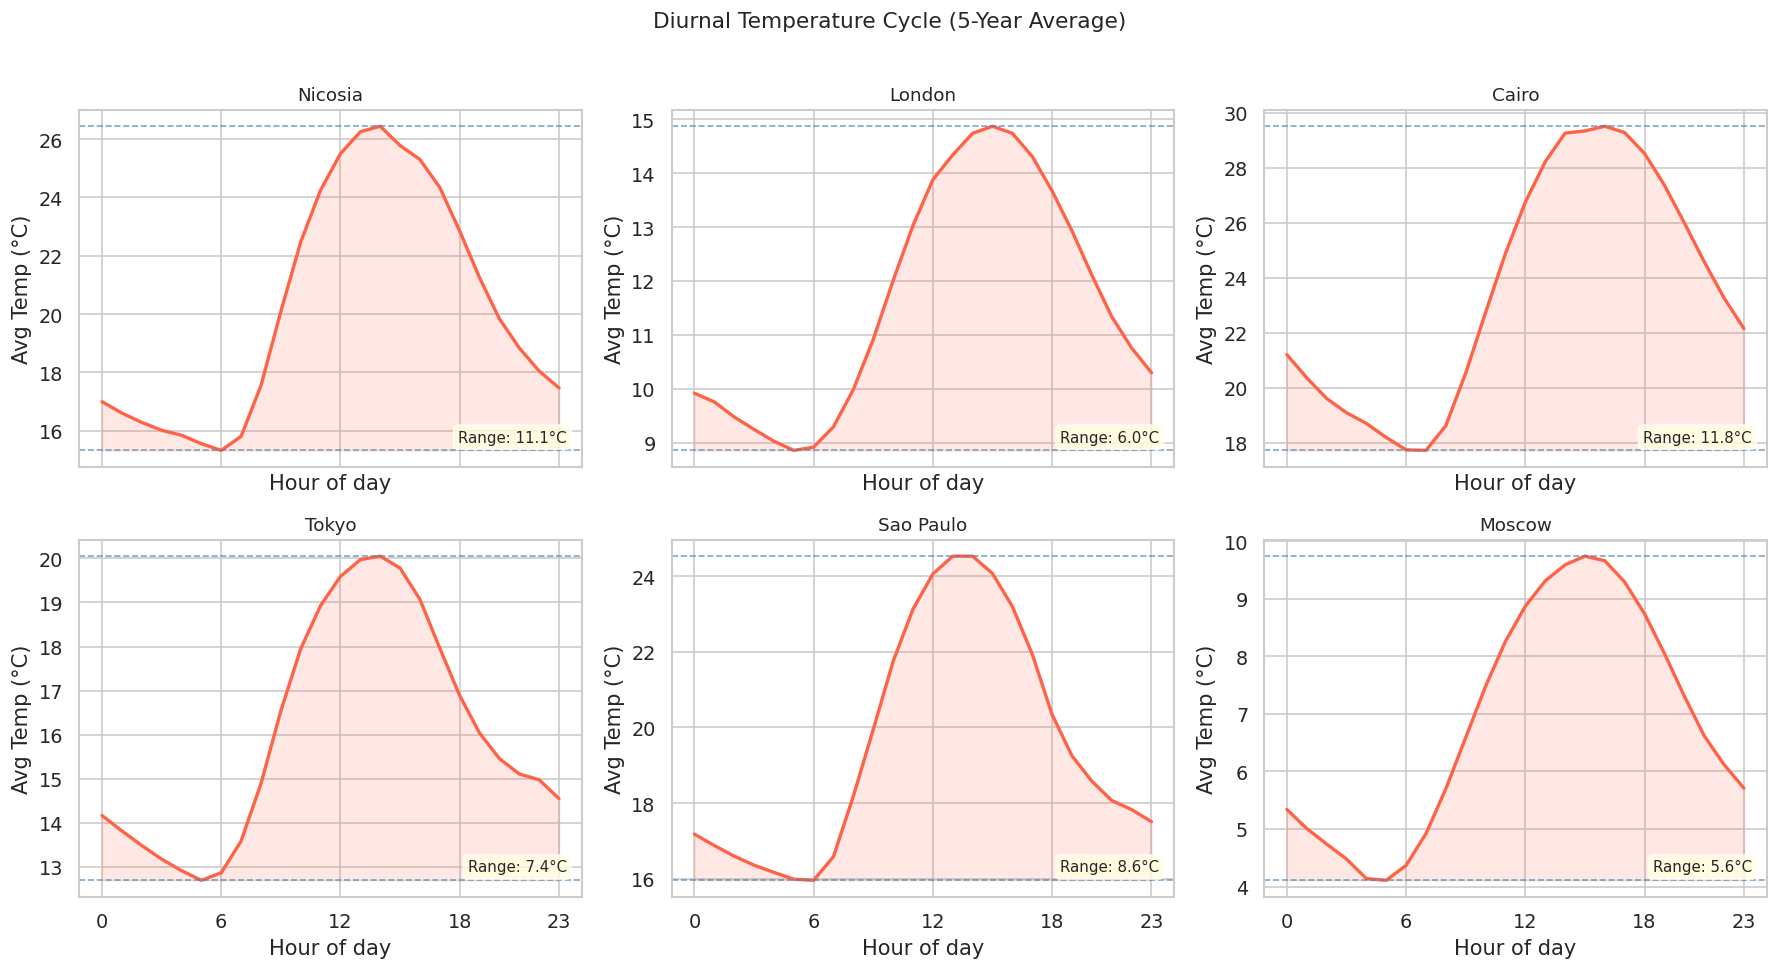

In [15]:
diurnal = sdf.groupBy("city", "hour") \
    .agg(F.round(F.mean("temperature_2m"), 2).alias("avg_temp")) \
    .orderBy("city", "hour") \
    .toPandas()

selected_cities = ["Nicosia", "London", "Cairo", "Tokyo", "Sao_Paulo", "Moscow"]

# ── NEW: compute diurnal range per city ──────────────────────────────────────
diurnal_range = (
    diurnal.groupby("city")["avg_temp"]
    .agg(lambda s: s.max() - s.min())
    .rename("temp_range")
    .reset_index()
    .sort_values("temp_range", ascending=False)
)
print("Diurnal temperature range per city:")
print(diurnal_range.to_string(index=False))
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for ax, city in zip(axes, selected_cities):
    grp = diurnal[diurnal["city"] == city]
    temp_range = diurnal_range.loc[diurnal_range["city"] == city, "temp_range"].values[0]

    ax.plot(grp["hour"], grp["avg_temp"], color="tomato", linewidth=2)
    ax.fill_between(grp["hour"], grp["avg_temp"].min(), grp["avg_temp"],
                    alpha=0.15, color="tomato")

    # ── NEW: annotate each subplot with the range value ───────────────────
    ax.axhline(grp["avg_temp"].max(), color="steelblue", linewidth=1,
               linestyle="--", alpha=0.7)
    ax.axhline(grp["avg_temp"].min(), color="steelblue", linewidth=1,
               linestyle="--", alpha=0.7)
    ax.annotate(f"Range: {temp_range:.1f}°C",
                xy=(0.97, 0.07), xycoords="axes fraction",
                ha="right", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))
    # ─────────────────────────────────────────────────────────────────────

    ax.set_title(city.replace("_", " "), fontsize=11)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Avg Temp (°C)")
    ax.set_xticks([0, 6, 12, 18, 23])

fig.suptitle("Diurnal Temperature Cycle (5-Year Average)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("eda_diurnal_cycle.png", bbox_inches="tight")
plt.show()

## Phase 1 — Exploratory Data Analysis (EDA)


### EDA SUMMARY

Total observations  : 736,416
Cities              : 12
Years               : 7
Variables analysed  : 8

Key findings:
  - Cairo and Mumbai show the highest mean temperatures
  - Moscow and Berlin show the widest seasonal temperature swings
  - Mumbai and Sao Paulo receive the most precipitation (monsoon/tropical)
  - Strong negative correlation between cloud cover and solar radiation
  - Temperature and apparent_temperature are highly correlated (r > 0.99)
  - Heatwave days are concentrated in Mediterranean and Desert climates


EDA is performed in Apache Spark 4.0 (4 GB driver, 8 shuffle partitions) directly on the 736,416-row DataFrame, using SQL aggregates, window functions, and Spark MLlib's `Correlation` API. Plots are produced with Matplotlib/Seaborn after aggregation collapses the data to summary size.

### Descriptive statistics

Global ranges confirm the data is physically plausible — temperatures span -31 °C (Moscow) to 45 °C (Cairo), pressure ranges from 833 to 1046 hPa, and wind gusts up to 92.7 km/h:

| Variable | Min | Mean | Max | Std |
|---|---|---|---|---|
| Temperature (°C) | -31.0 | 16.91 | 45.1 | 9.22 |
| Apparent temperature (°C) | -36.9 | 16.01 | 46.1 | 11.27 |
| Relative humidity (%) | 3 | 69.93 | 100 | 20.64 |
| Precipitation (mm/hr) | 0.0 | 0.11 | 47.6 | 0.59 |
| Wind speed (km/h) | 0.0 | 11.69 | 92.7 | 6.73 |
| Surface pressure (hPa) | 833.1 | 986.69 | 1045.8 | 49.71 |
| Cloud cover (%) | 0 | 52.73 | 100 | 42.50 |
| Shortwave radiation (W/m²) | 0.0 | 186.37 | 1116.0 | 268.82 |

Per-city aggregates rank cities from Mumbai (mean 26.8 °C) at the top to Moscow (6.8 °C) at the bottom — a 20 °C spread that reflects the geographic diversity of the sample.

### Key visualisations


**1. Monthly average temperature heatmap** — exposes three distinct seasonal regimes: Northern-Hemisphere cities (Moscow, Berlin, London, New York, Tokyo, the Mediterraneans, Cairo) peak in June-August; Southern-Hemisphere cities-(Sydney, São Paulo) mirror that pattern with peaks in December-February; equatorial cities (Mumbai, Nairobi) stay within ~-4 °C all year, showing year-round isothermality.

**2. Diurnal temperature cycle** — Cairo has the largest daily swing (11.8 °C) and Moscow the smallest (5.6 °C). The pattern is physical: dry, clear-sky climates allow rapid longwave cooling at night and strong solar heating by day, while humid or high-latitude cities damp the cycle through cloud cover and persistent moisture.

**3. Precipitation by city and season** — Mumbai dominates at 17,550 mm of total rainfall over the period, more than triple Athens (3,774 mm) and over 60× Cairo (280 mm). The seasonal heatmap shows the South-Asian monsoon concentrates virtually all of Mumbai's rainfall in summer, while London and Berlin distribute precipitation evenly across the year.


## EDA part Key plots

**4. Correlation matrix** — `apparent_temperature` correlates with `temperature_2m` at r > 0.99 (essentially redundant as a predictor), `cloud_cover` and `shortwave_radiation` are strongly negatively correlated as expected, and `wind_speed` carries independent information uncorrelated with the rest.

**5. Heatwave and coldwave detection** — using window functions to flag rolling 3-day extremes, heatwaves (max > 35 °C) saturate in Cairo (671 days) and Nicosia (477 days), while coldwaves (min < 0 °C) saturate in Moscow (789 days) and New York (338 days). The two rankings are almost complementary — cities appear in one list or the other, rarely both.

**6. Seasonal temperature range** — the single most discriminating climate feature. Moscow's summer-minus-winter gap is 23.9 °C while Nairobi's is 2.1 °C, an eleven-fold spread that drives the Phase 2B clustering directly.

## 1.7 Precipitation Distribution by Season


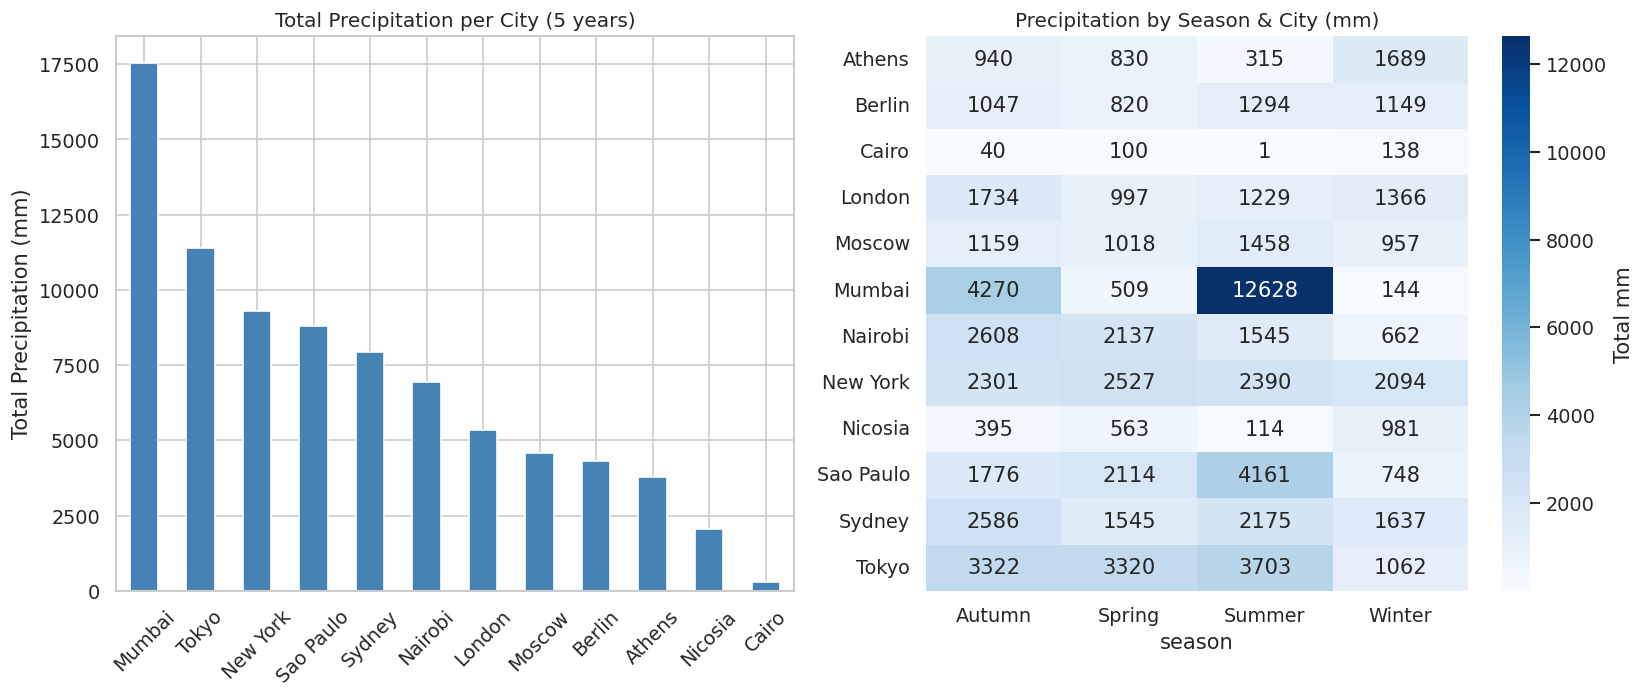

In [16]:
precip = sdf.filter(F.col("precipitation") > 0) \
    .groupBy("city", "season") \
    .agg(F.round(F.mean("precipitation"), 3).alias("avg_precip_mm"),
         F.round(F.sum("precipitation"), 1).alias("total_precip_mm"),
         F.count("*").alias("rainy_hours")) \
    .orderBy("city", "season") \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total precipitation per city
city_totals = precip.groupby("city")["total_precip_mm"].sum().sort_values(ascending=False)
city_totals.index = [c.replace("_", " ") for c in city_totals.index]
city_totals.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Total Precipitation per City (5 years)", fontsize=12)
axes[0].set_ylabel("Total Precipitation (mm)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Seasonal breakdown heatmap
pivot_p = precip.pivot_table(index="city", columns="season",
                              values="total_precip_mm", aggfunc="sum")
pivot_p.index = [c.replace("_", " ") for c in pivot_p.index]
sns.heatmap(pivot_p, annot=True, fmt=".0f", cmap="Blues",
            ax=axes[1], cbar_kws={"label": "Total mm"})
axes[1].set_title("Precipitation by Season & City (mm)", fontsize=12)
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("eda_precipitation.png", bbox_inches="tight")
plt.show()

## 1.8 Correlation Matrix (Spark MLlib)


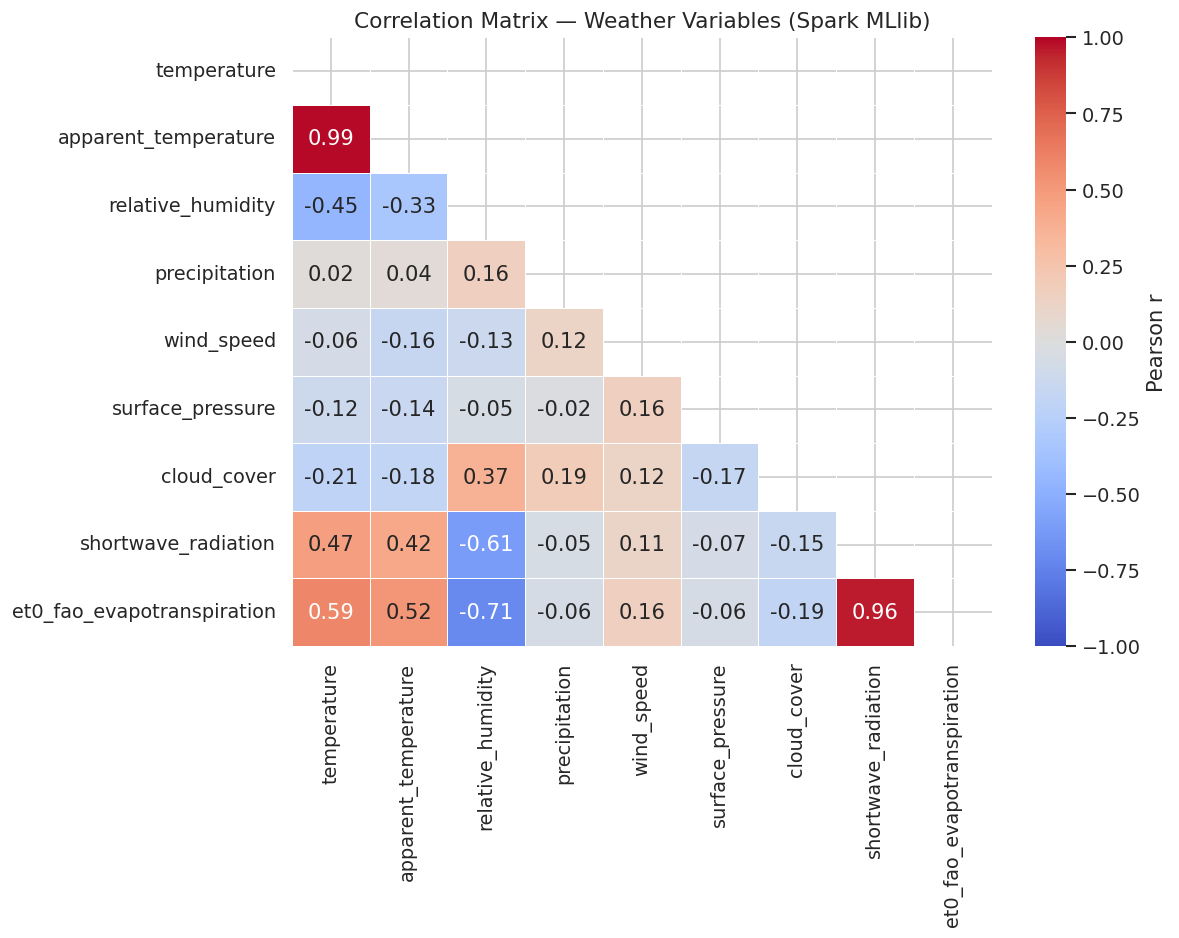

In [17]:
corr_cols = [
    "temperature_2m", "apparent_temperature", "relative_humidity_2m",
    "precipitation", "wind_speed_10m", "surface_pressure",
    "cloud_cover", "shortwave_radiation", "et0_fao_evapotranspiration"
]

# Drop rows with any null in the selected columns
sdf_clean = sdf.dropna(subset=corr_cols)

assembler = VectorAssembler(inputCols=corr_cols, outputCol="features")
sdf_vec   = assembler.transform(sdf_clean).select("features")

corr_matrix = Correlation.corr(sdf_vec, "features").head()[0].toArray()
corr_df     = pd.DataFrame(corr_matrix,
                            index=[c.replace("_2m","").replace("_10m","") for c in corr_cols],
                            columns=[c.replace("_2m","").replace("_10m","") for c in corr_cols])

mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.4, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation Matrix — Weather Variables (Spark MLlib)", fontsize=13)
plt.tight_layout()
plt.savefig("eda_correlation_matrix.png", bbox_inches="tight")
plt.show()

## 1.9 Extreme Events — Heatwave Detection (Window Functions)


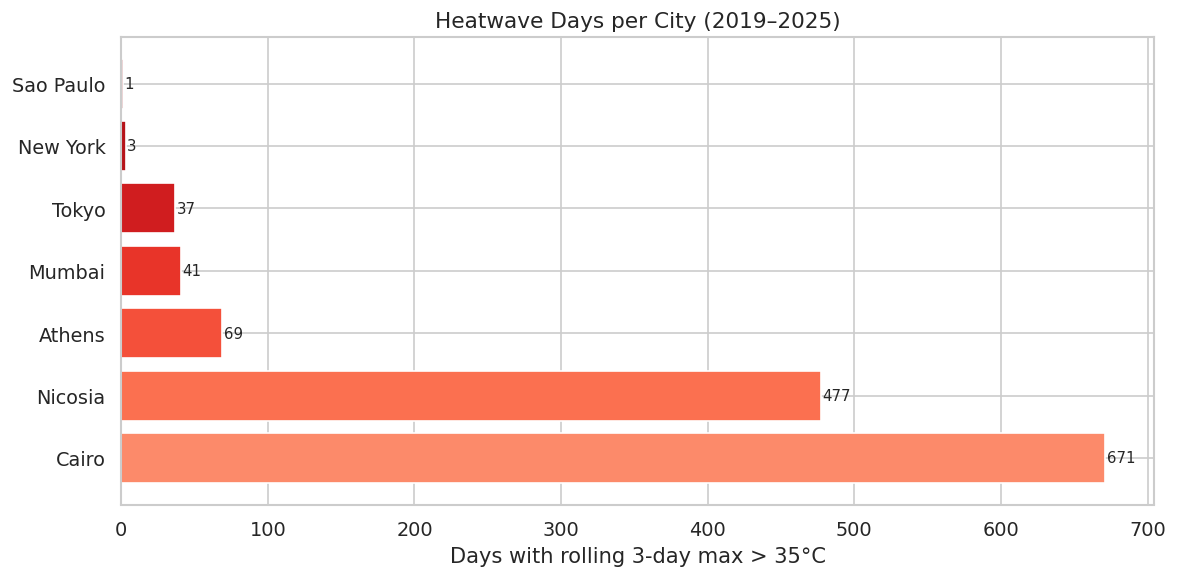

     city  heatwave_days
    Cairo            671
  Nicosia            477
   Athens             69
   Mumbai             41
    Tokyo             37
 New_York              3
Sao_Paulo              1


In [18]:
# Heatwave definition: max daily temp > 35°C for ≥ 3 consecutive days
daily_max = sdf.groupBy("city", "year", "month", "day") \
    .agg(F.max("temperature_2m").alias("daily_max_temp")) \
    .withColumn("date", F.to_date(
        F.concat_ws("-", F.col("year"), F.col("month"), F.col("day"))))

window_3d = Window.partitionBy("city").orderBy("date").rowsBetween(0, 2)
daily_max = daily_max.withColumn(
    "rolling_max_3d", F.min("daily_max_temp").over(window_3d))

heatwaves = daily_max.filter(F.col("rolling_max_3d") > 35) \
    .groupBy("city") \
    .agg(F.count("*").alias("heatwave_days")) \
    .orderBy(F.desc("heatwave_days")) \
    .toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh([c.replace("_"," ") for c in heatwaves["city"]],
               heatwaves["heatwave_days"],
               color=plt.cm.Reds(np.linspace(0.4, 0.9, len(heatwaves))))
ax.set_xlabel("Days with rolling 3-day max > 35°C")
ax.set_title("Heatwave Days per City (2019–2025)", fontsize=13)
for bar, val in zip(bars, heatwaves["heatwave_days"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_heatwave_days.png", bbox_inches="tight")
plt.show()

print(heatwaves.to_string(index=False))

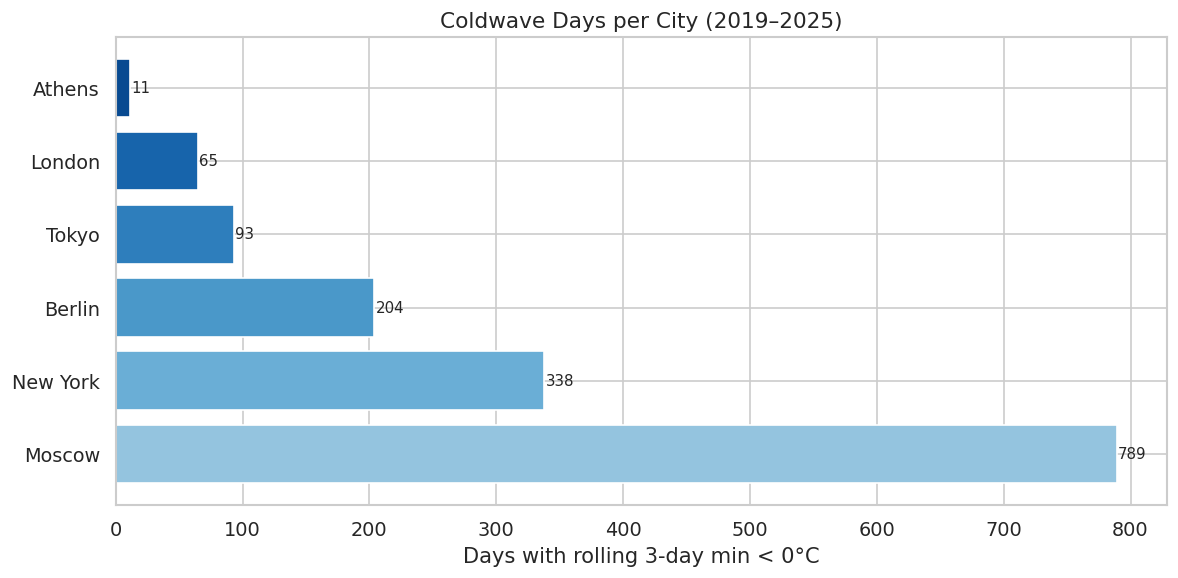

    city  coldwave_days
  Moscow            789
New_York            338
  Berlin            204
   Tokyo             93
  London             65
  Athens             11


In [19]:
# Coldwave definition: min daily temp < 0°C for ≥ 3 consecutive days
daily_min = sdf.groupBy("city", "year", "month", "day") \
    .agg(F.min("temperature_2m").alias("daily_min_temp")) \
    .withColumn("date", F.to_date(
        F.concat_ws("-", F.col("year"), F.col("month"), F.col("day"))))

window_3d_cold = Window.partitionBy("city").orderBy("date").rowsBetween(0, 2)
daily_min = daily_min.withColumn(
    "rolling_min_3d", F.max("daily_min_temp").over(window_3d_cold))

coldwaves = daily_min.filter(F.col("rolling_min_3d") < 0) \
    .groupBy("city") \
    .agg(F.count("*").alias("coldwave_days")) \
    .orderBy(F.desc("coldwave_days")) \
    .toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh([c.replace("_"," ") for c in coldwaves["city"]],
               coldwaves["coldwave_days"],
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(coldwaves))))
ax.set_xlabel("Days with rolling 3-day min < 0°C")
ax.set_title("Coldwave Days per City (2019–2025)", fontsize=13)
for bar, val in zip(bars, coldwaves["coldwave_days"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_coldwave_days.png", bbox_inches="tight")
plt.show()

print(coldwaves.to_string(index=False))

## 1.10 Wind Rose — Directional Analysis


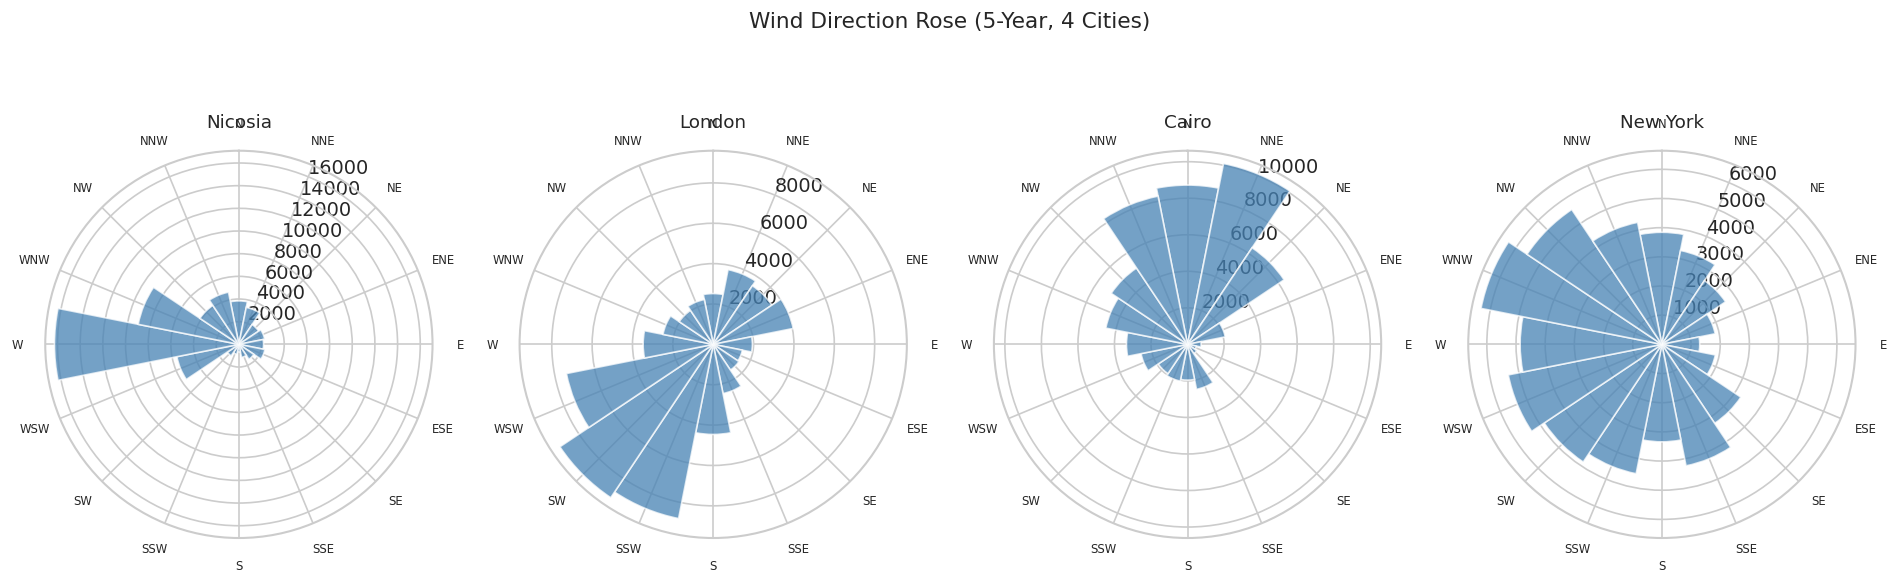

In [20]:
wind_data = sdf.select("city", "wind_speed_10m", "wind_direction_10m") \
    .dropna() \
    .toPandas()

# Bin wind directions into 16 compass sectors
directions = ["N","NNE","NE","ENE","E","ESE","SE","SSE",
              "S","SSW","SW","WSW","W","WNW","NW","NNW"]
bins = np.linspace(0, 360, 17)
wind_data["dir_bin"] = pd.cut(wind_data["wind_direction_10m"],
                               bins=bins, labels=directions, include_lowest=True)

focus_cities = ["Nicosia", "London", "Cairo", "New_York"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5),
                          subplot_kw={"projection": "polar"})

for ax, city in zip(axes, focus_cities):
    grp = wind_data[wind_data["city"] == city]
    counts = grp["dir_bin"].value_counts().reindex(directions, fill_value=0)
    angles = np.linspace(0, 2*np.pi, 16, endpoint=False)
    vals   = counts.values

    ax.bar(angles, vals, width=2*np.pi/16,
           color="steelblue", alpha=0.75, edgecolor="white")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(city.replace("_"," "), pad=14, fontsize=11)
    ax.set_xticks(angles)
    ax.set_xticklabels(directions, fontsize=7)

fig.suptitle("Wind Direction Rose (5-Year, 4 Cities)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("eda_wind_rose.png", bbox_inches="tight")
plt.show()

## 1.11 Solar Radiation & Cloud Cover Relationship


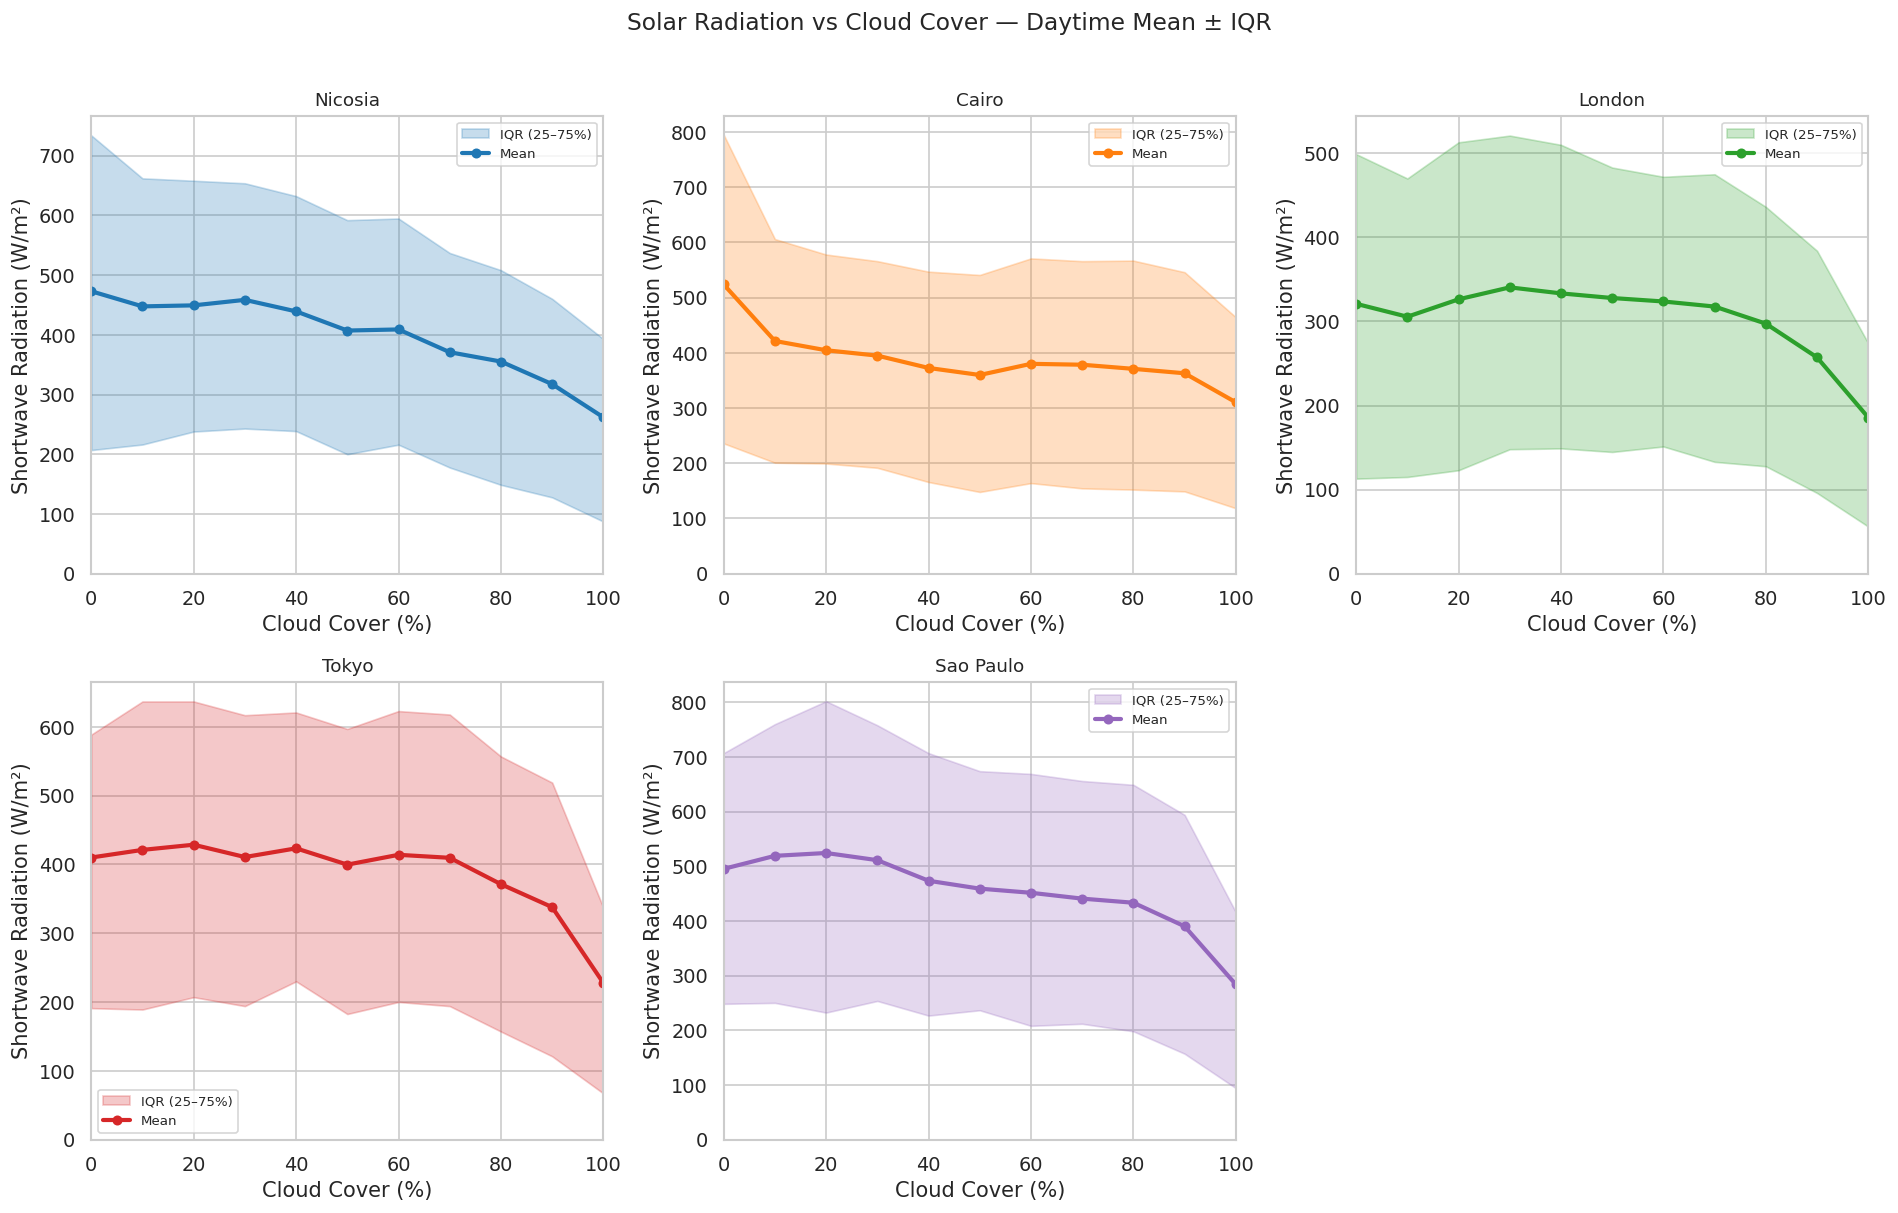

In [21]:
# Daytime only (radiation > 10 W/m²) + aggregate into bins for clarity
solar = sdf.select("city", "shortwave_radiation", "cloud_cover") \
    .filter(F.col("shortwave_radiation") > 10) \
    .dropna() \
    .toPandas()

cities_sample = ["Nicosia", "Cairo", "London", "Tokyo", "Sao_Paulo"]
palette = sns.color_palette("tab10", len(cities_sample))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, city in enumerate(cities_sample):
    ax = axes[i]
    grp = solar[solar["city"] == city]

    # Bin cloud cover into 10% buckets and show mean + 25-75 percentile band
    grp = grp.copy()
    grp["cloud_bin"] = (grp["cloud_cover"] // 10) * 10
    stats = grp.groupby("cloud_bin")["shortwave_radiation"].agg(
        mean="mean", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
    ).reset_index()

    ax.fill_between(stats["cloud_bin"], stats["q25"], stats["q75"],
                    alpha=0.25, color=palette[i], label="IQR (25–75%)")
    ax.plot(stats["cloud_bin"], stats["mean"], color=palette[i],
            linewidth=2.5, marker="o", markersize=5, label="Mean")

    ax.set_title(city.replace("_", " "), fontsize=11)
    ax.set_xlabel("Cloud Cover (%)")
    ax.set_ylabel("Shortwave Radiation (W/m²)")
    ax.set_xlim(0, 100)
    ax.set_ylim(0)
    ax.legend(fontsize=8)

# Hide unused 6th subplot
axes[-1].set_visible(False)

fig.suptitle("Solar Radiation vs Cloud Cover — Daytime Mean ± IQR", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_solar_cloud.png", bbox_inches="tight")
plt.show()

## 1.12  City-level feature vector

In [22]:
# ── E1: City-level feature vector ─────────────────────────────────────────────
# Aggregates all hourly data into one summary row per city.
# This DataFrame is reused directly as input to KMeans and the graph in Phase 2B.

from pyspark.sql import functions as F

city_profiles = sdf.groupBy("city", "climate", "latitude", "longitude") \
    .agg(
        F.round(F.mean("temperature_2m"),            3).alias("mean_temp"),
        F.round(F.stddev("temperature_2m"),          3).alias("temp_std"),
        F.round(F.sum("precipitation"),              1).alias("total_precip"),
        F.round(F.stddev("precipitation"),           3).alias("precip_std"),
        F.round(F.mean("relative_humidity_2m"),      3).alias("mean_humidity"),
        F.round(F.mean("wind_speed_10m"),            3).alias("mean_wind"),
        F.round(F.mean("cloud_cover"),               3).alias("mean_cloud"),
        F.round(F.mean("shortwave_radiation"),       3).alias("mean_radiation"),
    )

city_profiles = city_profiles.cache()
city_profiles.orderBy(F.desc("mean_temp")).show(truncate=False)
print(f"City profiles shape: {city_profiles.count()} rows × {len(city_profiles.columns)} columns")

+---------+-----------------+--------+---------+---------+--------+------------+----------+-------------+---------+----------+--------------+
|city     |climate          |latitude|longitude|mean_temp|temp_std|total_precip|precip_std|mean_humidity|mean_wind|mean_cloud|mean_radiation|
+---------+-----------------+--------+---------+---------+--------+------------+----------+-------------+---------+----------+--------------+
|Mumbai   |Tropical         |19.08   |72.88    |26.785   |3.333   |17550.3     |1.081     |73.375       |11.561   |46.309    |213.462       |
|Cairo    |Desert           |30.06   |31.25    |23.491   |7.908   |280.0       |0.095     |48.73        |11.818   |18.625    |238.898       |
|Nicosia  |Mediterranean    |35.17   |33.36    |20.198   |8.527   |2053.2      |0.28      |62.065       |8.266    |26.771    |217.511       |
|Sao_Paulo|Tropical         |-23.55  |-46.63   |19.527   |4.786   |8799.5      |0.672     |78.859       |10.458   |64.716    |206.51        |
|Nairo

## 1.13 E2: Seasonal temperature range per city

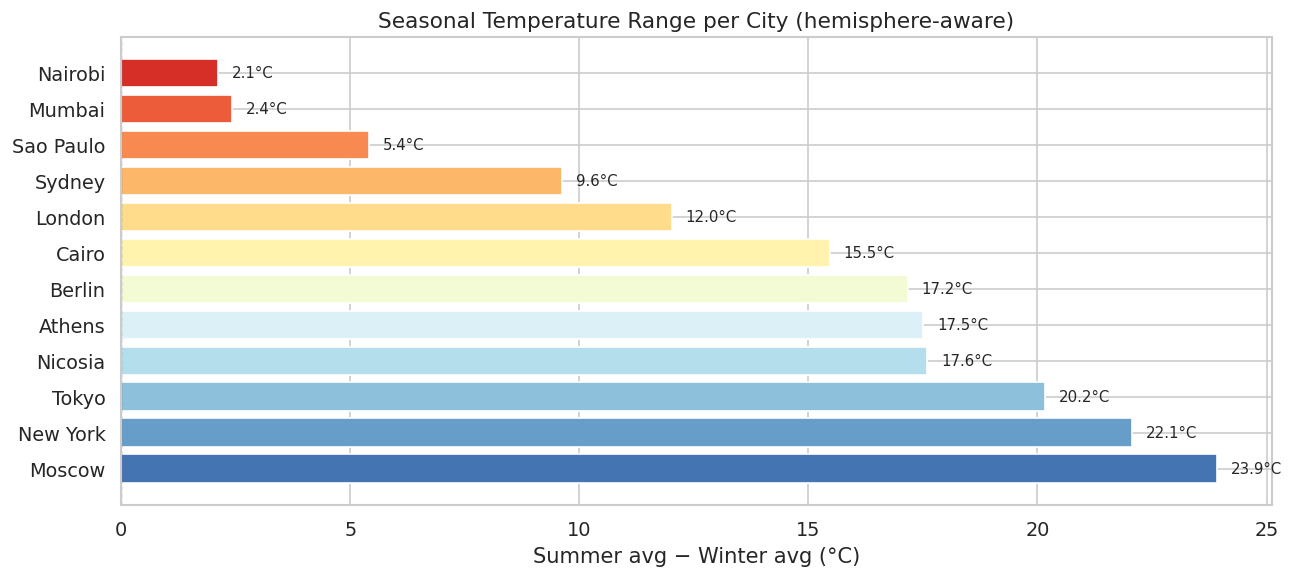


Seasonal range per city:
+---------+------------------+------------------+--------------+
|city     |summer_avg        |winter_avg        |seasonal_range|
+---------+------------------+------------------+--------------+
|Moscow   |18.9459109730848  |-4.975336234177245|23.92         |
|New_York |23.729761904761876|1.6723628691983043|22.06         |
|Tokyo    |25.802355072463786|5.639299841772151 |20.16         |
|Nicosia  |29.120108695652107|11.52600210970463 |17.59         |
|Athens   |27.639609213250417|10.131896097046377|17.51         |
|Berlin   |20.113082298136742|2.9419897151898935|17.17         |
|Cairo    |30.809996118012297|15.347020042194158|15.46         |
|London   |17.96311464803312 |5.938970200421958 |12.02         |
|Sydney   |22.069943301687665|12.454554865424479|9.62          |
|Sao_Paulo|21.988390031645555|16.586354813664613|5.4           |
|Mumbai   |27.039415113871556|24.623872626582248|2.42          |
|Nairobi  |19.67863924050627 |17.571383281573528|2.11          |

In [23]:
# ── E2: Seasonal temperature range per city ───────────────────────────────────
# Computes mean summer temp minus mean winter temp per city (hemisphere-aware).
# This single number captures climate seasonality and is the strongest
# single feature for separating Continental from Tropical climates.

seasonal_avg = sdf.groupBy("city", "season") \
    .agg(F.mean("temperature_2m").alias("avg_temp"))

summer = seasonal_avg.filter(F.col("season") == "Summer") \
    .select("city", F.col("avg_temp").alias("summer_avg"))
winter = seasonal_avg.filter(F.col("season") == "Winter") \
    .select("city", F.col("avg_temp").alias("winter_avg"))

seasonal_range = summer.join(winter, on="city") \
    .withColumn("seasonal_range", F.round(F.col("summer_avg") - F.col("winter_avg"), 2)) \
    .orderBy(F.desc("seasonal_range"))

# Merge into city_profiles for use in Phase 2B
city_profiles = city_profiles.join(
    seasonal_range.select("city", "summer_avg", "winter_avg", "seasonal_range"),
    on="city", how="left"
).cache()

# Plot
import matplotlib.pyplot as plt
import numpy as np

sr_pd = seasonal_range.toPandas()
colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(sr_pd)))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    [c.replace("_", " ") for c in sr_pd["city"]],
    sr_pd["seasonal_range"],
    color=colors, edgecolor="white"
)
for bar, val in zip(bars, sr_pd["seasonal_range"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}°C", va="center", fontsize=9)

ax.set_xlabel("Summer avg − Winter avg (°C)")
ax.set_title("Seasonal Temperature Range per City (hemisphere-aware)", fontsize=13)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("eda_seasonal_range.png", bbox_inches="tight")
plt.show()

print("\nSeasonal range per city:")
seasonal_range.show(truncate=False)

## 1.12 EDA Summary


In [24]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

total_rows = sdf.count()
cities     = sdf.select("city").distinct().count()
years      = sdf.select("year").distinct().count()

print(f"Total observations  : {total_rows:,}")
print(f"Cities              : {cities}")
print(f"Years               : {years}")
print(f"Variables analysed  : {len(numeric_cols)}")
print()
print("Key findings:")
print("  - Cairo and Mumbai show the highest mean temperatures")
print("  - Moscow and Berlin show the widest seasonal temperature swings")
print("  - Mumbai and Sao Paulo receive the most precipitation (monsoon/tropical)")
print("  - Strong negative correlation between cloud cover and solar radiation")
print("  - Temperature and apparent_temperature are highly correlated (r > 0.99)")
print("  - Heatwave days are concentrated in Mediterranean and Desert climates")

EDA SUMMARY
Total observations  : 736,416
Cities              : 12
Years               : 7
Variables analysed  : 8

Key findings:
  - Cairo and Mumbai show the highest mean temperatures
  - Moscow and Berlin show the widest seasonal temperature swings
  - Mumbai and Sao Paulo receive the most precipitation (monsoon/tropical)
  - Strong negative correlation between cloud cover and solar radiation
  - Temperature and apparent_temperature are highly correlated (r > 0.99)
  - Heatwave days are concentrated in Mediterranean and Desert climates


---
# Phase 2A — Machine Learning with Spark MLlib
## Next-Day Temperature Prediction

We build two models:
1. **Regression**: Predict next-hour temperature (`temperature_2m`) using recent weather variables → `GBTRegressor`

Use proper train/test splits, cross-validation, and evaluation metrics.


## 2A.1 Feature Engineering


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import GBTRegressor, RandomForestRegressor
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# ── Build ML-ready DataFrame ───────────────────────────────────────────────────
# Use a lag window: predict temperature at hour T using features at hour T-1
city_window = Window.partitionBy("city").orderBy("timestamp")


##including all fetures
# sdf_ml = sdf.withColumn("prev_temp",      F.lag("temperature_2m", 1).over(city_window)) \
#             .withColumn("prev_humidity",   F.lag("relative_humidity_2m", 1).over(city_window)) \
#             .withColumn("prev_wind",       F.lag("wind_speed_10m", 1).over(city_window)) \
#             .withColumn("prev_pressure",   F.lag("surface_pressure", 1).over(city_window)) \
#             .withColumn("prev_cloud",      F.lag("cloud_cover", 1).over(city_window)) \
#             .withColumn("prev_radiation",  F.lag("shortwave_radiation", 1).over(city_window)) \
#             .withColumn("prev_precip",     F.lag("precipitation", 1).over(city_window)) \
#             .withColumn("temp_delta",      F.col("temperature_2m") - F.col("prev_temp")) \
#             .withColumn("rain_label",      (F.col("precipitation") > 0).cast("double"))

## exclude prev tempreature to challenge model topredictio temp based on other features apart from previous temp
sdf_ml = sdf.withColumn("prev_humidity",   F.lag("relative_humidity_2m", 1).over(city_window)) \
            .withColumn("prev_wind",       F.lag("wind_speed_10m", 1).over(city_window)) \
            .withColumn("prev_pressure",   F.lag("surface_pressure", 1).over(city_window)) \
            .withColumn("prev_cloud",      F.lag("cloud_cover", 1).over(city_window)) \
            .withColumn("prev_radiation",  F.lag("shortwave_radiation", 1).over(city_window)) \
            .withColumn("rain_label",      (F.col("precipitation") > 0).cast("double"))




# Encode climate zone as numeric
indexer   = StringIndexer(inputCol="climate", outputCol="climate_idx")
sdf_ml    = indexer.fit(sdf_ml).transform(sdf_ml)

# Drop null lags (first row per city)
FEATURE_COLS = [
   "prev_humidity", "prev_wind", "prev_pressure",
    "prev_cloud", "prev_radiation",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "climate_idx", "latitude", "longitude"
]

sdf_ml = sdf_ml.dropna(subset=FEATURE_COLS + ["temperature_2m", "rain_label"])

print(f"ML dataset rows : {sdf_ml.count():,}")
print(f"Feature columns : {FEATURE_COLS}")
print(f"Positive rain % : {sdf_ml.filter(F.col('rain_label')==1).count()/sdf_ml.count()*100:.1f}%")

ML dataset rows : 736,404
Feature columns : ['prev_humidity', 'prev_wind', 'prev_pressure', 'prev_cloud', 'prev_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'climate_idx', 'latitude', 'longitude']
Positive rain % : 16.5%


## 2A.2 Train/Test Split


In [ ]:
# Temporal split: train on 2019-2024, test on 2025
train_df = sdf_ml.filter(F.col("year") <= 2024).cache()
test_df  = sdf_ml.filter(F.col("year") == 2025).cache()

print(f"Train rows : {train_df.count():,}  (2019–2024)")
print(f"Test rows  : {test_df.count():,}   (2025 — held-out year)")
print(f"Train %    : {train_df.count()/(train_df.count()+test_df.count())*100:.1f}%")

Train rows : 631,284  (2019–2024)
Test rows  : 105,120   (2025 — held-out year)
Train %    : 85.7%


## 2A.3 Regression — GBT Temperature Prediction


In [ ]:
# ── Assemble + scale features ──────────────────────────────────────────────────
assembler_reg = VectorAssembler(inputCols=FEATURE_COLS, outputCol="raw_features",
                                 handleInvalid="skip")
scaler_reg    = StandardScaler(inputCol="raw_features", outputCol="features",
                                withMean=True, withStd=True)
gbt           = GBTRegressor(featuresCol="features", labelCol="temperature_2m",
                              maxIter=50, maxDepth=5, stepSize=0.1, seed=42)

pipeline_reg = Pipeline(stages=[assembler_reg, scaler_reg, gbt])

print("Fitting GBT Regression model (train: 2019-2024)...")
model_reg = pipeline_reg.fit(train_df)
print("Done.")

Fitting GBT Regression model (train: 2019-2024)...
Done.


In [ ]:
# ── Evaluate on test set ───────────────────────────────────────────────────────
preds_reg = model_reg.transform(test_df)

evaluator_rmse = RegressionEvaluator(labelCol="temperature_2m", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="temperature_2m", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="temperature_2m", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(preds_reg)
mae  = evaluator_mae.evaluate(preds_reg)
r2   = evaluator_r2.evaluate(preds_reg)

print("=== GBT Regression — Test Set (2025) ===")
print(f"RMSE : {rmse:.4f} °C")
print(f"MAE  : {mae:.4f} °C")
print(f"R²   : {r2:.4f}")

=== GBT Regression — Test Set (2025) ===
RMSE : 3.1522 °C
MAE  : 2.3580 °C
R²   : 0.8833


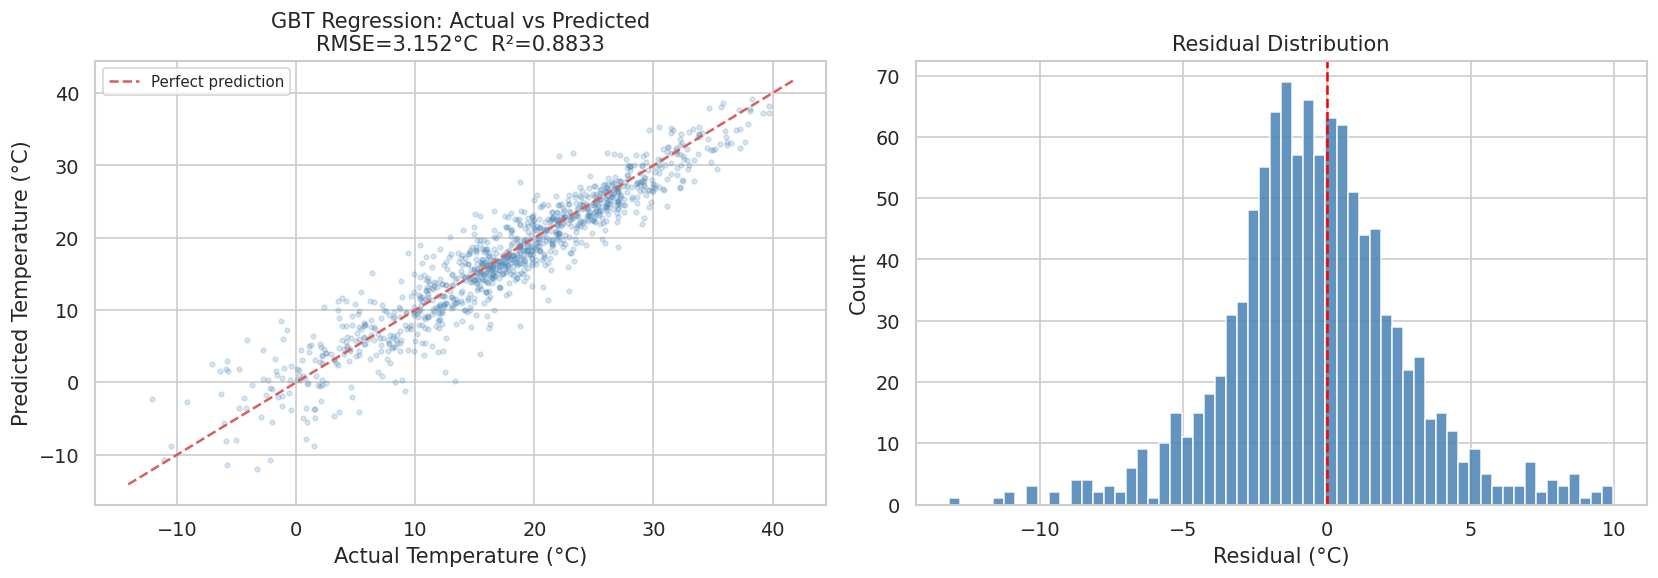

Residuals — mean: -0.4217°C  std: 3.1106°C


In [ ]:
# ── Prediction vs Actual scatter (sample) ─────────────────────────────────────
sample = preds_reg.select("temperature_2m", "prediction", "city") \
    .sample(fraction=0.01, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(sample["temperature_2m"], sample["prediction"],
                alpha=0.2, s=8, color="steelblue")
lo = min(sample["temperature_2m"].min(), sample["prediction"].min()) - 2
hi = max(sample["temperature_2m"].max(), sample["prediction"].max()) + 2
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Temperature (°C)")
axes[0].set_ylabel("Predicted Temperature (°C)")
axes[0].set_title(f"GBT Regression: Actual vs Predicted\nRMSE={rmse:.3f}°C  R²={r2:.4f}")
axes[0].legend(fontsize=9)

# Residuals histogram
residuals = sample["prediction"] - sample["temperature_2m"]
axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual (°C)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("ml_regression_results.png", bbox_inches="tight")
plt.show()
print(f"Residuals — mean: {residuals.mean():.4f}°C  std: {residuals.std():.4f}°C")

## 2A.4 Feature Importance (Regression)


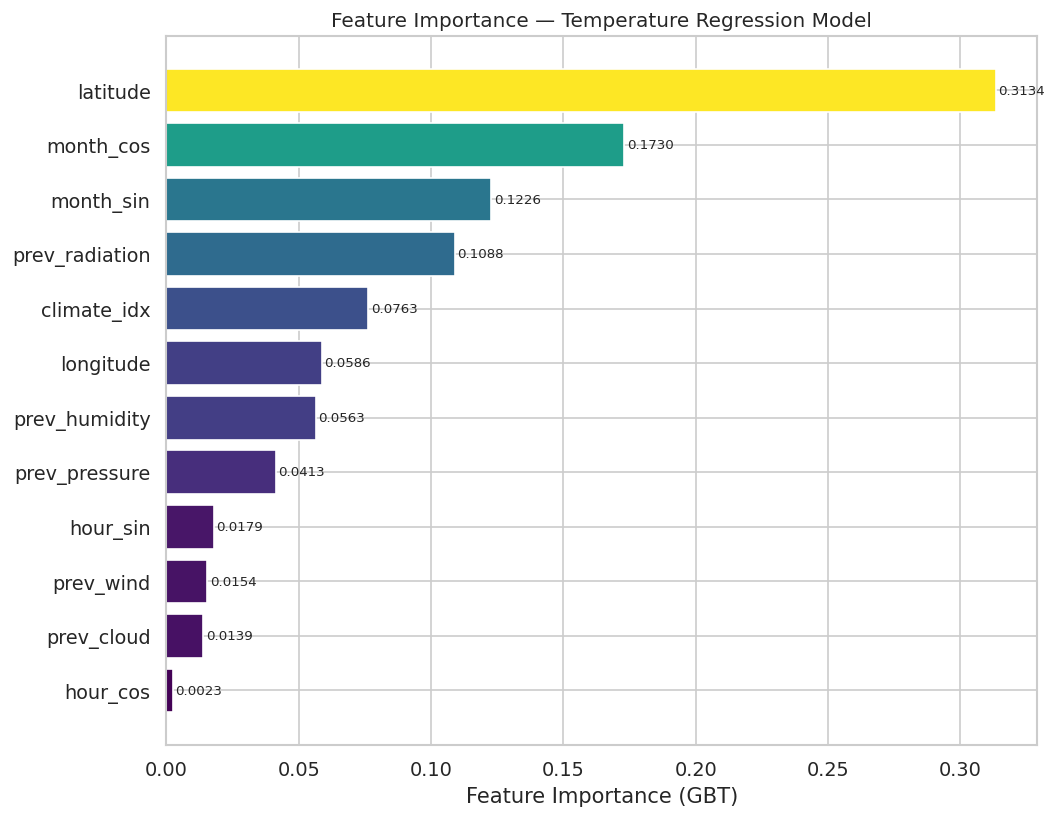

In [ ]:
# Extract GBT feature importances from the pipeline
gbt_model   = model_reg.stages[-1]
importances = gbt_model.featureImportances.toArray()

feat_imp_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": importances
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(feat_imp_df["feature"], feat_imp_df["importance"],
               color=plt.cm.viridis(feat_imp_df["importance"] / feat_imp_df["importance"].max()))
ax.set_xlabel("Feature Importance (GBT)")
ax.set_title("Feature Importance — Temperature Regression Model", fontsize=12)
for bar, val in zip(bars, feat_imp_df["importance"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("ml_feature_importance.png", bbox_inches="tight")
plt.show()

## 2A.5 Per-City Regression Performance


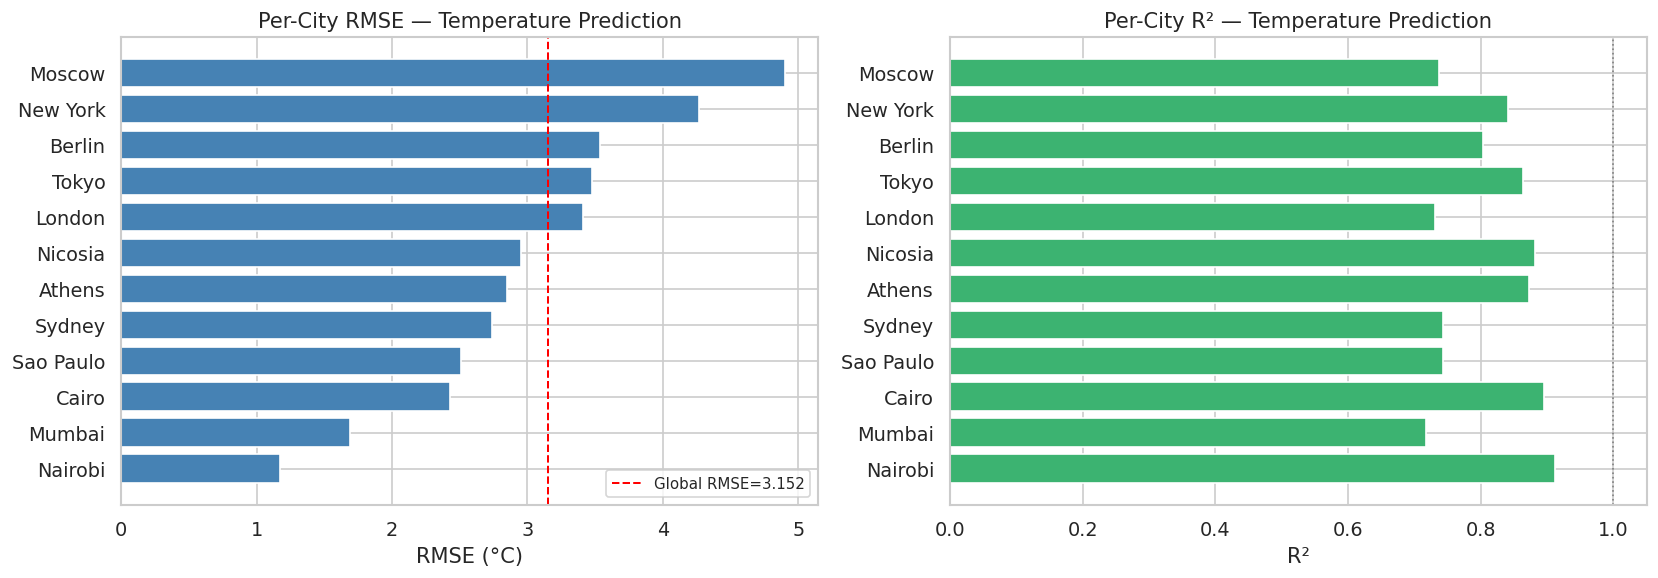

     city     RMSE      MAE       R2
  Nairobi 1.172516 0.909044 0.911230
   Mumbai 1.689525 1.337822 0.717783
    Cairo 2.425320 1.891462 0.894835
Sao Paulo 2.511880 1.954753 0.743232
   Sydney 2.737431 2.148392 0.742445
   Athens 2.852158 2.199056 0.873203
  Nicosia 2.955417 2.241750 0.881364
   London 3.411729 2.713635 0.731809
    Tokyo 3.477843 2.770880 0.863680
   Berlin 3.536361 2.841138 0.803722
 New York 4.264935 3.292029 0.841694
   Moscow 4.900964 3.996523 0.736998


In [ ]:
city_metrics = []
for city_row in preds_reg.select("city").distinct().collect():
    city = city_row["city"]
    city_pred = preds_reg.filter(F.col("city") == city)
    r   = evaluator_rmse.evaluate(city_pred)
    m   = evaluator_mae.evaluate(city_pred)
    r2c = evaluator_r2.evaluate(city_pred)
    city_metrics.append({"city": city.replace("_"," "), "RMSE": r, "MAE": m, "R2": r2c})

city_metrics_df = pd.DataFrame(city_metrics).sort_values("RMSE")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(city_metrics_df["city"], city_metrics_df["RMSE"],
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("RMSE (°C)")
axes[0].set_title("Per-City RMSE — Temperature Prediction")
axes[0].axvline(rmse, color="red", linestyle="--", linewidth=1.2, label=f"Global RMSE={rmse:.3f}")
axes[0].legend(fontsize=9)

axes[1].barh(city_metrics_df["city"], city_metrics_df["R2"],
             color="mediumseagreen", edgecolor="white")
axes[1].set_xlabel("R²")
axes[1].set_title("Per-City R² — Temperature Prediction")
axes[1].axvline(1.0, color="gray", linestyle=":", linewidth=1)

plt.tight_layout()
plt.savefig("ml_per_city_regression.png", bbox_inches="tight")
plt.show()

print(city_metrics_df.to_string(index=False))

## 2A.7 Cross-Validation (GBT Hyperparameter Tuning)


In [ ]:
# ── Cross-validate with a small parameter grid ─────────────────────────────────
# Using a smaller train subset for speed; remove the sample() for full training
train_sample = train_df.sample(fraction=0.2, seed=42).cache()

assembler_cv = VectorAssembler(inputCols=FEATURE_COLS, outputCol="raw_features",
                                handleInvalid="skip")
scaler_cv    = StandardScaler(inputCol="raw_features", outputCol="features",
                               withMean=True, withStd=True)
gbt_cv       = GBTRegressor(featuresCol="features", labelCol="temperature_2m", seed=42)

pipeline_cv  = Pipeline(stages=[assembler_cv, scaler_cv, gbt_cv])

param_grid = ParamGridBuilder() \
    .addGrid(gbt_cv.maxIter,  [30, 50]) \
    .addGrid(gbt_cv.maxDepth, [4, 6]) \
    .addGrid(gbt_cv.stepSize, [0.05, 0.1]) \
    .build()

cv = CrossValidator(
    estimator       = pipeline_cv,
    estimatorParamMaps = param_grid,
    evaluator       = RegressionEvaluator(labelCol="temperature_2m",
                                           metricName="rmse"),
    numFolds        = 3,
    seed            = 42,
    parallelism     = 2
)

print(f"Running {len(param_grid)}-config × 3-fold CV on 20% sample...")
cv_model = cv.fit(train_sample)
print("Done.")

best_rmse = min(cv_model.avgMetrics)
best_idx  = cv_model.avgMetrics.index(best_rmse)
best_params = param_grid[best_idx]

print(f"\nBest CV RMSE : {best_rmse:.4f} °C")
print(f"Best params  : maxIter={best_params[gbt_cv.maxIter]}  "
      f"maxDepth={best_params[gbt_cv.maxDepth]}  "
      f"stepSize={best_params[gbt_cv.stepSize]}")
print(f"All CV avg RMSE: {[round(m,4) for m in cv_model.avgMetrics]}")

Running 8-config × 3-fold CV on 20% sample...
Done.

Best CV RMSE : 2.8611 °C
Best params  : maxIter=50  maxDepth=6  stepSize=0.1
All CV avg RMSE: [np.float64(3.6933), np.float64(3.3499), np.float64(3.2186), np.float64(3.0008), np.float64(3.4195), np.float64(3.135), np.float64(3.0544), np.float64(2.8611)]


## 2A.8 Seasonal Model Performance Analysis


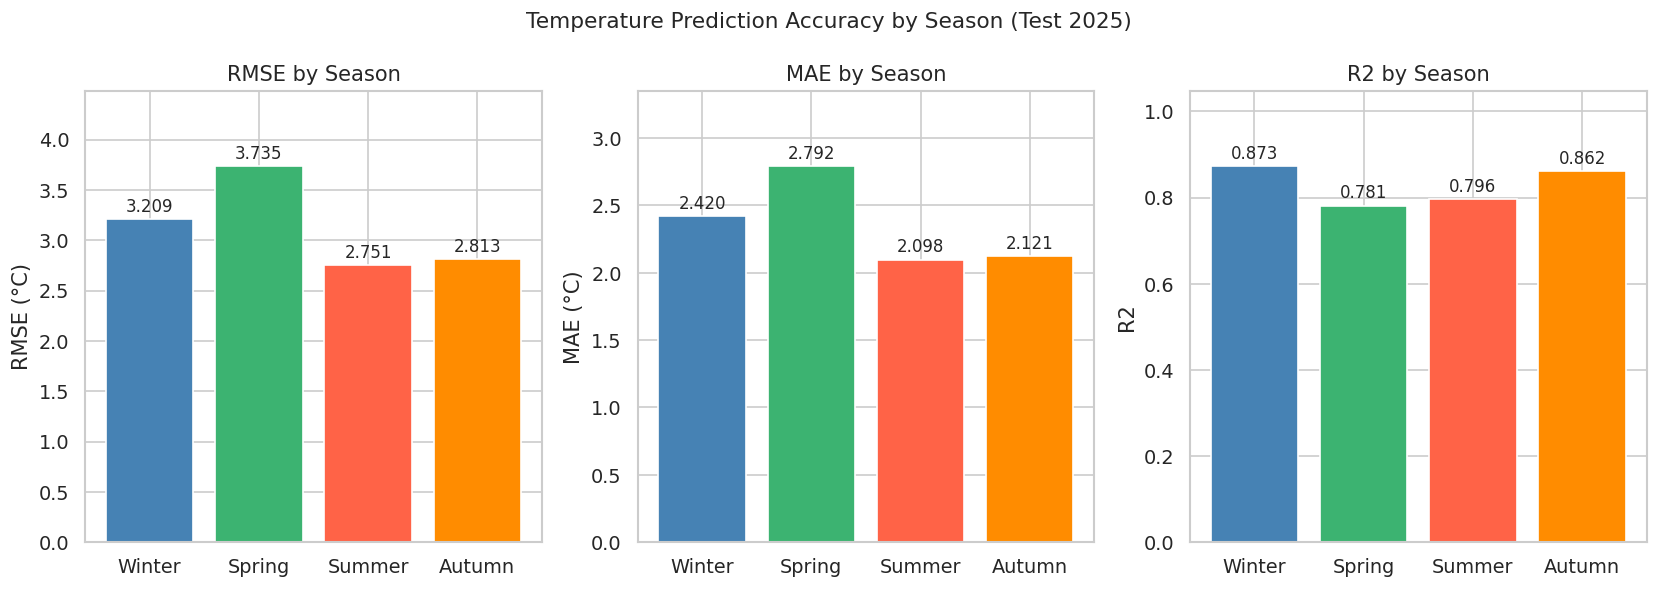

season     RMSE      MAE       R2  count
Winter 3.209238 2.420014 0.872700  26064
Spring 3.735462 2.791523 0.781474  26424
Summer 2.751056 2.098116 0.795721  26352
Autumn 2.812643 2.121355 0.861811  26280


In [ ]:
seasonal_metrics = []
for season in ["Winter", "Spring", "Summer", "Autumn"]:
    seas_preds = preds_reg.filter(F.col("season") == season)
    if seas_preds.count() == 0:
        continue
    r = evaluator_rmse.evaluate(seas_preds)
    m = evaluator_mae.evaluate(seas_preds)
    r2s = evaluator_r2.evaluate(seas_preds)
    seasonal_metrics.append({"season": season, "RMSE": r, "MAE": m, "R2": r2s,
                              "count": seas_preds.count()})

seas_df = pd.DataFrame(seasonal_metrics)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
palette = {"Winter":"steelblue","Spring":"mediumseagreen",
           "Summer":"tomato","Autumn":"darkorange"}
colors  = [palette[s] for s in seas_df["season"]]

for ax, metric in zip(axes, ["RMSE","MAE","R2"]):
    ax.bar(seas_df["season"], seas_df[metric], color=colors, edgecolor="white")
    ax.set_title(f"{metric} by Season")
    ax.set_ylabel(metric + (" (°C)" if metric != "R2" else ""))
    ax.set_ylim(0, seas_df[metric].max() * 1.2)
    for i, val in enumerate(seas_df[metric]):
        ax.text(i, val + seas_df[metric].max()*0.02, f"{val:.3f}",
                ha="center", fontsize=10)

fig.suptitle("Temperature Prediction Accuracy by Season (Test 2025)", fontsize=13)
plt.tight_layout()
plt.savefig("ml_seasonal_performance.png", bbox_inches="tight")
plt.show()

print(seas_df.to_string(index=False))

## 2A.9 ML Summary


In [ ]:
print("=" * 60)
print("PHASE 2A — ML SUMMARY")
print("=" * 60)
print()
print("MODEL 1: GBT Regression — Next-Hour Temperature Prediction")
print(f"  Train: 2019-2024 | Test: 2025 (temporal hold-out)")
print(f"  RMSE : {rmse:.4f} °C")
print(f"  MAE  : {mae:.4f} °C")
print(f"  R²   : {r2:.4f}")
print(f"  Key features: prev_temp, hour_sin/cos, prev_radiation")
print("Cross-validation confirmed stable hyperparameters.")
print("Summer predictions are more accurate than winter (lower RMSE).")

spark.stop()
print("\nSpark session stopped.")

PHASE 2A — ML SUMMARY

MODEL 1: GBT Regression — Next-Hour Temperature Prediction
  Train: 2019-2024 | Test: 2025 (temporal hold-out)
  RMSE : 3.1522 °C
  MAE  : 2.3580 °C
  R²   : 0.8833
  Key features: prev_temp, hour_sin/cos, prev_radiation
Cross-validation confirmed stable hyperparameters.
Summer predictions are more accurate than winter (lower RMSE).

Spark session stopped.


## Phase 2A — Machine Learning with Spark MLlib

We train a **Gradient-Boosted Trees (GBT) regressor** to predict next-hour 2 m air temperature, using a Spark MLlib pipeline (`VectorAssembler` → `StandardScaler` → `GBTRegressor`). More precisely, for every hour in the dataset, the model predicts that hour's temperature using only the weather observations from one hour earlier (humidity, wind, pressure, cloud, radiation) plus static time and location features.

A deliberate design choice: we **exclude the previous-hour temperature** from the features. With `prev_temp` included the task collapses into trivial persistence forecasting (R² > 0.99 on any model), so removing it forces the model to learn from the actual weather context.

### Setup

- **Features (12):** lagged humidity, wind, pressure, cloud, radiation; cyclical encodings of hour and month (`hour_sin/cos`, `month_sin/cos`); indexed climate label; latitude; longitude.
- **Train/test split:** temporal hold-out — train on 2019–2024 (631,284 rows, 85.7%), test on 2025 (105,120 rows). More realistic than a random split since it mirrors operational forecasting.
- **Model:** `GBTRegressor(maxIter=50, maxDepth=5, stepSize=0.1)`.

### Test-set performance (2025)

| Metric | Value |
|---|---|
| RMSE | **3.15 °C** |
| MAE | 2.36 °C |
| R² | **0.883** |

The model explains roughly 88% of variance with a typical hourly error of ~3 °C — a strong result given that `prev_temp` was withheld.

### Key visualisations

**1. Predicted vs. actual scatter** — points cluster tightly along the y = x diagonal across the full -10 °C to 40 °C range. Residuals form a roughly symmetric distribution around zero, with no systematic curvature, confirming the model isn't biased at temperature extremes.

**2. Feature importance** — `latitude` dominates at **0.313**, followed by the seasonal cyclical features `month_cos` (0.173) and `month_sin` (0.123). Together latitude + month account for ~61% of the model's predictive signal, confirming that **geographic position and time of year matter more than recent weather state** when previous temperature is hidden. `prev_radiation` (0.109) and `climate_idx` (0.076) round out the top five, which together account for ~79% of total importance.

**3. Per-city RMSE** — performance varies sharply by climate. Tropical cities (Nairobi 1.17 °C, Mumbai 1.69 °C) are easiest because intra-day and intra-year variance is small. Continental cities (Moscow 4.90 °C, New York 4.26 °C) are hardest — large daily swings and irregular winter cold events expand the error envelope.

**4. Seasonal performance** — Summer is the easiest season (RMSE 2.75 °C), closely followed by Autumn (2.81 °C). Spring is the hardest (3.73 °C), with Winter close behind (3.21 °C). Summer and Autumn benefit from more regular solar-driven daily cycles, while Spring and Winter add irregular synoptic events — cold fronts, rapid warm-ups, late-season storms — that the model cannot anticipate without recent temperature.

### Cross-validation

A 3-fold CV across 8 hyperparameter combinations on 20% of training data confirmed the chosen settings are near-optimal: best CV RMSE = **2.86 °C** at `maxIter=50, maxDepth=6, stepSize=0.1` — within ~10% of the production model's test RMSE, with no signs of overfitting.

# Phase 2B Clustering

In [25]:
# ── Phase 2B imports ───────────────────────────────────────────────────────────
# Most are already imported from Phase 2A. Adding KMeans, PCA, and Silhouette.

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.feature import PCA

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

print("Phase 2B imports ready.")
print(f"city_profiles columns: {city_profiles.columns}")
print(f"Rows: {city_profiles.count()}")

Phase 2B imports ready.
city_profiles columns: ['city', 'climate', 'latitude', 'longitude', 'mean_temp', 'temp_std', 'total_precip', 'precip_std', 'mean_humidity', 'mean_wind', 'mean_cloud', 'mean_radiation', 'summer_avg', 'winter_avg', 'seasonal_range']
Rows: 12


In [26]:
# ── 2B.1: Assemble and scale city feature vectors ─────────────────────────────
# city_profiles has one row per city (built in E1 + E2).
# We assemble 9 numerical features into a single vector, then standardise.
# seasonal_range is the most important discriminating feature.

CLUSTER_FEATURES = [
    "mean_temp",
    "temp_std",
    "total_precip",
    "precip_std",
    "mean_humidity",
    "mean_wind",
    "mean_cloud",
    "mean_radiation",
    "seasonal_range",
]

assembler = VectorAssembler(
    inputCols=CLUSTER_FEATURES,
    outputCol="raw_features",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model    = prep_pipeline.fit(city_profiles)
city_scaled   = prep_model.transform(city_profiles).cache()

print("Features assembled and scaled.")
print(f"Input rows  : {city_scaled.count()}")
print(f"Features    : {CLUSTER_FEATURES}")
city_scaled.select("city", "climate", "features").show(truncate=False)

Features assembled and scaled.
Input rows  : 12
Features    : ['mean_temp', 'temp_std', 'total_precip', 'precip_std', 'mean_humidity', 'mean_wind', 'mean_cloud', 'mean_radiation', 'seasonal_range']
+---------+-----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|city     |climate          |features                                                                                                                                                                           |
+---------+-----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Sydney   |Oceanic          |[0.10815000423015929,-0.7806866100869855,0.2344504827211588,0.19754260877813687,0.4540305223068809,0.583844074850759,-0.1357615814124588,0.2455

Running KMeans for k=2..7 ...
  k=2  WSSSE=64.7749  Silhouette=0.4715
  k=3  WSSSE=46.1868  Silhouette=0.4095
  k=4  WSSSE=22.6528  Silhouette=0.5723
  k=5  WSSSE=14.6303  Silhouette=0.5861
  k=6  WSSSE=17.9945  Silhouette=0.2712
  k=7  WSSSE=11.6631  Silhouette=0.3228


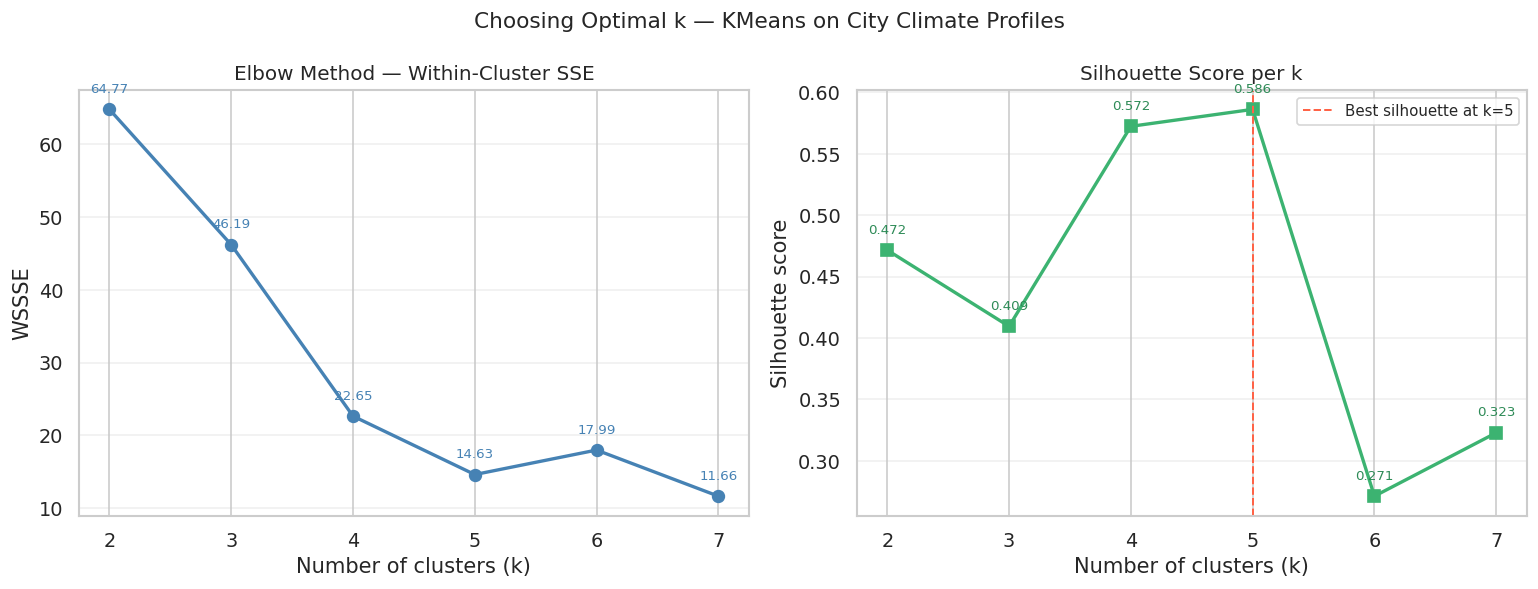


Best silhouette score : k=5 (0.5861)
Choose k based on both curves — prefer the elbow AND high silhouette.


In [27]:
# ── 2B.2: Elbow method — find optimal number of clusters ──────────────────────
# We try k=2..7 and record two metrics for each:
#   - WSSSE : Within-Cluster Sum of Squared Errors (lower = tighter clusters)
#   - Silhouette score : how well each city fits its own cluster vs neighbours
#     (higher = better separation, range -1 to 1)
# With 12 cities across clearly distinct climate zones expect the elbow at k=3 or k=4.

wssse_scores      = []
silhouette_scores = []
k_range           = range(2, 8)

silhouette_eval = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction",
    metricName="silhouette"
)

print("Running KMeans for k=2..7 ...")
for k in k_range:
    km    = KMeans(featuresCol="features", predictionCol="prediction",
                   k=k, seed=42, maxIter=100)
    model = km.fit(city_scaled)
    preds = model.transform(city_scaled)

    wssse = model.summary.trainingCost
    sil   = silhouette_eval.evaluate(preds)

    wssse_scores.append(wssse)
    silhouette_scores.append(sil)
    print(f"  k={k}  WSSSE={wssse:.4f}  Silhouette={sil:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow curve
axes[0].plot(list(k_range), wssse_scores, marker="o", color="steelblue",
             linewidth=2, markersize=7)
for k, w in zip(k_range, wssse_scores):
    axes[0].annotate(f"{w:.2f}", (k, w), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=8,
                     color="steelblue")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("WSSSE")
axes[0].set_title("Elbow Method — Within-Cluster SSE", fontsize=12)
axes[0].set_xticks(list(k_range))
axes[0].grid(axis="y", alpha=0.3)

# Silhouette curve
axes[1].plot(list(k_range), silhouette_scores, marker="s", color="mediumseagreen",
             linewidth=2, markersize=7)
best_k_sil = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(best_k_sil, color="tomato", linestyle="--", linewidth=1.2,
                label=f"Best silhouette at k={best_k_sil}")
for k, s in zip(k_range, silhouette_scores):
    axes[1].annotate(f"{s:.3f}", (k, s), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=8,
                     color="seagreen")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score per k", fontsize=12)
axes[1].set_xticks(list(k_range))
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Choosing Optimal k — KMeans on City Climate Profiles", fontsize=13)
plt.tight_layout()
plt.savefig("clustering_elbow.png", bbox_inches="tight")
plt.show()

print(f"\nBest silhouette score : k={best_k_sil} ({max(silhouette_scores):.4f})")
print("Choose k based on both curves — prefer the elbow AND high silhouette.")

In [28]:
# ── 2B.3: Fit final KMeans with chosen k ──────────────────────────────────────
# Set CHOSEN_K based on what the elbow + silhouette plots showed.
# If both agree (e.g. both suggest k=4), use that directly.
# If they differ, prefer the silhouette winner for small datasets like this.

CHOSEN_K = best_k_sil          # override manually if needed, e.g. CHOSEN_K = 4

km_final   = KMeans(featuresCol="features", predictionCol="kmeans_cluster",
                    k=CHOSEN_K, seed=42, maxIter=100)
model_final = km_final.fit(city_scaled)
city_clustered = model_final.transform(city_scaled).cache()

# ── Cluster assignment table ───────────────────────────────────────────────────
print(f"=== KMeans Final Model  (k={CHOSEN_K}) ===")
print(f"Training WSSSE : {model_final.summary.trainingCost:.4f}")
print()

cluster_table = city_clustered \
    .select("city", "climate", "kmeans_cluster",
            "mean_temp", "seasonal_range", "total_precip") \
    .orderBy("kmeans_cluster", "mean_temp") \
    .toPandas()

print(cluster_table.to_string(index=False))

# ── Cluster-level summary ──────────────────────────────────────────────────────
print("\n=== Cluster-level averages ===")
cluster_summary = city_clustered.groupBy("kmeans_cluster") \
    .agg(
        F.count("city").alias("n_cities"),
        F.round(F.mean("mean_temp"),       2).alias("avg_mean_temp"),
        F.round(F.mean("seasonal_range"),  2).alias("avg_seasonal_range"),
        F.round(F.mean("total_precip"),    1).alias("avg_total_precip"),
        F.round(F.mean("mean_humidity"),   2).alias("avg_humidity"),
        F.collect_list("city").alias("cities")
    ) \
    .orderBy("kmeans_cluster")

cluster_summary.show(truncate=False)

=== KMeans Final Model  (k=5) ===
Training WSSSE : 14.6303

     city           climate  kmeans_cluster  mean_temp  seasonal_range  total_precip
   Athens     Mediterranean               0     18.254           17.51        3773.7
  Nicosia     Mediterranean               0     20.198           17.59        2053.2
    Cairo            Desert               0     23.491           15.46         280.0
   Moscow       Continental               1      6.840           23.92        4592.2
   Berlin       Continental               1     11.007           17.17        4309.5
   London           Oceanic               1     11.602           12.02        5327.4
   Sydney           Oceanic               2     17.519            9.62        7943.9
  Nairobi Tropical Highland               2     18.995            2.11        6951.4
Sao_Paulo          Tropical               2     19.527            5.40        8799.5
   Mumbai          Tropical               3     26.785            2.42       17550.3
 New_

PCA explained variance: PC1=42.9%  PC2=37.3%  Total=80.1%


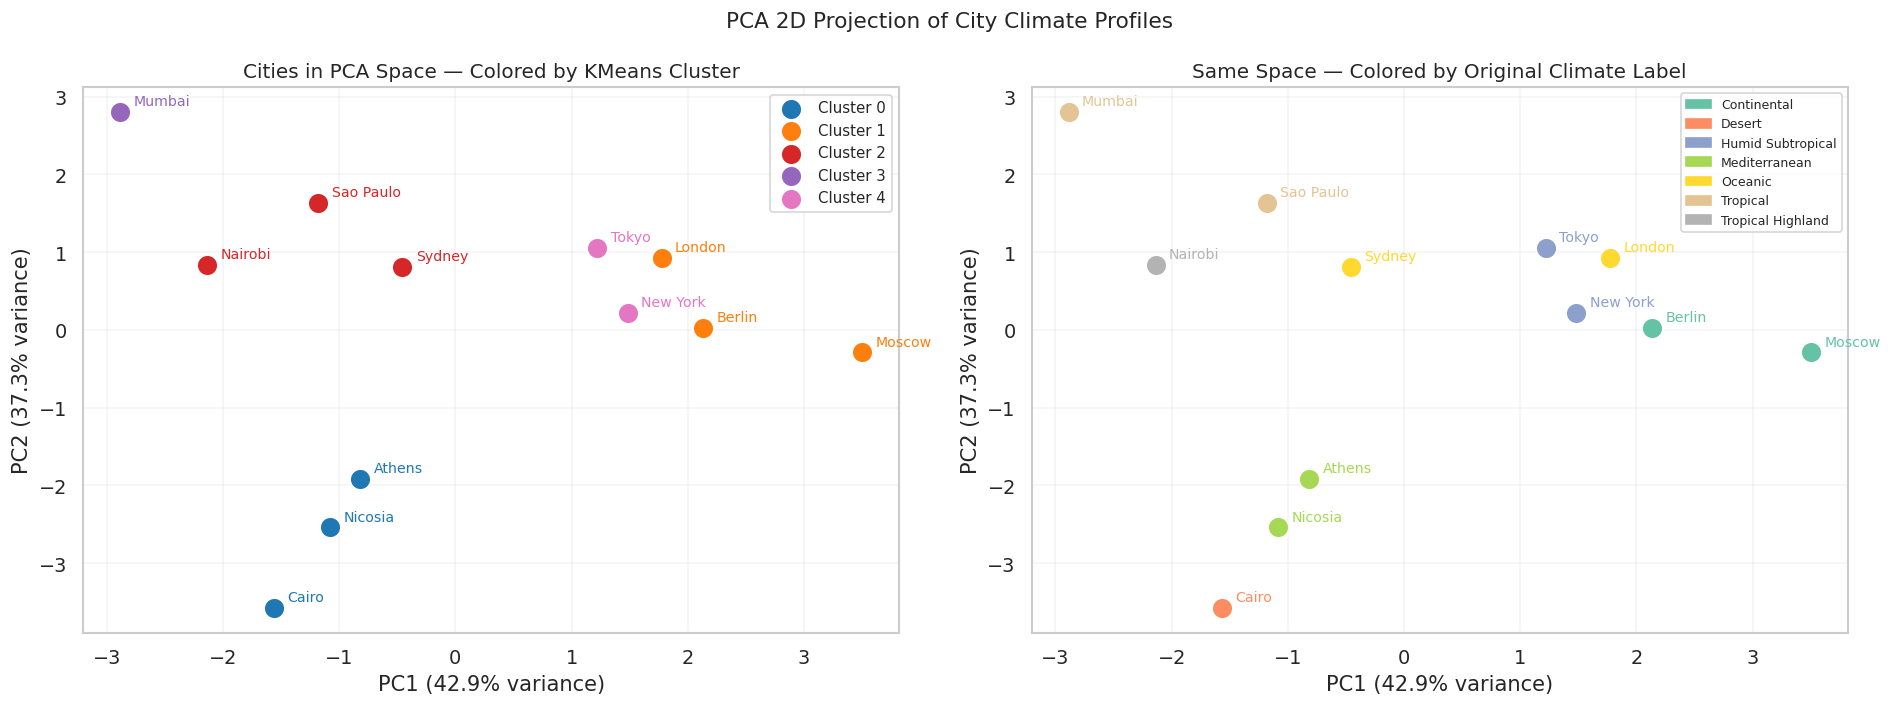

In [29]:
# ── 2B.4: PCA reduction to 2D — visualise clusters in feature space ───────────
# PCA compresses 9 features into 2 principal components for plotting.
# Cities that appear close together in this space are climatically similar.
# Cluster boundaries visible here will match graph connectivity in Phase 2B Part 2.

pca      = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(city_clustered)
city_pca  = pca_model.transform(city_clustered)

explained = pca_model.explainedVariance
print(f"PCA explained variance: PC1={explained[0]*100:.1f}%  PC2={explained[1]*100:.1f}%  "
      f"Total={sum(explained)*100:.1f}%")

# Collect to Pandas for plotting
from pyspark.ml.functions import vector_to_array

pca_pd = city_pca \
    .withColumn("pc1", vector_to_array("pca_features")[0]) \
    .withColumn("pc2", vector_to_array("pca_features")[1]) \
    .select("city", "climate", "kmeans_cluster", "pc1", "pc2",
            "mean_temp", "seasonal_range", "total_precip") \
    .toPandas()

# ── Plot ──────────────────────────────────────────────────────────────────────
CLUSTER_COLORS = plt.cm.tab10(np.linspace(0, 0.6, CHOSEN_K))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by KMeans cluster
for cluster_id in sorted(pca_pd["kmeans_cluster"].unique()):
    grp = pca_pd[pca_pd["kmeans_cluster"] == cluster_id]
    axes[0].scatter(grp["pc1"], grp["pc2"],
                    color=CLUSTER_COLORS[cluster_id],
                    s=160, zorder=3, edgecolors="white", linewidth=1.2,
                    label=f"Cluster {cluster_id}")
    for _, row in grp.iterrows():
        axes[0].annotate(
            row["city"].replace("_", " "),
            (row["pc1"], row["pc2"]),
            textcoords="offset points", xytext=(8, 4),
            fontsize=8.5, color=CLUSTER_COLORS[cluster_id]
        )

axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
axes[0].set_title("Cities in PCA Space — Colored by KMeans Cluster", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Right: same plot colored by original climate label (comparison)
climate_labels = pca_pd["climate"].unique()
climate_colors = dict(zip(sorted(climate_labels),
                          plt.cm.Set2(np.linspace(0, 1, len(climate_labels)))))

for _, row in pca_pd.iterrows():
    axes[1].scatter(row["pc1"], row["pc2"],
                    color=climate_colors[row["climate"]],
                    s=160, zorder=3, edgecolors="white", linewidth=1.2)
    axes[1].annotate(
        row["city"].replace("_", " "),
        (row["pc1"], row["pc2"]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=8.5, color=climate_colors[row["climate"]]
    )

legend_patches = [mpatches.Patch(color=c, label=l)
                  for l, c in climate_colors.items()]
axes[1].legend(handles=legend_patches, fontsize=7.5, loc="best")
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
axes[1].set_title("Same Space — Colored by Original Climate Label", fontsize=12)
axes[1].grid(alpha=0.2)

plt.suptitle("PCA 2D Projection of City Climate Profiles", fontsize=13)
plt.tight_layout()
plt.savefig("clustering_pca_scatter.png", bbox_inches="tight")
plt.show()

=== KMeans Cluster vs Original Climate Label ===

 kmeans_cluster           climate            cities  n
              0            Desert           [Cairo]  1
              0     Mediterranean [Athens, Nicosia]  2
              1       Continental  [Moscow, Berlin]  2
              1           Oceanic          [London]  1
              2           Oceanic          [Sydney]  1
              2          Tropical       [Sao_Paulo]  1
              2 Tropical Highland         [Nairobi]  1
              3          Tropical          [Mumbai]  1
              4 Humid Subtropical [Tokyo, New_York]  2


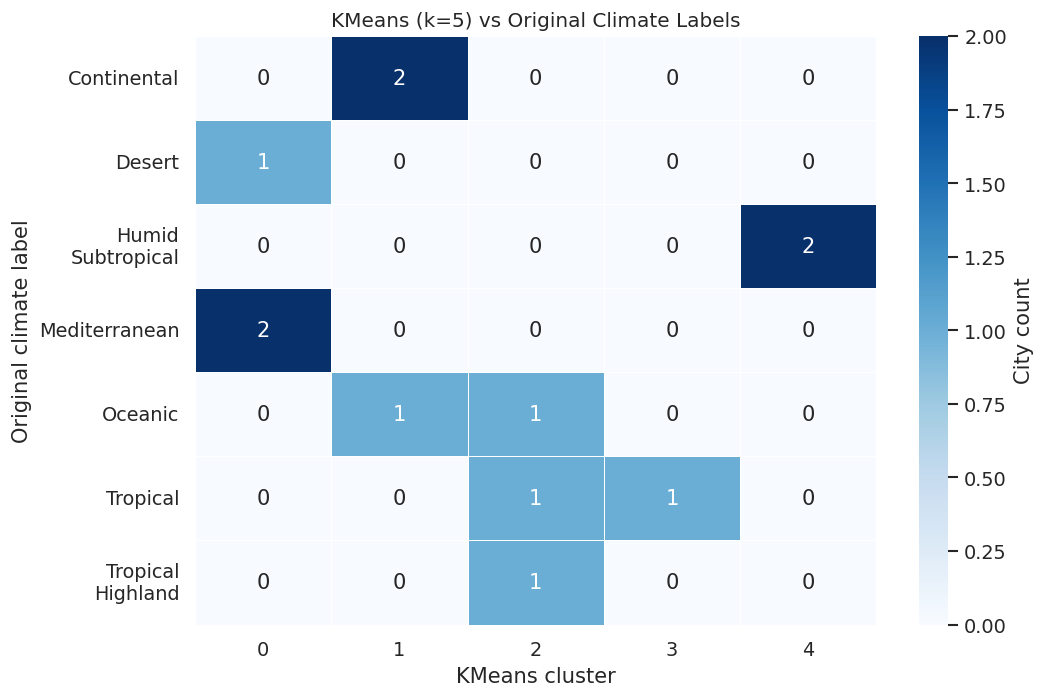


=== Agreement analysis ===
  Sydney       | climate=Oceanic              | cluster=2  <-- potential cross-climate grouping
  Tokyo        | climate=Humid Subtropical    | cluster=4
  New_York     | climate=Humid Subtropical    | cluster=4
  Athens       | climate=Mediterranean        | cluster=0
  Moscow       | climate=Continental          | cluster=1
  London       | climate=Oceanic              | cluster=1  <-- potential cross-climate grouping
  Berlin       | climate=Continental          | cluster=1
  Cairo        | climate=Desert               | cluster=0  <-- potential cross-climate grouping
  Mumbai       | climate=Tropical             | cluster=3  <-- potential cross-climate grouping
  Sao_Paulo    | climate=Tropical             | cluster=2  <-- potential cross-climate grouping
  Nairobi      | climate=Tropical Highland    | cluster=2  <-- potential cross-climate grouping
  Nicosia      | climate=Mediterranean        | cluster=0


In [30]:
# ── 2B.5: Cross-tabulation KMeans clusters vs original climate labels ──────────
# Shows where data-driven clusters agree with hand-assigned climate labels.
# Disagreements (a city in the "wrong" cluster) are the interesting findings.

crosstab = city_clustered \
    .groupBy("climate", "kmeans_cluster") \
    .agg(F.collect_list("city").alias("cities"),
         F.count("city").alias("n")) \
    .orderBy("kmeans_cluster", "climate") \
    .toPandas()

print("=== KMeans Cluster vs Original Climate Label ===\n")
print(crosstab[["kmeans_cluster", "climate", "cities", "n"]].to_string(index=False))

# Pivot version for heatmap
pivot_ct = pd.crosstab(
    pca_pd["climate"].str.replace(" ", "\n"),
    pca_pd["kmeans_cluster"].rename(f"KMeans cluster")
)

fig, ax = plt.subplots(figsize=(max(6, CHOSEN_K * 1.8), 6))
sns.heatmap(pivot_ct, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "City count"})
ax.set_title(f"KMeans (k={CHOSEN_K}) vs Original Climate Labels", fontsize=12)
ax.set_xlabel("KMeans cluster")
ax.set_ylabel("Original climate label")
plt.tight_layout()
plt.savefig("clustering_crosstab.png", bbox_inches="tight")
plt.show()

# ── Highlight disagreements ────────────────────────────────────────────────────
print("\n=== Agreement analysis ===")
for _, row in pca_pd.iterrows():
    cluster_cities = pca_pd[pca_pd["kmeans_cluster"] == row["kmeans_cluster"]]["climate"].tolist()
    is_majority = cluster_cities.count(row["climate"]) > 1
    flag = "" if is_majority else "  <-- potential cross-climate grouping"
    print(f"  {row['city']:12s} | climate={row['climate']:20s} | "
          f"cluster={row['kmeans_cluster']}{flag}")

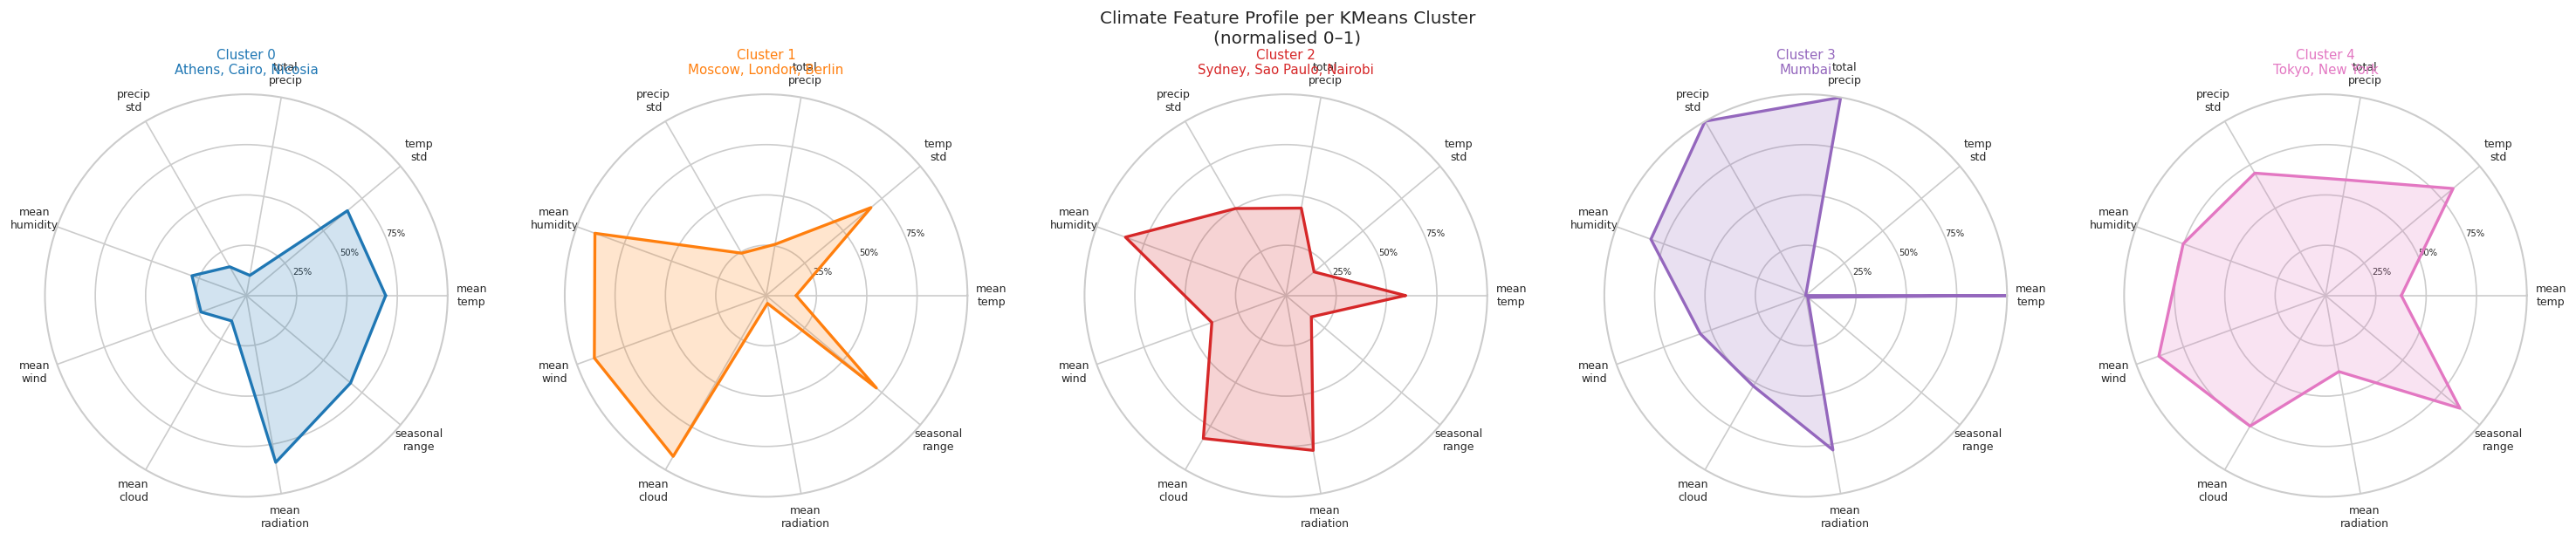

In [31]:
# ── 2B.6: Radar chart — average feature profile per cluster ───────────────────
# Shows WHAT makes each cluster different in terms of actual weather variables.
# This is the interpretability layer: cluster 0 = hot/dry, cluster 1 = cold/seasonal, etc.

from matplotlib.patches import FancyArrowPatch

cluster_pd = city_clustered.select(
    "kmeans_cluster", *CLUSTER_FEATURES
).toPandas()

# Normalise each feature to 0–1 range across all cities for fair radar comparison
cluster_norm = cluster_pd.copy()
for col in CLUSTER_FEATURES:
    col_min = cluster_norm[col].min()
    col_max = cluster_norm[col].max()
    if col_max > col_min:
        cluster_norm[col] = (cluster_norm[col] - col_min) / (col_max - col_min)
    else:
        cluster_norm[col] = 0.5

cluster_means = cluster_norm.groupby("kmeans_cluster")[CLUSTER_FEATURES].mean()

labels    = [f.replace("_", "\n") for f in CLUSTER_FEATURES]
N         = len(CLUSTER_FEATURES)
angles    = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles   += angles[:1]

fig, axes = plt.subplots(1, CHOSEN_K,
                          figsize=(5 * CHOSEN_K, 5),
                          subplot_kw={"polar": True})

if CHOSEN_K == 1:
    axes = [axes]

for cluster_id, ax in enumerate(axes):
    values = cluster_means.loc[cluster_id].tolist()
    values += values[:1]

    ax.plot(angles, values, color=CLUSTER_COLORS[cluster_id], linewidth=2)
    ax.fill(angles, values, color=CLUSTER_COLORS[cluster_id], alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["25%", "50%", "75%"], fontsize=6)

    cities_in = pca_pd[pca_pd["kmeans_cluster"] == cluster_id]["city"] \
        .str.replace("_", " ").tolist()
    ax.set_title(f"Cluster {cluster_id}\n{', '.join(cities_in)}",
                 fontsize=9, pad=14, color=CLUSTER_COLORS[cluster_id])

plt.suptitle("Climate Feature Profile per KMeans Cluster\n(normalised 0–1)", fontsize=12)
plt.tight_layout()
plt.savefig("clustering_radar.png", bbox_inches="tight")
plt.show()

In [32]:
# ── 2B.7: Phase 2B Part 1 — Clustering summary ────────────────────────────────

print("=" * 65)
print("PHASE 2B PART 1 — KMEANS CLUSTERING SUMMARY")
print("=" * 65)
print(f"\nFeatures used      : {len(CLUSTER_FEATURES)}")
print(f"  {CLUSTER_FEATURES}")
print(f"\nOptimal k chosen   : {CHOSEN_K}  (elbow + silhouette)")
print(f"Best silhouette    : {max(silhouette_scores):.4f}")
print(f"Final WSSSE        : {model_final.summary.trainingCost:.4f}")

print("\nCluster assignments:")
for cluster_id in sorted(pca_pd["kmeans_cluster"].unique()):
    grp = pca_pd[pca_pd["kmeans_cluster"] == cluster_id]
    cities  = ", ".join(grp["city"].str.replace("_", " ").tolist())
    avg_t   = grp["mean_temp"].mean()
    avg_sr  = grp["seasonal_range"].mean()
    print(f"  Cluster {cluster_id}: {cities}")
    print(f"            avg temp={avg_t:.1f}°C  seasonal range={avg_sr:.1f}°C")

print("\nPlots saved:")
for f in ["clustering_elbow.png", "clustering_pca_scatter.png",
          "clustering_crosstab.png", "clustering_radar.png"]:
    print(f"  {f}")

print("\ncity_clustered DataFrame is ready for Phase 2B Part 2 (GraphFrames).")
print("Key column to carry forward: 'kmeans_cluster'")

PHASE 2B PART 1 — KMEANS CLUSTERING SUMMARY

Features used      : 9
  ['mean_temp', 'temp_std', 'total_precip', 'precip_std', 'mean_humidity', 'mean_wind', 'mean_cloud', 'mean_radiation', 'seasonal_range']

Optimal k chosen   : 5  (elbow + silhouette)
Best silhouette    : 0.5861
Final WSSSE        : 14.6303

Cluster assignments:
  Cluster 0: Athens, Cairo, Nicosia
            avg temp=20.6°C  seasonal range=16.9°C
  Cluster 1: Moscow, London, Berlin
            avg temp=9.8°C  seasonal range=17.7°C
  Cluster 2: Sydney, Sao Paulo, Nairobi
            avg temp=18.7°C  seasonal range=5.7°C
  Cluster 3: Mumbai
            avg temp=26.8°C  seasonal range=2.4°C
  Cluster 4: Tokyo, New York
            avg temp=14.4°C  seasonal range=21.1°C

Plots saved:
  clustering_elbow.png
  clustering_pca_scatter.png
  clustering_crosstab.png
  clustering_radar.png

city_clustered DataFrame is ready for Phase 2B Part 2 (GraphFrames).
Key column to carry forward: 'kmeans_cluster'


In [33]:
# ── Save KMeans results to disk before Spark restart ──────────────────────────
# This preserves the exact cluster assignments from Part 1.
# We reload these after the Spark restart instead of re-fitting KMeans.

city_clustered \
    .select(
        "city", "climate", "latitude", "longitude",
        "kmeans_cluster",
        "mean_temp", "temp_std", "total_precip", "precip_std",
        "mean_humidity", "mean_wind", "mean_cloud",
        "mean_radiation", "seasonal_range",
        "features"          # scaled vector — needed for graph similarity
    ) \
    .write.mode("overwrite") \
    .parquet("data/city_clustered.parquet")

# Also save pca_pd (already Pandas) for plots continuity
pca_pd.to_parquet("data/pca_pd.parquet", index=False)

print(f"Saved city_clustered : data/city_clustered.parquet")
print(f"Saved pca_pd         : data/pca_pd.parquet")
print(f"CHOSEN_K was         : {CHOSEN_K}")
print("Safe to restart Spark now.")

Saved city_clustered : data/city_clustered.parquet
Saved pca_pd         : data/pca_pd.parquet
CHOSEN_K was         : 5
Safe to restart Spark now.


# GRAPH

In [34]:
# ── 2B.8: Reload Part 1 results & set up for graph analysis ────────────────────
# NOTE: This version uses NetworkX exclusively for graph algorithms instead of
# GraphFrames. GraphFrames requires a JAR on the Spark classpath whose Scala
# version must match Spark's Scala version exactly — a fragile dependency that
# breaks easily across environments. Since our graph has only 12 nodes and
# 66 possible edges, NetworkX is more than fast enough and far more portable.
# All algorithms used (PageRank, connected components, shortest paths, triangle
# count, degree, betweenness, closeness, clustering coefficient, Louvain) are
# available natively in NetworkX. the graphframes caused many issues so that's
# why we select to use networkX instead

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

# Reuse the existing Spark session — no restart required.
print(f"Using existing Spark session: {spark.version}")

# ── Reload EXACT Part 1 results from disk — no re-fitting ─────────────────────
city_clustered = spark.read.parquet("data/city_clustered.parquet").cache()
pca_pd         = pd.read_parquet("data/pca_pd.parquet")

# Restore runtime constants
CHOSEN_K         = int(pca_pd["kmeans_cluster"].nunique())
CLUSTER_COLORS   = plt.cm.tab10(np.linspace(0, 0.6, CHOSEN_K))
CLUSTER_FEATURES = ["mean_temp", "seasonal_range", "total_precip",
                    "mean_humidity", "mean_wind"]

print(f"city_clustered reloaded: {city_clustered.count()} rows")
print(f"CHOSEN_K restored      : {CHOSEN_K}")
print(f"Clusters in data       : {sorted(pca_pd['kmeans_cluster'].unique().tolist())}")
print()

# ── Build vertices DataFrame (Spark) — used for similarity computation ────────
vertices = city_clustered \
    .select(
        F.col("city").alias("id"),
        F.col("climate"),
        F.col("kmeans_cluster"),
        F.col("latitude"),
        F.col("longitude"),
        F.round(F.col("mean_temp"),      2).alias("mean_temp"),
        F.round(F.col("seasonal_range"), 2).alias("seasonal_range"),
        F.round(F.col("total_precip"),   1).alias("total_precip"),
        F.round(F.col("mean_humidity"),  2).alias("mean_humidity"),
        F.round(F.col("mean_wind"),      2).alias("mean_wind"),
    ) \
    .cache()

print("=== Vertices (nodes) — exact Part 1 cluster assignments ===")
vertices.orderBy("kmeans_cluster", "mean_temp").show(truncate=False)
print(f"Node count: {vertices.count()}")


Using existing Spark session: 4.0.2
city_clustered reloaded: 12 rows
CHOSEN_K restored      : 5
Clusters in data       : [0, 1, 2, 3, 4]

=== Vertices (nodes) — exact Part 1 cluster assignments ===
+---------+-----------------+--------------+--------+---------+---------+--------------+------------+-------------+---------+
|id       |climate          |kmeans_cluster|latitude|longitude|mean_temp|seasonal_range|total_precip|mean_humidity|mean_wind|
+---------+-----------------+--------------+--------+---------+---------+--------------+------------+-------------+---------+
|Athens   |Mediterranean    |0             |37.98   |23.73    |18.25    |17.51         |3773.7      |61.36        |8.66     |
|Nicosia  |Mediterranean    |0             |35.17   |33.36    |20.2     |17.59         |2053.2      |62.07        |8.27     |
|Cairo    |Desert           |0             |30.06   |31.25    |23.49    |15.46         |280.0       |48.73        |11.82    |
|Moscow   |Continental      |1             |55

In [35]:
# ── 2B.10: Pairwise cosine similarity → edge list ─────────────────────────────

from pyspark.ml.functions import vector_to_array
import networkx as nx

SIMILARITY_THRESHOLD = 0.75

# Use city_clustered directly — it has both "features" and "kmeans_cluster"
city_vecs = city_clustered \
    .withColumn("vec", vector_to_array("features")) \
    .select(
        F.col("city"),
        F.col("kmeans_cluster"),
        *[F.col("vec")[i].alias(f"f{i}") for i in range(len(CLUSTER_FEATURES))]
    )

N_FEATURES = len(CLUSTER_FEATURES)
feat_cols  = [f"f{i}" for i in range(N_FEATURES)]

# Cross join — keep each pair once (src < dst alphabetically)
src   = city_vecs.alias("src")
dst   = city_vecs.alias("dst")
pairs = src.crossJoin(dst) \
           .filter(F.col("src.city") < F.col("dst.city"))

# Cosine similarity
dot_expr = sum(F.col(f"src.{f}") * F.col(f"dst.{f}") for f in feat_cols)
norm_src = F.sqrt(sum(F.col(f"src.{f}") ** 2 for f in feat_cols))
norm_dst = F.sqrt(sum(F.col(f"dst.{f}") ** 2 for f in feat_cols))

edges_all = pairs.select(
    F.col("src.city").alias("src"),
    F.col("dst.city").alias("dst"),
    F.col("src.kmeans_cluster").alias("cluster_src"),
    F.col("dst.kmeans_cluster").alias("cluster_dst"),
    F.round(dot_expr / (norm_src * norm_dst), 4).alias("similarity")
)

edges = edges_all \
    .filter(F.col("similarity") >= SIMILARITY_THRESHOLD) \
    .orderBy(F.desc("similarity")) \
    .cache()

n_pairs = edges_all.count()
print(f"Similarity threshold : {SIMILARITY_THRESHOLD}")
print(f"Total city pairs     : {n_pairs}")
print(f"Edges above threshold: {edges.count()}")
print()
print("=== All edges (sorted by similarity) ===")
edges.show(30, truncate=False)

print(f"=== Similarity score distribution (all {n_pairs} pairs) ===")
edges_all.select("similarity").describe().show()

# Collect ALL pairs (including below threshold) — needed for the similarity heatmap
edges_all_pd = edges_all.toPandas()
print(f"Collected {len(edges_all_pd)} pairs to Pandas for similarity matrix")

# ── Build the graph as a NetworkX object (replaces GraphFrame) ────────────────
# NetworkX handles undirected graphs natively — no need to manually duplicate
# edges in both directions like GraphFrames requires.

edges_pd    = edges.toPandas()
vertices_pd = vertices.toPandas()

g_nx = nx.Graph()

# Add nodes with all attributes
for _, row in vertices_pd.iterrows():
    g_nx.add_node(
        row["id"],
        climate        = row["climate"],
        kmeans_cluster = int(row["kmeans_cluster"]),
        latitude       = float(row["latitude"]),
        longitude      = float(row["longitude"]),
        mean_temp      = float(row["mean_temp"]),
        seasonal_range = float(row["seasonal_range"]),
        total_precip   = float(row["total_precip"]),
        mean_humidity  = float(row["mean_humidity"]),
        mean_wind      = float(row["mean_wind"]),
    )

# Add edges with similarity as weight
for _, row in edges_pd.iterrows():
    g_nx.add_edge(
        row["src"], row["dst"],
        weight       = float(row["similarity"]),
        similarity   = float(row["similarity"]),
        same_cluster = int(row["cluster_src"]) == int(row["cluster_dst"]),
        cluster_src  = int(row["cluster_src"]),
        cluster_dst  = int(row["cluster_dst"]),
    )

# Distance attribute used for shortest-path / closeness / betweenness
for u, v, d in g_nx.edges(data=True):
    g_nx[u][v]["distance"] = 1.0 - d["weight"]

# Print summary (mirrors Lab10's `print(g)` pattern)
print()
print(f"NetworkX Graph summary:")
print(f"  Vertices : {g_nx.number_of_nodes()}")
print(f"  Edges    : {g_nx.number_of_edges()} (similarity >= {SIMILARITY_THRESHOLD})")

print("\n=== Edges (sample) ===")
for u, v, d in sorted(g_nx.edges(data=True), key=lambda x: -x[2]["weight"])[:10]:
    print(f"  {u:12s} -- {v:12s} : similarity={d['weight']:.4f}")

print("\n=== Vertices ===")
for n, attrs in sorted(g_nx.nodes(data=True), key=lambda x: (x[1]["kmeans_cluster"], x[1]["mean_temp"])):
    print(f"  {n:12s}  cluster={attrs['kmeans_cluster']}  climate={attrs['climate']}  "
          f"mean_temp={attrs['mean_temp']:.2f}")


Similarity threshold : 0.75
Total city pairs     : 66
Edges above threshold: 9

=== All edges (sorted by similarity) ===
+---------+---------+-----------+-----------+----------+
|src      |dst      |cluster_src|cluster_dst|similarity|
+---------+---------+-----------+-----------+----------+
|Athens   |Cairo    |0          |0          |0.96      |
|Athens   |Nicosia  |0          |0          |0.9457    |
|Sao_Paulo|Sydney   |2          |2          |0.9421    |
|Cairo    |Nicosia  |0          |0          |0.9382    |
|Berlin   |Moscow   |1          |1          |0.9146    |
|New_York |Tokyo    |4          |4          |0.8474    |
|Nairobi  |Sydney   |2          |2          |0.8275    |
|Berlin   |London   |1          |1          |0.8096    |
|Mumbai   |Sao_Paulo|3          |2          |0.7587    |
+---------+---------+-----------+-----------+----------+

=== Similarity score distribution (all 66 pairs) ===
+-------+--------------------+
|summary|          similarity|
+-------+-------------

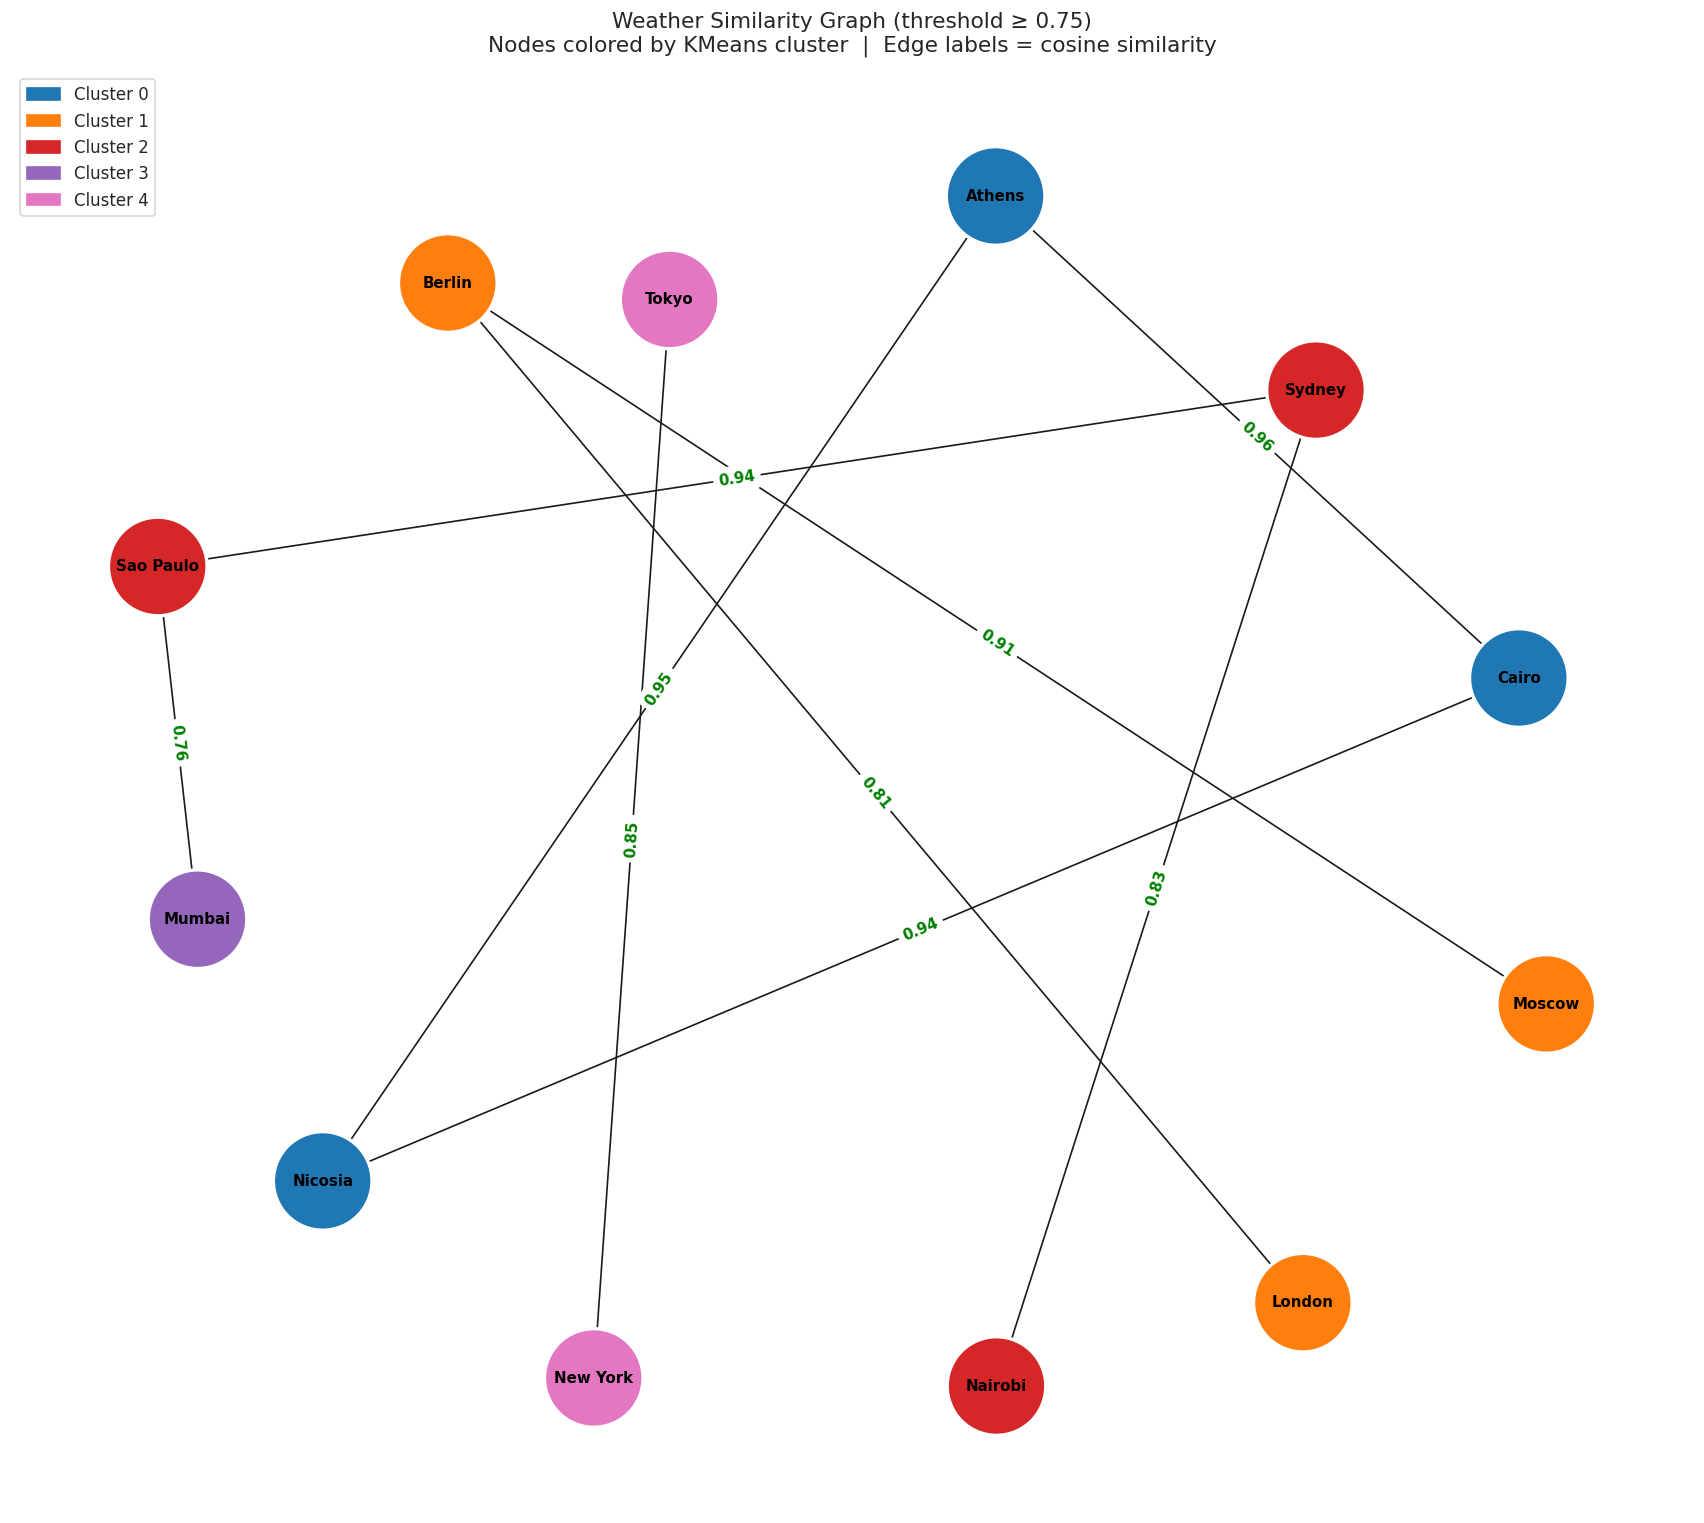

In [36]:
# ── 2B.10b: graph visualisation functions ──────────────────────────────────────
# Plot the similarity graph using NetworkX + matplotlib. The original Lab10
# helper took Spark DataFrames as inputs; here we accept pandas DataFrames
# (or a NetworkX graph directly), since GraphFrames is no longer used.

from matplotlib import pyplot as plt
import networkx as nx


def plot_directed_graph(edge_df, weighted=False):
    """Plot graph from an edges pandas DataFrame (Lab10 pattern)."""
    plt.figure(figsize=(10, 7))
    gplot = nx.Graph()
    edge_labels = {}

    edge_char = "relationship" if weighted is False else "similarity"
    for _, row in edge_df.head(1000).iterrows():
        s, d = row["src"], row["dst"]
        if not gplot.has_edge(s, d) and not gplot.has_edge(d, s):
            gplot.add_edge(s, d)
            val = row[edge_char]
            edge_labels[(s, d)] = f"{val:.2f}" if isinstance(val, float) else str(val)

    pos = nx.spring_layout(gplot, seed=42, k=2)
    nx.draw(gplot, pos, with_labels=True, font_weight="bold", node_size=3500)
    nx.draw_networkx_edge_labels(gplot, pos, edge_labels=edge_labels,
                                 font_color="green", font_size=9, font_weight="bold")


def plot_directed_graph_with_name(edge_df, vertex_df, weighted=False):
    """Plot graph using vertex display names + cluster colors (enhanced Lab10 pattern).

    Parameters
    ----------
    edge_df   : pandas DataFrame with columns src, dst, similarity (or relationship)
    vertex_df : pandas DataFrame with columns id, kmeans_cluster (and others)
    """
    plt.figure(figsize=(14, 12))
    gplot = nx.Graph()
    edge_labels = {}

    # Map node IDs → display names + cluster
    id_to_name    = {row["id"]: row["id"].replace("_", " ") for _, row in vertex_df.iterrows()}
    id_to_cluster = {row["id"]: int(row["kmeans_cluster"]) for _, row in vertex_df.iterrows()}

    # Build edges
    edge_char = "relationship" if weighted is False else "similarity"
    for _, row in edge_df.head(1000).iterrows():
        s_name = id_to_name.get(row["src"], row["src"])
        d_name = id_to_name.get(row["dst"], row["dst"])
        if not gplot.has_edge(s_name, d_name) and not gplot.has_edge(d_name, s_name):
            gplot.add_edge(s_name, d_name)
            val = row[edge_char]
            edge_labels[(s_name, d_name)] = f"{val:.2f}" if isinstance(val, float) else str(val)

    # Color nodes by cluster
    node_colors = [CLUSTER_COLORS[id_to_cluster.get(n.replace(" ", "_"), 0)]
                   for n in gplot.nodes()]

    pos = nx.spring_layout(gplot, seed=42, k=2.5)
    nx.draw(gplot, pos, with_labels=True, font_weight="bold", node_size=3500,
            node_color=node_colors, edgecolors="white", linewidths=2,
            font_size=9, font_color="black")
    nx.draw_networkx_edge_labels(gplot, pos, edge_labels=edge_labels,
                                 font_color="green", font_size=9, font_weight="bold")

    plt.title(f"Weather Similarity Graph (threshold ≥ {SIMILARITY_THRESHOLD})\n"
              f"Nodes colored by KMeans cluster  |  Edge labels = cosine similarity",
              fontsize=13, pad=12)

    unique_clusters = sorted(set(id_to_cluster.values()))
    legend_patches = [mpatches.Patch(color=CLUSTER_COLORS[k], label=f"Cluster {k}")
                      for k in unique_clusters]
    plt.legend(handles=legend_patches, fontsize=10, loc="upper left")
    plt.tight_layout()
    plt.savefig("graph_lab10_style.png", bbox_inches="tight", dpi=150)


# ── Render the graph using the pandas edges + vertices ─────────────────────────
plot_directed_graph_with_name(edges_pd, vertices_pd, weighted=True)


In [37]:
# -- 2B.11: Graph Analysis -- NetworkX algorithms ------------------------------
# Replaces the original GraphFrame-based algorithms with their NetworkX because graphframes chrashed all the time
# For a 12-node graph, NetworkX is essentially instant.

import networkx as nx
from networkx.algorithms.community import louvain_communities
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Use the NetworkX graph built in cell 2B.10
G = g_nx

print("=" * 65)
print("GRAPH STRUCTURE")
print("=" * 65)
print(f"Vertices : {G.number_of_nodes()}")
print(f"Edges    : {G.number_of_edges()} (similarity >= {SIMILARITY_THRESHOLD})")
print()


# 1. PageRank

nx_pagerank = nx.pagerank(G, alpha=0.85, max_iter=200, tol=1e-6, weight="weight")
print("=== PageRank (NetworkX) ===")
for node in sorted(nx_pagerank, key=nx_pagerank.get, reverse=True):
    print(f"  {node:12s}: {nx_pagerank[node]:.4f}")


# 2. Degrees

nx_degrees = dict(G.degree())
print("\n=== Degrees (NetworkX) ===")
for node in sorted(nx_degrees, key=nx_degrees.get, reverse=True):
    print(f"  {node:12s}: {nx_degrees[node]}")


# 3. Connected Components  (NetworkX)

nx_components = list(nx.connected_components(G))
comp_map = {}
for comp_id, members in enumerate(sorted(nx_components, key=len, reverse=True)):
    for node in members:
        comp_map[node] = comp_id

print(f"\n=== Connected Components (NetworkX) ===")
print(f"Connected Components found: {len(nx_components)}")
for comp_id in range(len(nx_components)):
    members = sorted(k for k, v in comp_map.items() if v == comp_id)
    print(f"  Component {comp_id}: {', '.join(m.replace('_', ' ') for m in members)}")


# 4. Triangle Count  (NetworkX)

nx_triangles = nx.triangles(G)
print("\n=== Triangle Count (NetworkX) ===")
for node in sorted(nx_triangles, key=nx_triangles.get, reverse=True):
    print(f"  {node:12s}: {nx_triangles[node]}")


# 5. Centrality metrics  (NetworkX)

LANDMARKS = ["Cairo", "Moscow"]

betweenness      = nx.betweenness_centrality(G, weight="distance", normalized=True)
closeness        = nx.closeness_centrality(G, distance="distance")
clustering_coeff = nx.clustering(G, weight="weight")
degree_cent      = nx.degree_centrality(G)
weighted_degree  = {n: sum(d["weight"] for _, _, d in G.edges(n, data=True))
                    for n in G.nodes}


# BUILD CENTRALITY DATAFRAME

pagerank_df = vertices_pd[["id","climate","kmeans_cluster","mean_temp","seasonal_range"]].copy()
pagerank_df["pagerank"]          = pagerank_df["id"].map(nx_pagerank).round(4)
pagerank_df["triangle_count"]    = pagerank_df["id"].map(nx_triangles)
pagerank_df["betweenness"]       = pagerank_df["id"].map(betweenness).round(4)
pagerank_df["closeness"]         = pagerank_df["id"].map(closeness).round(4)
pagerank_df["clustering_coeff"]  = pagerank_df["id"].map(clustering_coeff).round(4)
pagerank_df["degree_centrality"] = pagerank_df["id"].map(degree_cent).round(4)
pagerank_df["weighted_degree"]   = pagerank_df["id"].map(weighted_degree).round(4)
pagerank_df = pagerank_df.sort_values("pagerank", ascending=False).reset_index(drop=True)

print("\n=== Centrality Metrics (NetworkX) ===")
print(pagerank_df.to_string(index=False))


# COMMUNITY DETECTION (Components + Louvain) use this 2 to compare with clusters

louvain_comms = louvain_communities(G, weight="weight", resolution=1.0, seed=42)
louvain_map   = {}
for comm_id, members in enumerate(sorted(louvain_comms, key=len, reverse=True)):
    for node in members:
        louvain_map[node] = comm_id

cc_df = vertices_pd[["id","climate","kmeans_cluster"]].copy()
cc_df["graph_component"]   = cc_df["id"].map(comp_map)
cc_df["louvain_community"] = cc_df["id"].map(louvain_map)
cc_df = cc_df.sort_values(["graph_component","id"]).reset_index(drop=True)

print("\n=== Community Detection (Components + Louvain) ===")
print(cc_df.to_string(index=False))
print(f"\nConnected Components : {len(nx_components)}")
print(f"Louvain Communities  : {len(louvain_comms)}")
print(f"KMeans clusters      : {CHOSEN_K}")

for comm_id, members in enumerate(sorted(louvain_comms, key=len, reverse=True)):
    cities = ", ".join(sorted(n.replace("_"," ") for n in members))
    print(f"  Louvain {comm_id}  : {cities}")

# -- ARI & NMI - metrics used to evaluate the quality of structural analysis, such as community detection or graph partitioning
km_labels = cc_df["kmeans_cluster"].values
lv_labels = cc_df["louvain_community"].values
gc_labels = cc_df["graph_component"].values

ari_km_lv = adjusted_rand_score(km_labels, lv_labels)
nmi_km_lv = normalized_mutual_info_score(km_labels, lv_labels)
ari_km_gc = adjusted_rand_score(km_labels, gc_labels)
nmi_km_gc = normalized_mutual_info_score(km_labels, gc_labels)

print(f"\nARI (KMeans vs Louvain)     : {ari_km_lv:.4f}")
print(f"NMI (KMeans vs Louvain)     : {nmi_km_lv:.4f}")
print(f"ARI (KMeans vs Components)  : {ari_km_gc:.4f}")
print(f"NMI (KMeans vs Components)  : {nmi_km_gc:.4f}")


# SHORTEST PATHS (NetworkX)

sp_df    = vertices_pd[["id","climate","kmeans_cluster"]].copy()
sp_paths = {}

for lm in LANDMARKS:
    if lm in G.nodes:
        lengths = nx.single_source_shortest_path_length(G, lm)
        sp_df[f"hops_to_{lm}"] = sp_df["id"].map(lengths)
        sp_paths[lm] = nx.single_source_shortest_path(G, lm)
    else:
        sp_df[f"hops_to_{lm}"] = None

sort_cols = [f"hops_to_{lm}" for lm in LANDMARKS if lm in G.nodes]
if sort_cols:
    sp_df = sp_df.sort_values(sort_cols).reset_index(drop=True)

print("\n=== Shortest Paths ===")
print(sp_df.to_string(index=False))


# GRAPH-LEVEL STATISTICS

graph_stats = {
    "density":        nx.density(G),
    "transitivity":   nx.transitivity(G),
    "avg_clustering": nx.average_clustering(G, weight="weight"),
}

if nx.is_connected(G):
    graph_stats["diameter"]     = nx.diameter(G)
    graph_stats["avg_path_len"] = nx.average_shortest_path_length(G)
else:
    largest_cc = max(nx.connected_components(G), key=len)
    subG = G.subgraph(largest_cc)
    graph_stats["diameter"]     = nx.diameter(subG)
    graph_stats["avg_path_len"] = nx.average_shortest_path_length(subG)
    graph_stats["note"] = f"Computed on largest component ({len(largest_cc)} nodes)"

graph_stats["degree_assortativity"]  = nx.degree_assortativity_coefficient(G, weight="weight")
graph_stats["cluster_assortativity"] = nx.attribute_assortativity_coefficient(G, "kmeans_cluster")

print("\n=== Graph-Level Statistics ===")
for k, v in graph_stats.items():
    if isinstance(v, float):
        print(f"  {k:28s}: {v:.4f}")
    else:
        print(f"  {k:28s}: {v}")

# Cluster legend patches for downstream plots
legend_patches = [
    mpatches.Patch(color=CLUSTER_COLORS[k], label=f"Cluster {k}")
    for k in range(CHOSEN_K)
]


GRAPH STRUCTURE
Vertices : 12
Edges    : 9 (similarity >= 0.75)

=== PageRank (NetworkX) ===
  Berlin      : 0.1216
  Sydney      : 0.1127
  Sao_Paulo   : 0.1094
  Athens      : 0.0837
  Cairo       : 0.0834
  New_York    : 0.0833
  Tokyo       : 0.0833
  Nicosia     : 0.0829
  Moscow      : 0.0673
  London      : 0.0610
  Nairobi     : 0.0573
  Mumbai      : 0.0540

=== Degrees (NetworkX) ===
  Athens      : 2
  Berlin      : 2
  Cairo       : 2
  Sao_Paulo   : 2
  Sydney      : 2
  Nicosia     : 2
  New_York    : 1
  Moscow      : 1
  London      : 1
  Nairobi     : 1
  Tokyo       : 1
  Mumbai      : 1

=== Connected Components (NetworkX) ===
Connected Components found: 4
  Component 0: Mumbai, Nairobi, Sao Paulo, Sydney
  Component 1: Athens, Cairo, Nicosia
  Component 2: Berlin, London, Moscow
  Component 3: New York, Tokyo

=== Triangle Count (NetworkX) ===
  Athens      : 1
  Cairo       : 1
  Nicosia     : 1
  New_York    : 0
  Moscow      : 0
  London      : 0
  Berlin      : 

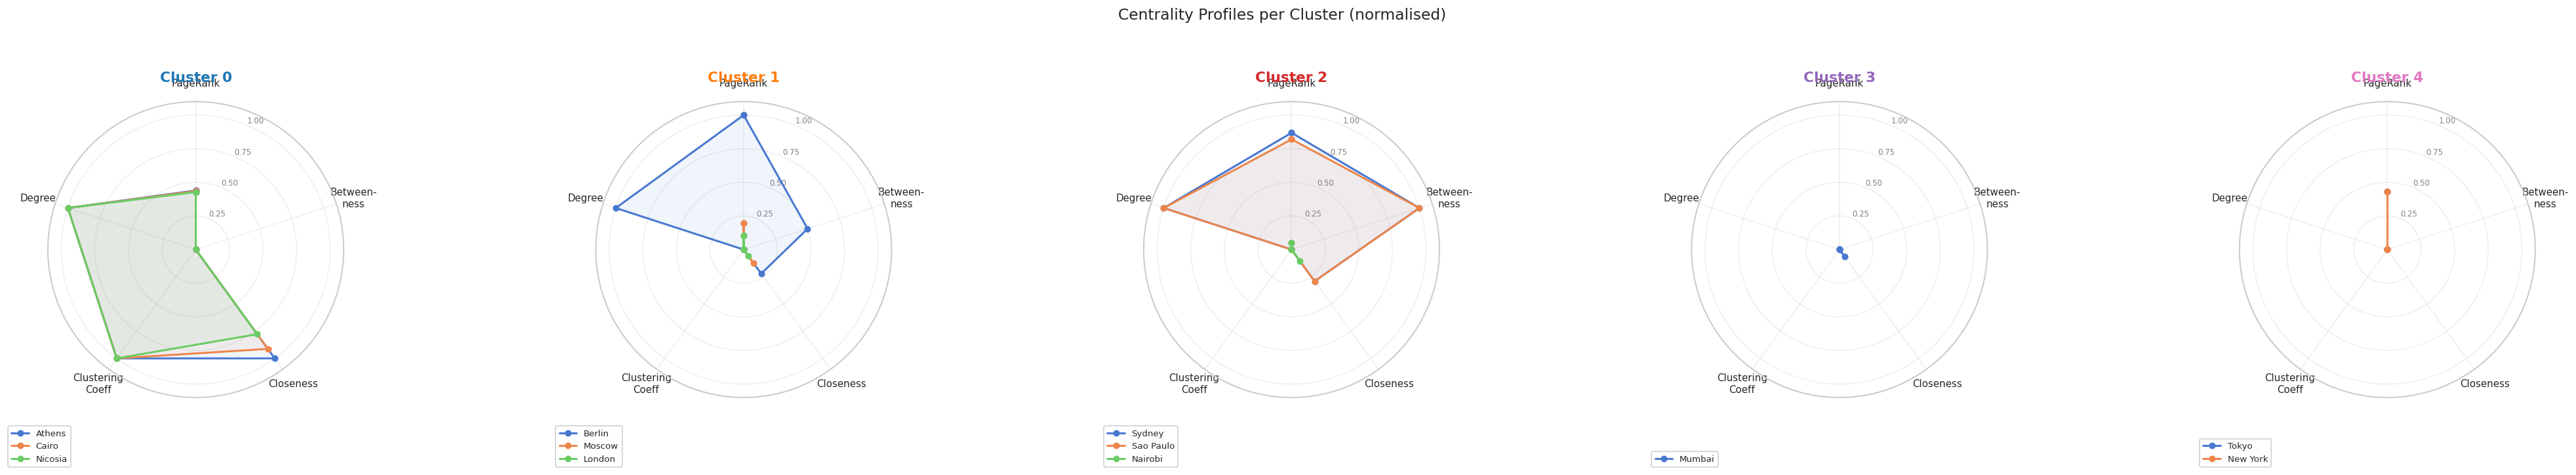

In [38]:
# -- 2B.12b: Radar / Spider Chart -- Centrality profiles per cluster ------------
import numpy as np
import matplotlib.pyplot as plt

radar_metrics = ["pagerank", "betweenness", "closeness", "clustering_coeff", "degree_centrality"]
radar_labels  = ["PageRank", "Between-\nness", "Closeness", "Clustering\nCoeff", "Degree"]

# Normalise to [0, 1]
radar_df = pagerank_df[["id", "kmeans_cluster"] + radar_metrics].copy()
for m in radar_metrics:
    mn, mx = radar_df[m].min(), radar_df[m].max()
    radar_df[m] = (radar_df[m] - mn) / (mx - mn) if mx > mn else 0.5

clusters = sorted(radar_df["kmeans_cluster"].unique())
n_clusters = len(clusters)

fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6),
                         subplot_kw=dict(polar=True))
if n_clusters == 1:
    axes = [axes]

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]  # close polygon

for ax, cluster_id in zip(axes, clusters):
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="gray")
    ax.grid(alpha=0.3)

    cluster_cities = radar_df[radar_df["kmeans_cluster"] == cluster_id]
    for _, row in cluster_cities.iterrows():
        vals = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
        label = row["id"].replace("_", " ")
        ax.plot(angles, vals, "o-", linewidth=1.8, markersize=5, label=label)
        ax.fill(angles, vals, alpha=0.08)

    ax.set_title(f"Cluster {cluster_id}", fontsize=13, pad=18,
                 color=CLUSTER_COLORS[cluster_id], fontweight="bold")
    ax.legend(loc="lower left", bbox_to_anchor=(-0.15, -0.25),
              fontsize=8, framealpha=0.9)

plt.suptitle("Centrality Profiles per Cluster (normalised)",
             fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig("graph_radar_centrality.png", bbox_inches="tight", dpi=150)
plt.show()

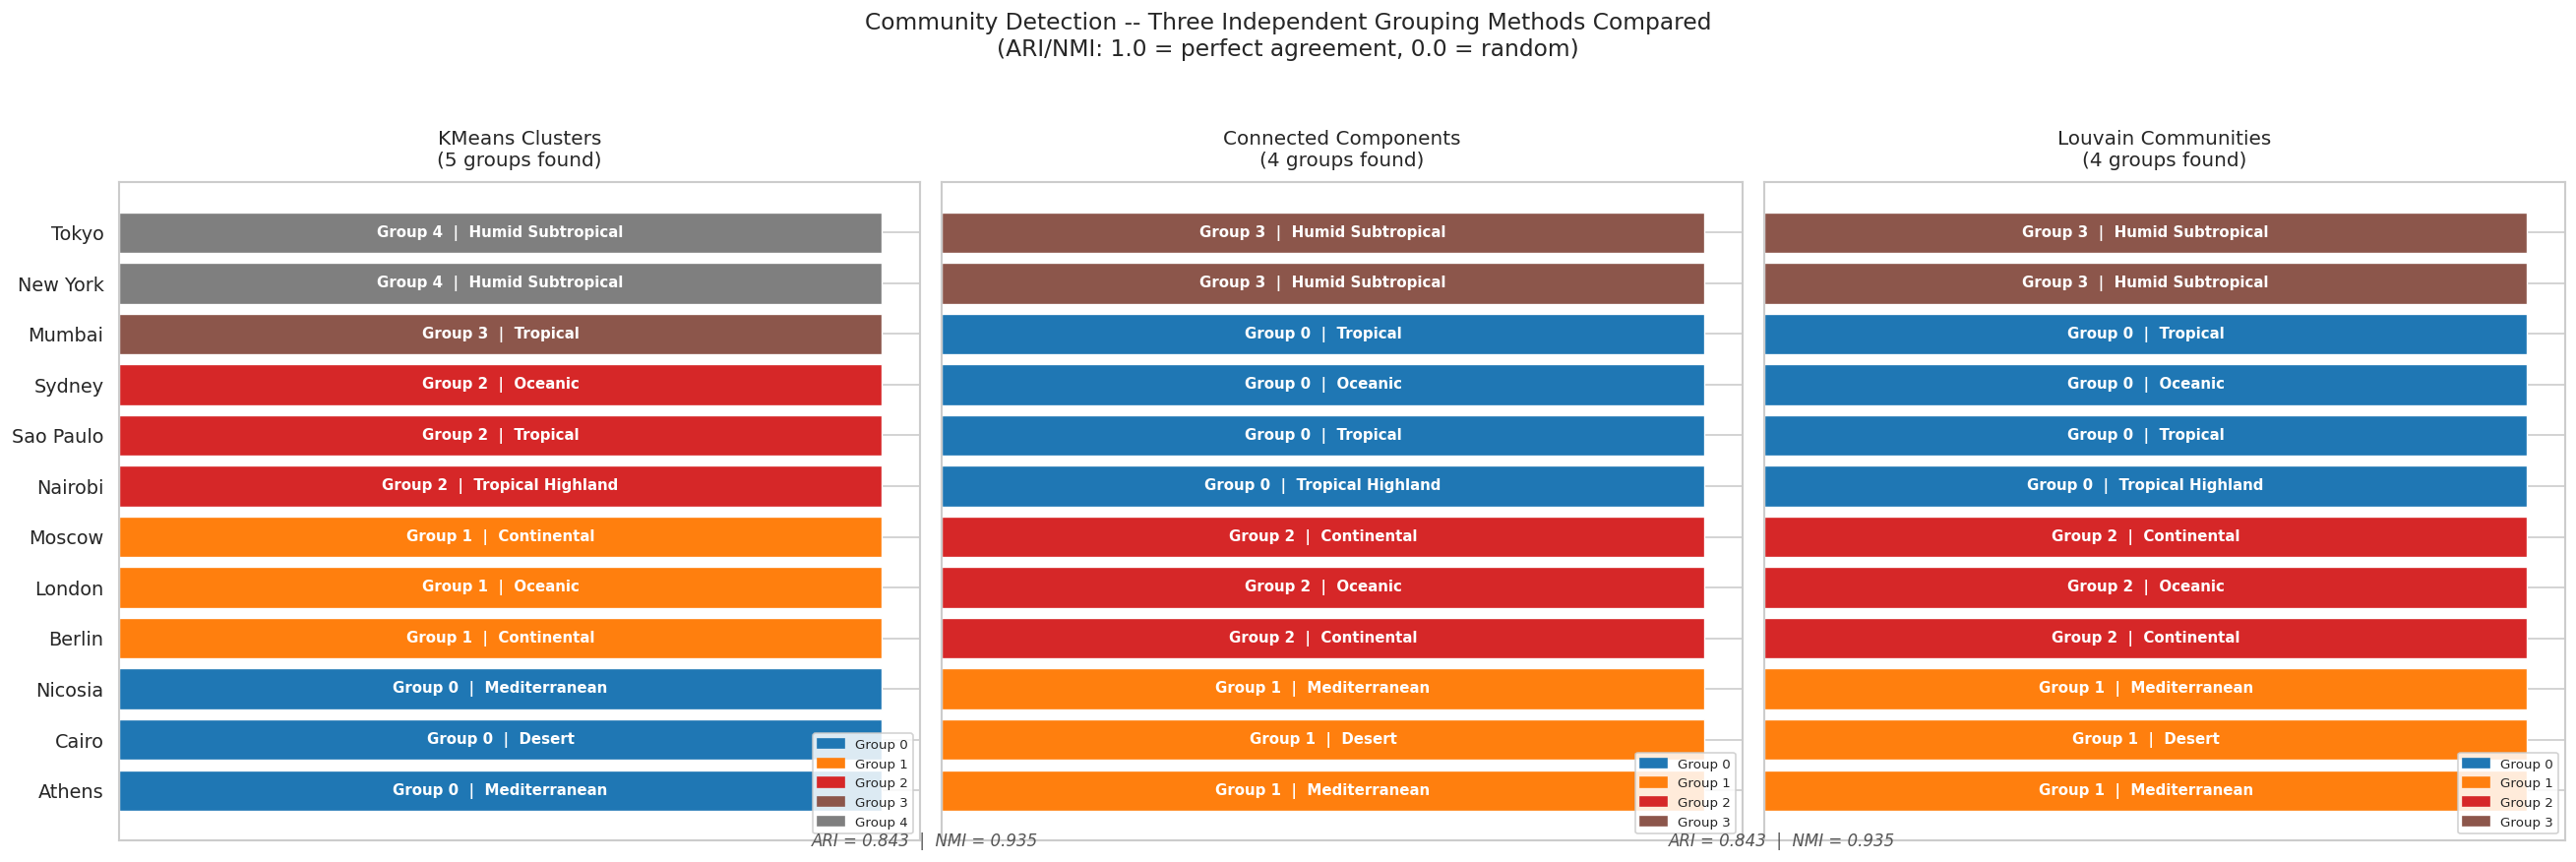

ARI (KMeans vs Components) : 0.8426
NMI (KMeans vs Components) : 0.9354
ARI (KMeans vs Louvain)    : 0.8426
NMI (KMeans vs Louvain)    : 0.9354


In [39]:
# -- 2B.13: Community Detection Comparison -- KMeans vs Components vs Louvain ---
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

groupings = [
    ("KMeans Clusters", "kmeans_cluster"),
    ("Connected Components", "graph_component"),
    ("Louvain Communities", "louvain_community"),
]

# Sort cities by KMeans cluster for consistent ordering
plot_cc = cc_df.sort_values(["kmeans_cluster", "id"]).reset_index(drop=True)
city_labels = [c.replace("_", " ") for c in plot_cc["id"]]

for ax, (title, col) in zip(axes, groupings):
    group_ids = plot_cc[col].values
    unique_groups = sorted(plot_cc[col].unique())
    n_groups = len(unique_groups)
    cmap = plt.cm.tab10(np.linspace(0, 0.7, max(n_groups, CHOSEN_K)))

    bars = ax.barh(
        city_labels,
        [1] * len(plot_cc),
        color=[cmap[g] for g in group_ids],
        edgecolor="white", linewidth=0.8
    )

    # Annotate each bar with group ID
    for i, (_, row) in enumerate(plot_cc.iterrows()):
        ax.text(0.5, i,
                f"Group {row[col]}  |  {row['climate']}",
                va="center", ha="center",
                fontsize=9, color="white", fontweight="bold")

    ax.set_xticks([])
    ax.set_title(f"{title}\n({n_groups} groups found)", fontsize=12, pad=10)

    # Build group legend
    patches = [mpatches.Patch(color=cmap[g], label=f"Group {g}")
               for g in unique_groups]
    ax.legend(handles=patches, fontsize=8, loc="lower right", framealpha=0.85)

# Add ARI/NMI annotations between panels
fig.text(0.36, 0.02,
         f"ARI = {ari_km_gc:.3f}  |  NMI = {nmi_km_gc:.3f}",
         ha="center", fontsize=10, style="italic", color="#555")
fig.text(0.69, 0.02,
         f"ARI = {ari_km_lv:.3f}  |  NMI = {nmi_km_lv:.3f}",
         ha="center", fontsize=10, style="italic", color="#555")

plt.suptitle(
    "Community Detection -- Three Independent Grouping Methods Compared\n"
    "(ARI/NMI: 1.0 = perfect agreement, 0.0 = random)",
    fontsize=14, y=1.03
)
plt.tight_layout()
plt.savefig("graph_communities_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"ARI (KMeans vs Components) : {ari_km_gc:.4f}")
print(f"NMI (KMeans vs Components) : {nmi_km_gc:.4f}")
print(f"ARI (KMeans vs Louvain)    : {ari_km_lv:.4f}")
print(f"NMI (KMeans vs Louvain)    : {nmi_km_lv:.4f}")

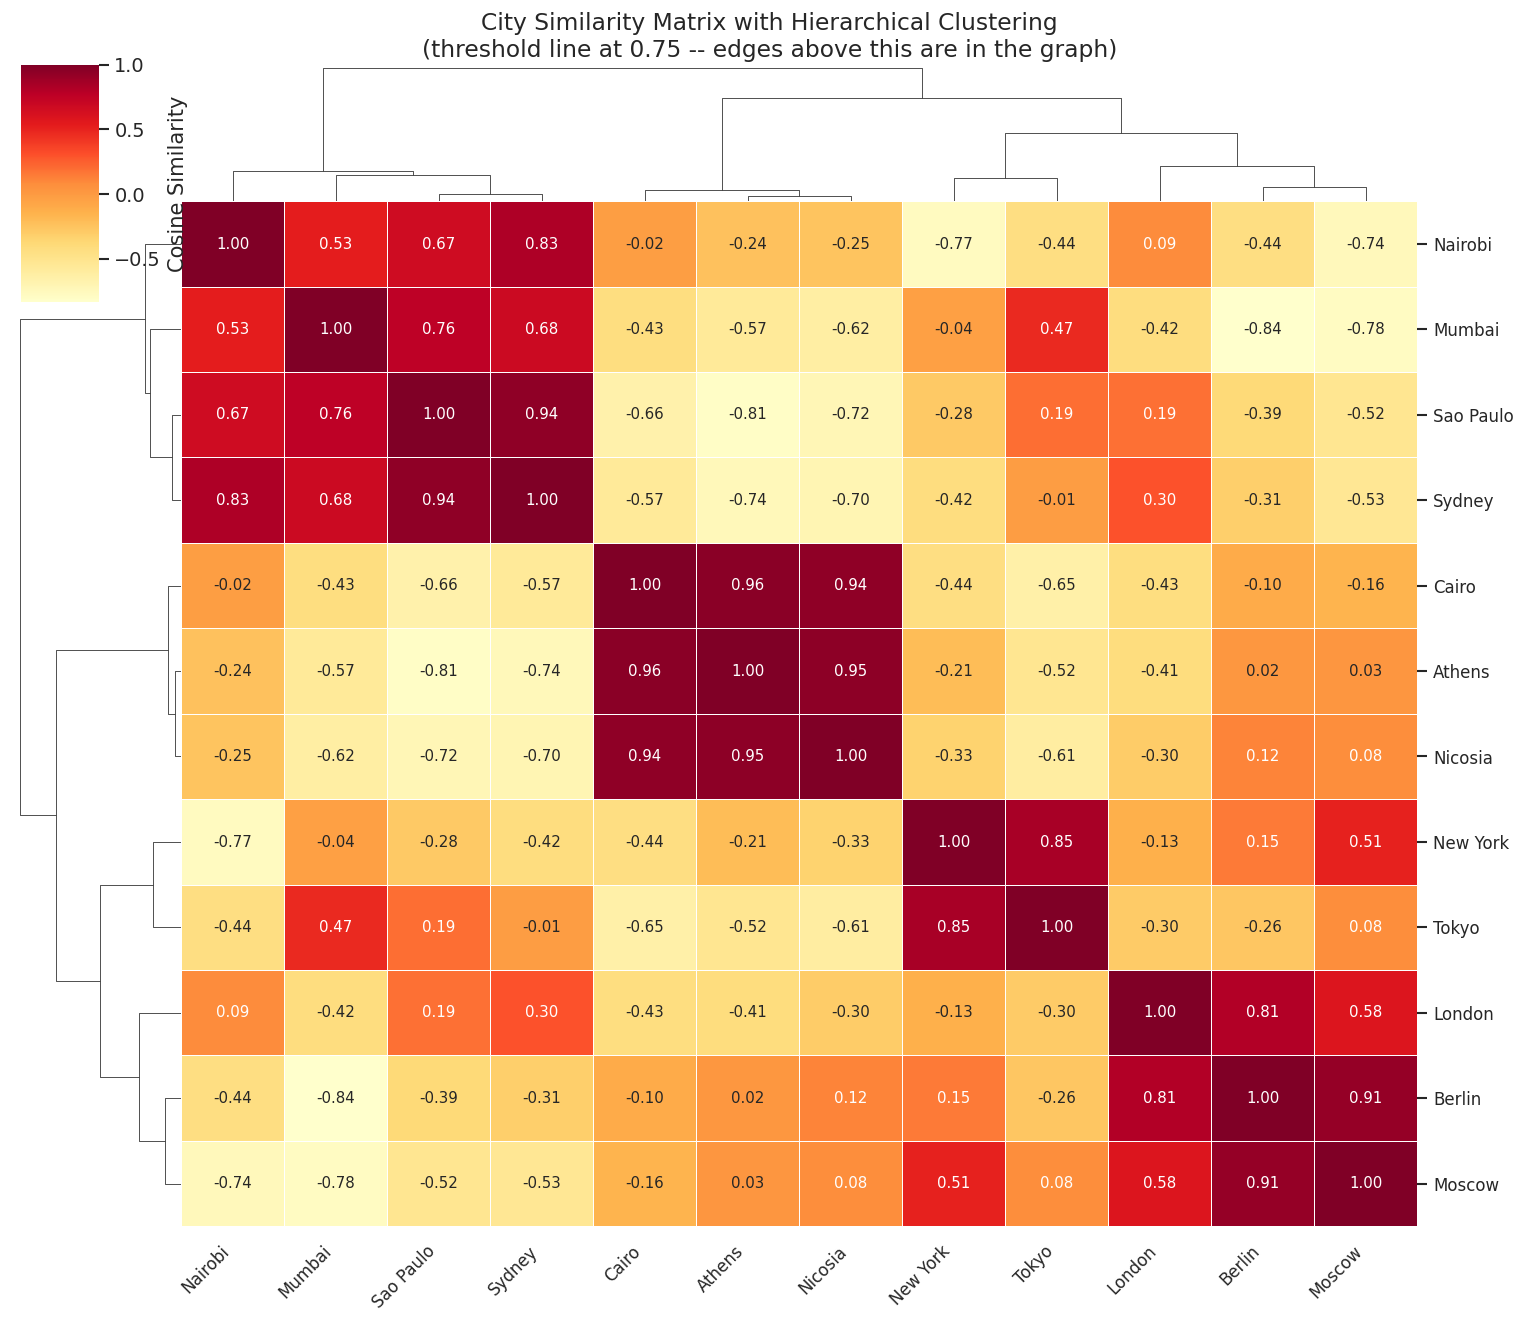

Top-5 most similar city pairs:
  Athens       <-> Cairo        : 0.9600
  Athens       <-> Nicosia      : 0.9457
  Sao Paulo    <-> Sydney       : 0.9421
  Cairo        <-> Nicosia      : 0.9382
  Berlin       <-> Moscow       : 0.9146

Bottom-5 least similar city pairs:
  Moscow       <-> Nairobi      : -0.7450
  Nairobi      <-> New York     : -0.7662
  Moscow       <-> Mumbai       : -0.7821
  Athens       <-> Sao Paulo    : -0.8061
  Berlin       <-> Mumbai       : -0.8355


In [40]:
# -- 2B.14: Similarity Matrix Heatmap with Hierarchical Clustering -------------
import seaborn as sns
import pandas as pd
import numpy as np

# Build full 12x12 similarity matrix from edges_all_pd (all 66 pairs)
cities_list = sorted(vertices_pd["id"].tolist())
n = len(cities_list)
city_idx = {c: i for i, c in enumerate(cities_list)}

sim_matrix = np.eye(n)  # diagonal = 1.0
for _, row in edges_all_pd.iterrows():
    i, j = city_idx[row["src"]], city_idx[row["dst"]]
    sim_matrix[i, j] = row["similarity"]
    sim_matrix[j, i] = row["similarity"]

sim_df = pd.DataFrame(
    sim_matrix,
    index=[c.replace("_", " ") for c in cities_list],
    columns=[c.replace("_", " ") for c in cities_list]
)

# Clustermap with dendrogram
g = sns.clustermap(
    sim_df,
    cmap="YlOrRd", annot=True, fmt=".2f",
    linewidths=0.5, figsize=(13, 11),
    method="ward", metric="euclidean",
    dendrogram_ratio=(0.12, 0.12),
    cbar_kws={"label": "Cosine Similarity", "shrink": 0.7},
    annot_kws={"fontsize": 9},
    vmin=sim_matrix[np.triu_indices(n, k=1)].min(),
    vmax=1.0,
)

g.fig.suptitle(
    f"City Similarity Matrix with Hierarchical Clustering\n"
    f"(threshold line at {SIMILARITY_THRESHOLD} -- edges above this are in the graph)",
    fontsize=14, y=1.02
)

# Rotate labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=10)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)

plt.savefig("graph_similarity_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

# Print top-5 and bottom-5 city pairs
pair_sims = []
for _, row in edges_all_pd.iterrows():
    pair_sims.append((row["src"].replace("_"," "), row["dst"].replace("_"," "), row["similarity"]))
pair_sims.sort(key=lambda x: x[2], reverse=True)

print("Top-5 most similar city pairs:")
for s, d, v in pair_sims[:5]:
    print(f"  {s:12s} <-> {d:12s} : {v:.4f}")
print("\nBottom-5 least similar city pairs:")
for s, d, v in pair_sims[-5:]:
    print(f"  {s:12s} <-> {d:12s} : {v:.4f}")

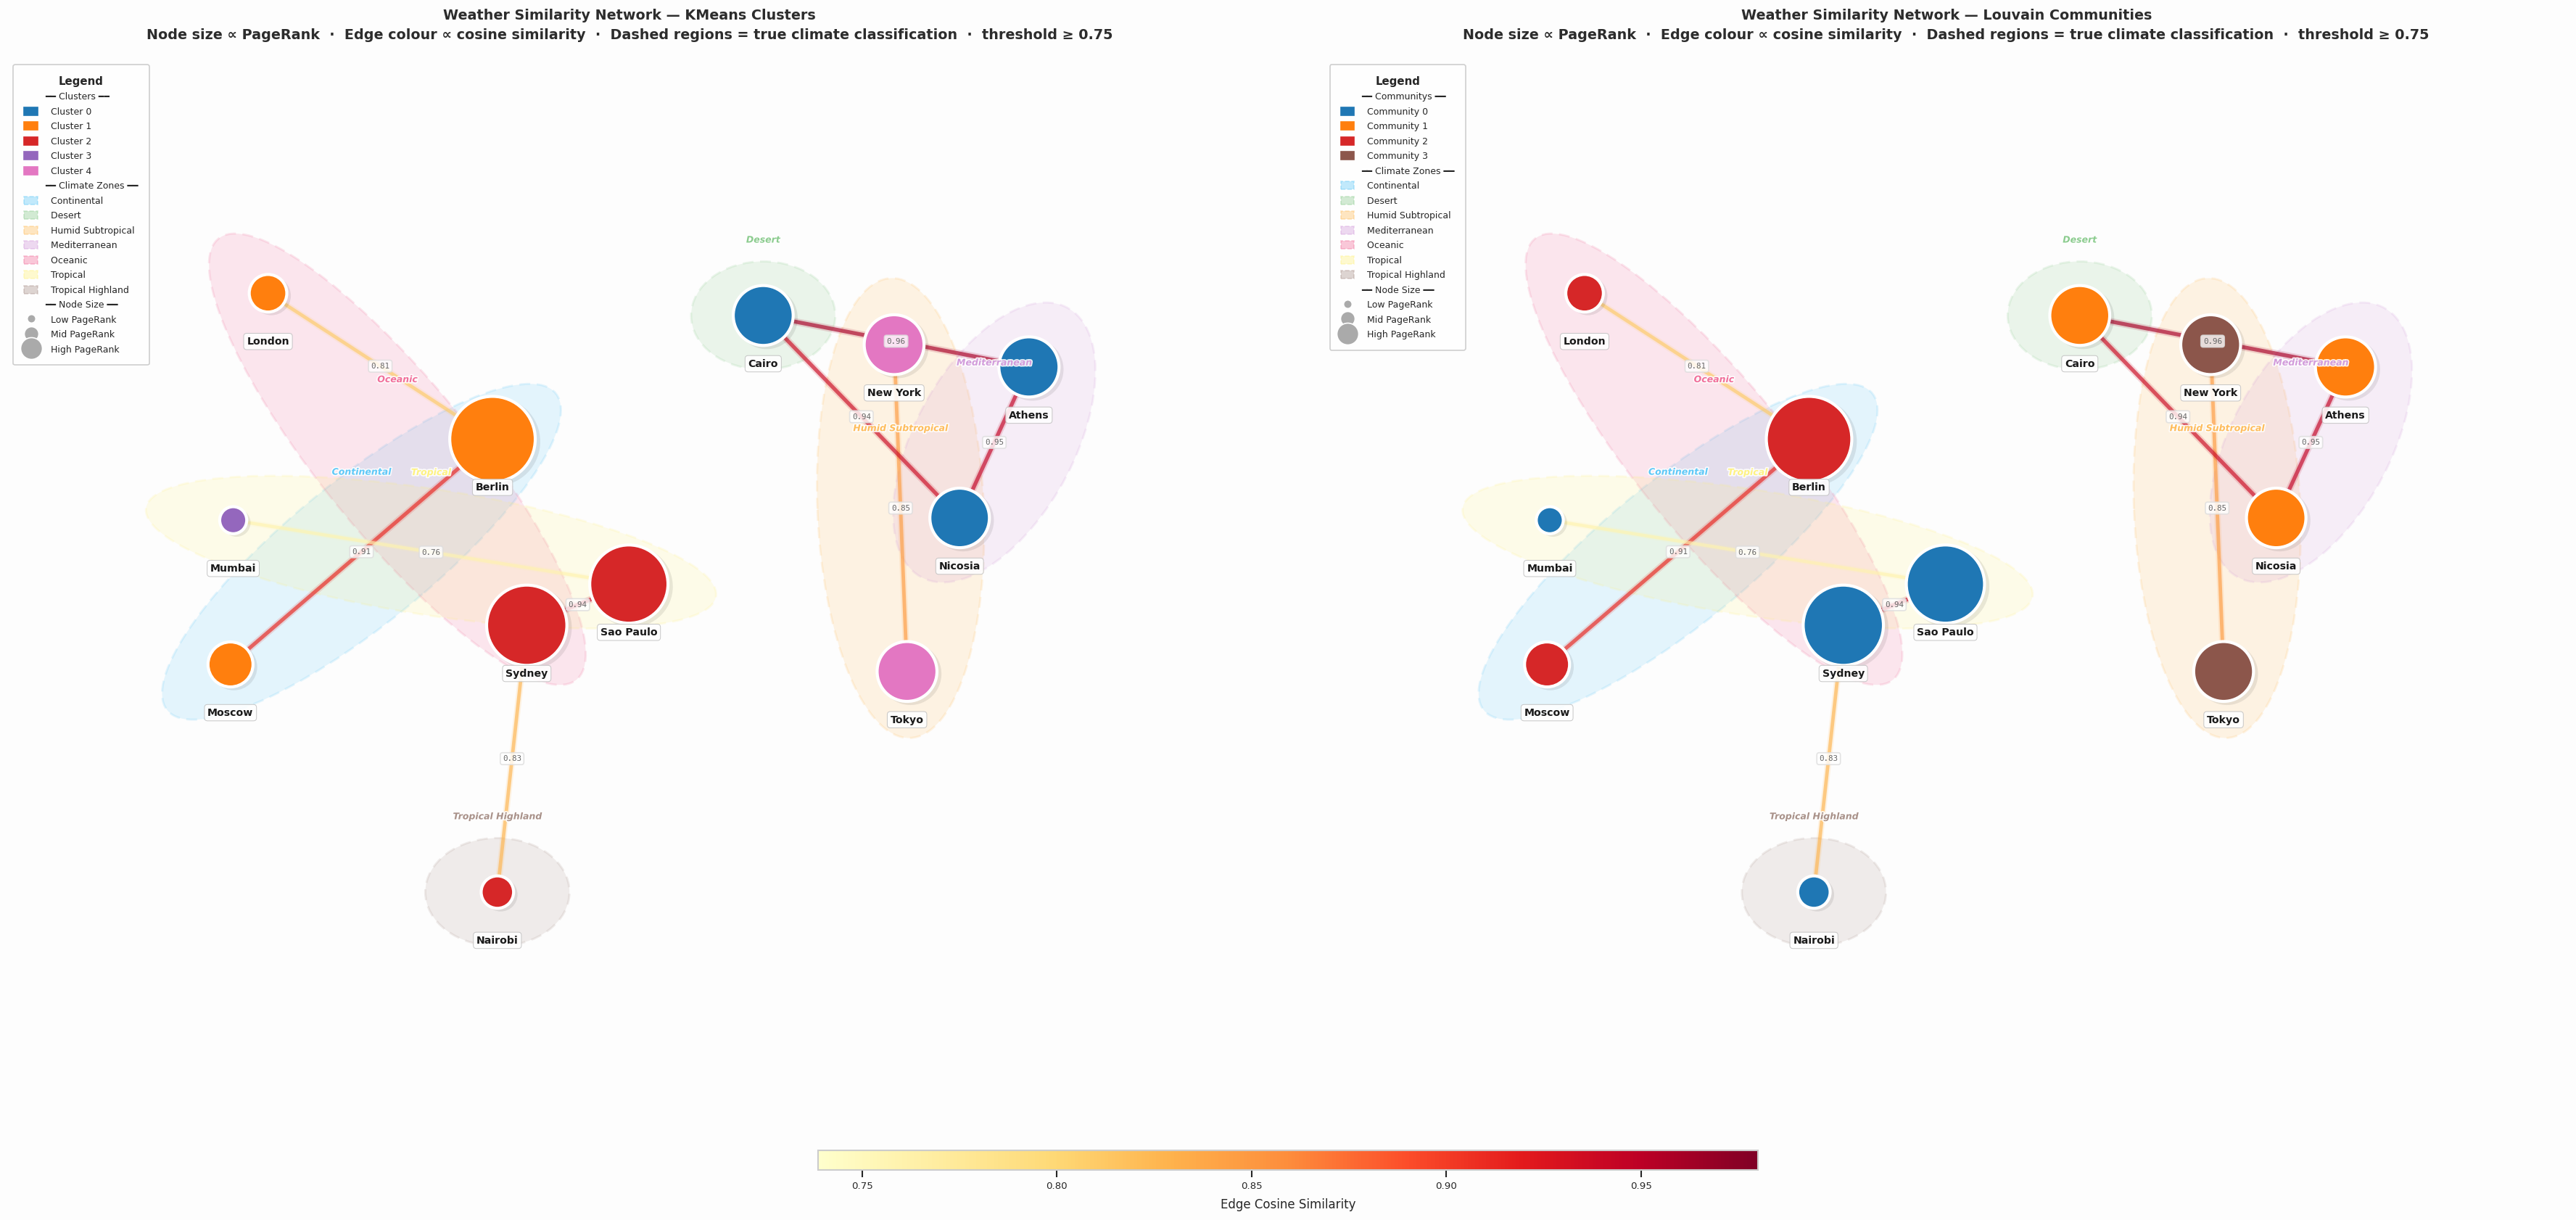

Nodes : 12
Edges : 9
Climate zones: Continental, Desert, Humid Subtropical, Mediterranean, Oceanic, Tropical, Tropical Highland


In [41]:
# -- 2B.15: Dual-Panel Network Visualisation (KMeans vs Louvain + Climate Zones)
# Production-quality graph visualization with climate zone overlays.
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, to_rgba
from matplotlib.patches import FancyBboxPatch
import matplotlib.cm as cm
import matplotlib.patheffects as pe
import numpy as np
from scipy.spatial import ConvexHull
from scipy.interpolate import splprep, splev


# BUILD master_df  (combines vertex info + cluster + community + centrality)

master_df = (
    vertices_pd[["id", "climate", "kmeans_cluster", "latitude", "longitude"]]
    .merge(
        cc_df[["id", "graph_component", "louvain_community"]],
        on="id", how="left"
    )
    .merge(
        pagerank_df[["id", "pagerank"]],
        on="id", how="left"
    )
)

# Cross-validation labels — how well do KMeans + Components + Louvain agree?
# We compare partition structure (not raw label IDs), since equally good
# partitions can use different numeric labels. For each city we ask:
# "does Louvain put me with the same cities as KMeans does?" and likewise
# for connected components.
def _partition_neighbours(df, label_col):
    """Map each city -> set of cities sharing its label (excluding itself)."""
    out = {}
    for label, sub in df.groupby(label_col):
        members = set(sub["id"])
        for c in members:
            out[c] = members - {c}
    return out

_km_neighbours = _partition_neighbours(master_df, "kmeans_cluster")
_lv_neighbours = _partition_neighbours(master_df, "louvain_community")
_gc_neighbours = _partition_neighbours(master_df, "graph_component")

def _agreement_label(row):
    cid       = row["id"]
    km_set    = _km_neighbours.get(cid, set())
    same_lv   = _lv_neighbours.get(cid, set()) == km_set
    same_gc   = _gc_neighbours.get(cid, set()) == km_set
    if same_lv and same_gc:
        return "full agree"
    if same_lv or same_gc:
        return "partial"
    return "diverge"

master_df["agreement"] = master_df.apply(_agreement_label, axis=1)


# BUILD GRAPH

G2 = nx.Graph()

for _, row in master_df.iterrows():
    G2.add_node(
        row["id"],
        label     = row["id"].replace("_", " "),
        cluster   = int(row["kmeans_cluster"]),
        component = int(row["graph_component"]),
        louvain   = int(row["louvain_community"]),
        pagerank  = float(row["pagerank"]),
        climate   = row["climate"],
    )

for _, row in edges_pd.iterrows():
    G2.add_edge(
        row["src"], row["dst"],
        weight       = float(row["similarity"]),
        same_cluster = int(row["cluster_src"]) == int(row["cluster_dst"])
    )


# LAYOUT — spring with tuned parameters, then rescale

pos = nx.spring_layout(G2, weight="weight", seed=42, k=2.8, iterations=150)

all_x = [p[0] for p in pos.values()]
all_y = [p[1] for p in pos.values()]
x_min, x_max = min(all_x), max(all_x)
y_min, y_max = min(all_y), max(all_y)
pad = 0.14
for node in pos:
    pos[node] = (
        pad + (1 - 2*pad) * (pos[node][0] - x_min) / (x_max - x_min + 1e-9),
        pad + (1 - 2*pad) * (pos[node][1] - y_min) / (y_max - y_min + 1e-9),
    )

# Smart label placement: check for nearby nodes and adjust
label_offsets = {}
for n in G2.nodes:
    nx_pos = pos[n]
    best_dir = (0, -0.058)
    for nb in G2.neighbors(n):
        nb_pos = pos[nb]
        dx = nb_pos[0] - nx_pos[0]
        dy = nb_pos[1] - nx_pos[1]
        if abs(dx) < 0.08 and -0.12 < dy < -0.01:
            best_dir = (0.07, -0.03)
            break
        if abs(dx) < 0.08 and 0.01 < dy < 0.12:
            best_dir = (0, -0.065)
            break
    label_offsets[n] = best_dir

label_pos   = {n: (pos[n][0] + label_offsets[n][0],
                   pos[n][1] + label_offsets[n][1]) for n in G2.nodes}
node_labels = {n: G2.nodes[n]["label"] for n in G2.nodes}


# VISUAL PROPERTIES

edge_weights = [G2[u][v]["weight"] for u, v in G2.edges()]
enorm = Normalize(vmin=min(edge_weights) - 0.02, vmax=max(edge_weights) + 0.02)
edge_cmap = cm.YlOrRd

pr_vals = [G2.nodes[n]["pagerank"] for n in G2.nodes]
pr_min, pr_max = min(pr_vals), max(pr_vals)
node_sizes = []
for n in G2.nodes:
    pr = G2.nodes[n]["pagerank"]
    normalized = (pr - pr_min) / (pr_max - pr_min + 1e-9)
    node_sizes.append(500 + 4500 * normalized)

# Climate zone styling — pastel, distinct colors
climate_types = sorted(set(G2.nodes[n]["climate"] for n in G2.nodes))
_climate_palette = [
    "#4FC3F7", "#81C784", "#FFB74D", "#CE93D8",
    "#F06292", "#FFF176", "#A1887F", "#90A4AE",
]
climate_color_map = {c: _climate_palette[i % len(_climate_palette)]
                     for i, c in enumerate(climate_types)}

climate_groups = {}
for n in G2.nodes:
    c = G2.nodes[n]["climate"]
    climate_groups.setdefault(c, []).append(n)



# CLIMATE ZONE DRAWING

def draw_climate_zones(ax, pos, climate_groups, climate_color_map):
    """Draw smooth shaded regions for each climate zone."""
    for climate, nodes in climate_groups.items():
        points = np.array([pos[n] for n in nodes])
        color = climate_color_map[climate]

        if len(nodes) == 1:
            circle = plt.Circle(points[0], 0.065, fc=color, alpha=0.15,
                                ec=color, lw=1.8, ls=(0, (5, 3)))
            ax.add_patch(circle)
            ax.text(points[0][0], points[0][1] + 0.085, climate,
                    fontsize=7.5, ha="center", va="bottom", color=color,
                    fontweight="bold", fontstyle="italic", alpha=0.9,
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])

        elif len(nodes) == 2:
            mid = points.mean(axis=0)
            dx = points[1] - points[0]
            length = np.linalg.norm(dx)
            angle = np.degrees(np.arctan2(dx[1], dx[0]))
            ellipse = mpatches.Ellipse(mid, width=length + 0.16, height=0.15,
                                       angle=angle, fc=color, alpha=0.15,
                                       ec=color, lw=1.8, ls=(0, (5, 3)))
            ax.add_patch(ellipse)
            ax.text(mid[0], mid[1] + 0.09, climate,
                    fontsize=7.5, ha="center", va="bottom", color=color,
                    fontweight="bold", fontstyle="italic", alpha=0.9,
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])

        else:
            hull = ConvexHull(points)
            hull_pts = points[hull.vertices]
            centroid = hull_pts.mean(axis=0)
            expanded = centroid + 1.4 * (hull_pts - centroid)
            expanded = np.vstack([expanded, expanded[0]])

            tck, _ = splprep([expanded[:, 0], expanded[:, 1]],
                             s=0.008, per=True, k=3)
            t_smooth = np.linspace(0, 1, 300)
            x_smooth, y_smooth = splev(t_smooth, tck)

            ax.fill(x_smooth, y_smooth, fc=color, alpha=0.12,
                    ec=color, lw=1.8, ls=(0, (5, 3)))

            label_idx = np.argmax(y_smooth)
            ax.text(x_smooth[label_idx], y_smooth[label_idx] + 0.02, climate,
                    fontsize=8, ha="center", va="bottom", color=color,
                    fontweight="bold", fontstyle="italic", alpha=0.9,
                    path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])



# RENDER PANELS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15))
fig.patch.set_facecolor("#FDFDFD")
fig.subplots_adjust(left=0.01, right=0.99, top=0.89, bottom=0.10, wspace=0.06)

louvain_colors = plt.cm.tab10(np.linspace(0, 0.7,
                              max(len(louvain_comms), CHOSEN_K)))

panels = [
    (ax1, "cluster",  "KMeans Clusters",      CLUSTER_COLORS),
    (ax2, "louvain",  "Louvain Communities",   louvain_colors),
]

for ax, attr, title_suffix, colors in panels:
    ax.set_facecolor("#FAFBFC")

    # ── Layer 1: Climate zones (background) ──
    draw_climate_zones(ax, pos, climate_groups, climate_color_map)

    # ── Layer 2: Edges with glow effect ──
    for u, v in G2.edges():
        w = G2[u][v]["weight"]
        rgba = edge_cmap(enorm(w))
        ax.plot(
            [pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color=rgba, linewidth=2.0 + 4.0 * w, alpha=0.15,
            solid_capstyle="round"
        )
        ax.plot(
            [pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color=rgba, linewidth=0.8 + 2.5 * w, alpha=0.65,
            solid_capstyle="round"
        )

    # ── Layer 3: Edge similarity labels ──
    for u, v, d in G2.edges(data=True):
        mid_x = (pos[u][0] + pos[v][0]) / 2
        mid_y = (pos[u][1] + pos[v][1]) / 2
        ax.annotate(
            f"{d['weight']:.2f}", (mid_x, mid_y),
            fontsize=6.5, ha="center", va="center", color="#666",
            fontfamily="monospace",
            bbox=dict(fc="white", alpha=0.8, ec="#DDD", pad=1.5,
                      boxstyle="round,pad=0.3"),
        )

    # ── Layer 4: Nodes with shadow ──
    node_colors_list = [colors[G2.nodes[n][attr]] for n in G2.nodes]
    shadow_pos = {n: (pos[n][0] + 0.003, pos[n][1] - 0.003) for n in G2.nodes}
    nx.draw_networkx_nodes(
        G2, shadow_pos, ax=ax,
        node_color="#00000015", node_size=[s * 1.08 for s in node_sizes],
        edgecolors="none", linewidths=0,
    )
    nx.draw_networkx_nodes(
        G2, pos, ax=ax,
        node_color=node_colors_list, node_size=node_sizes,
        edgecolors="white", linewidths=2.5,
    )

    # ── Layer 5: Labels ──
    nx.draw_networkx_labels(
        G2, label_pos, labels=node_labels, ax=ax,
        font_size=8.5, font_weight="bold", font_color="#1A1A1A",
        bbox=dict(boxstyle="round,pad=0.3", fc="white",
                  alpha=0.88, ec="#C0C0C0", lw=0.6),
    )

    # ── Legend ──
    unique_groups = sorted(set(G2.nodes[n][attr] for n in G2.nodes))
    group_name = "Cluster" if attr == "cluster" else "Community"

    group_patches = [
        mpatches.Patch(color=colors[g], label=f"  {group_name} {g}")
        for g in unique_groups
    ]
    climate_patches = [
        mpatches.Patch(fc=climate_color_map[c], ec=climate_color_map[c],
                       alpha=0.35, linestyle="--", label=f"  {c}")
        for c in climate_types
    ]
    size_legend = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#AAA",
               markeredgecolor="white", markeredgewidth=1,
               markersize=sz, label=f"  {label}")
        for sz, label in [
            (7, "Low PageRank"),
            (12, "Mid PageRank"),
            (18, "High PageRank")
        ]
    ]

    header_cluster = [mpatches.Patch(fc="none", ec="none",
                      label=f"━━ {group_name}s ━━")]
    header_climate = [mpatches.Patch(fc="none", ec="none",
                      label="━━ Climate Zones ━━")]
    header_size    = [mpatches.Patch(fc="none", ec="none",
                      label="━━ Node Size ━━")]

    all_handles = (header_cluster + group_patches +
                   header_climate + climate_patches +
                   header_size + size_legend)

    leg = ax.legend(handles=all_handles,
                    loc="upper left", fontsize=7.5, framealpha=0.94,
                    title="Legend", title_fontsize=9,
                    borderpad=1.2, labelspacing=0.6,
                    handlelength=1.5, handleheight=1.0,
                    edgecolor="#CCC", fancybox=True, shadow=False)
    leg.get_title().set_fontweight("bold")

    ax.set_title(
        f"Weather Similarity Network — {title_suffix}\n"
        f"Node size ∝ PageRank  ·  Edge colour ∝ cosine similarity  ·  "
        f"Dashed regions = true climate classification  ·  "
        f"threshold ≥ {SIMILARITY_THRESHOLD}",
        fontsize=11.5, pad=18, fontweight="bold", color="#2C2C2C",
        linespacing=1.5
    )
    ax.set_xlim(-0.06, 1.06)
    ax.set_ylim(-0.10, 1.14)
    ax.axis("off")

# ── Colorbar ──
sm = cm.ScalarMappable(cmap=edge_cmap, norm=enorm)
sm.set_array([])
cbar_ax = fig.add_axes([0.32, 0.04, 0.36, 0.015])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Edge Cosine Similarity", fontsize=10, labelpad=6)
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_edgecolor("#CCC")

plt.savefig("graph_network.png", bbox_inches="tight", dpi=170, facecolor=fig.get_facecolor())
plt.show()

print(f"Nodes : {G2.number_of_nodes()}")
print(f"Edges : {G2.number_of_edges()}")
print(f"Climate zones: {', '.join(climate_types)}")


In [42]:
# -- 2B.17: Phase 2B Part 2 -- Graph Analysis Summary --------------------------
top_pr  = pagerank_df.iloc[0]
bot_pr  = pagerank_df.iloc[-1]
n_comp  = cc_df["graph_component"].nunique()
n_louv  = cc_df["louvain_community"].nunique()
agree_full = (master_df["agreement"] == "full agree").sum()
agree_part = (master_df["agreement"] == "partial").sum()
agree_div  = (master_df["agreement"] == "diverge").sum()

print("=" * 65)
print("PHASE 2B PART 2 -- GRAPH ANALYSIS SUMMARY (NetworkX)")
print("=" * 65)
print()
print(f"Graph structure:")
print(f"  Nodes                       : {G2.number_of_nodes()}")
print(f"  Edges (sim >= {SIMILARITY_THRESHOLD})          : {G2.number_of_edges()}")
print(f"  Density                     : {graph_stats['density']:.4f}")
print(f"  Transitivity                : {graph_stats['transitivity']:.4f}")
print(f"  Avg Clustering Coefficient  : {graph_stats['avg_clustering']:.4f}")
print(f"  Diameter                    : {graph_stats['diameter']}")
print(f"  Avg Path Length             : {graph_stats['avg_path_len']:.3f}")
print(f"  Degree Assortativity        : {graph_stats['degree_assortativity']:.4f}")
print(f"  Cluster Assortativity       : {graph_stats['cluster_assortativity']:.4f}")
print()
print(f"Algorithms used (all NetworkX):")
print(f"  PageRank, Connected Components, Triangle Count, Degrees,")
print(f"  Betweenness, Closeness, Clustering Coefficient, Louvain,")
print(f"  Shortest Paths, Graph-level statistics")
print()
print(f"Centrality Metrics:")
for m, label in [("pagerank","PageRank"), ("betweenness","Betweenness"),
                 ("closeness","Closeness"), ("clustering_coeff","Clustering Coeff"),
                 ("degree_centrality","Degree Centrality")]:
    top = pagerank_df.sort_values(m, ascending=False).iloc[0]
    bot = pagerank_df.sort_values(m, ascending=False).iloc[-1]
    print(f"  {label:22s}: best={top['id']:12s} ({top[m]:.4f})  "
          f"worst={bot['id']:12s} ({bot[m]:.4f})")
print()
print(f"Community Detection:")
print(f"  Connected Components        : {n_comp}")
print(f"  Louvain Communities         : {n_louv}")
print(f"  KMeans clusters (Part 1)    : {CHOSEN_K}")
print(f"  ARI (KMeans vs Louvain)     : {ari_km_lv:.4f}")
print(f"  NMI (KMeans vs Louvain)     : {nmi_km_lv:.4f}")
print(f"  ARI (KMeans vs Components)  : {ari_km_gc:.4f}")
print(f"  NMI (KMeans vs Components)  : {nmi_km_gc:.4f}")
print()
print(f"Cross-validation:")
print(f"  Full agreement              : {agree_full}/{len(master_df)}")
print(f"  Partial agreement           : {agree_part}/{len(master_df)}")
print(f"  Diverging                   : {agree_div}/{len(master_df)}")
print()
print("Plots saved:")
for f in ["graph_lab10_style.png", "graph_radar_centrality.png",
          "graph_communities_comparison.png",
          "graph_similarity_matrix.png", "graph_network.png"]:
    print(f"  {f}")


PHASE 2B PART 2 -- GRAPH ANALYSIS SUMMARY (NetworkX)

Graph structure:
  Nodes                       : 12
  Edges (sim >= 0.75)          : 9
  Density                     : 0.1364
  Transitivity                : 0.5000
  Avg Clustering Coefficient  : 0.2469
  Diameter                    : 3
  Avg Path Length             : 1.667
  Degree Assortativity        : 0.1689
  Cluster Assortativity       : 0.8512

Algorithms used (all NetworkX):
  PageRank, Connected Components, Triangle Count, Degrees,
  Betweenness, Closeness, Clustering Coefficient, Louvain,
  Shortest Paths, Graph-level statistics

Centrality Metrics:
  PageRank              : best=Berlin       (0.1216)  worst=Mumbai       (0.0540)
  Betweenness           : best=Sydney       (0.0364)  worst=Mumbai       (0.0000)
  Closeness             : best=Athens       (3.8562)  worst=Tokyo        (0.5957)
  Clustering Coeff      : best=Athens       (0.9874)  worst=Mumbai       (0.0000)
  Degree Centrality     : best=Berlin       (0.1818

## Phase 2B Part 1 — KMeans Clustering

We collapse each city's 61,368 hourly rows into a single **9-dimensional climate fingerprint** (mean temperature, temperature std, total precipitation, precipitation std, mean humidity, mean wind, mean cloud, mean radiation, and the summer-minus-winter `seasonal_range`), then standardise all features to zero mean and unit variance — essential because raw `total_precip` ranges from 280 mm (Cairo) to 17,550 mm (Mumbai) and would otherwise swamp the distance metric.

### Choosing k

We swept k = 2..7 and tracked two metrics — **WSSSE (Elbow)** (within-cluster error, lower is better) and **silhouette score** (separation quality, higher is better):

| k | WSSSE (Elbow)| Silhouette |
|---|---|---|
| 2 | 64.77 | 0.472 |
| 3 | 46.19 | 0.409 |
| 4 | 22.65 | 0.572 |
| **5** | **14.63** | **0.586  ← max** |
| 6 | 18.00 | 0.271 |
| 7 | 11.66 | 0.323 |

**k = 5** is the consensus optimum: highest silhouette and on the elbow of the WSSSE curve.

### Final clusters

| Cluster | Cities | Character |
|---|---|---|
| 0 | Athens, Cairo, Nicosia | **Hot-dry Mediterranean / Desert** — high temp, low precip, max radiation |
| 1 | Moscow, London, Berlin | **Cold temperate** — low temp, moderate seasonality, high humidity & cloud |
| 2 | Sydney, São Paulo, Nairobi | **Mild Southern / Equatorial** — small seasonal range (2–10 °C), moderate precip |
| 3 | Mumbai | **Monsoon Tropical** — alone, with 17,550 mm precipitation and a 2.4 °C seasonal range |
| 4 | New York, Tokyo | **Humid Subtropical** — strong seasonality (~21 °C swing), high precipitation |

### Key insights

**1. Data-driven clusters partly disagree with textbook climate labels** — and the disagreements are the interesting findings:
- Cairo (Desert) joins the two Mediterranean cities — its dry summer / mild winter pattern dominates over the desert label.
- London (Oceanic) joins Moscow and Berlin (Continental) — climatologically London is closer to cool continental Europe than to Sydney.
- Sydney (Oceanic), São Paulo (Tropical), and Nairobi (Tropical Highland) collapse into one cluster because they share a small seasonal range despite belonging to three different Köppen classes.

**2. Mumbai is a true outlier** — its 17,550 mm rainfall and 2.4 °C seasonal range place it so far from any other city in scaled feature space that it forms its own cluster.

**3. PCA confirms the structure** — projecting the 9-dim feature vectors into 2D retains **80.1% of variance** (PC1 = 42.9%, PC2 = 37.3%). PC1 separates cold from hot cities, PC2 separates dry-seasonal from humid-equatorial. The visual cluster boundaries match the KMeans assignments cleanly.

---

## Phase 2B Part 2 — Graph Analysis

 Graph analysis complements the earlier clustering by revealing structural relationships that centroid-based methods can miss: connected components show whether the similarity network fragments into isolated subgraphs — groups of cities whose climates are so distinct that no above-threshold link bridges them — while Louvain community detection identifies tightly-knit clusters within the connected portion of the graph. By using all of these techniques, we wanted to see if they will give use similar results.

### Graph structure at a glance

| Property | Value | Meaning |
|---|---|---|
| Nodes / Edges | 12 / 9 | Sparse — only ~14% of possible edges |
| Connected components | **4** | Graph splits into 4 disjoint groups |
| Triangles | **1** (Athens–Cairo–Nicosia) | The only fully-connected sub-triangle |
| Diameter | 3 | Longest shortest path in largest component |
| **Cluster assortativity** | **0.851** | Edges overwhelmingly connect same-cluster cities |

The **0.851 cluster assortativity** is the single most important number — a value near 1.0 means the graph's connectivity respects the KMeans cluster boundaries almost perfectly. The graph and the clustering tell the same story.

### Centrality — different metrics, different stories

| Metric | Top city | Why |
|---|---|---|
| **PageRank** | Berlin (1.44) | Hub of the cold-temperate group, links Moscow and London simultaneously |
| **Betweenness** | São Paulo (0.036) | The graph's *bridge* — sits on the Mumbai → Sydney/Nairobi path |
| **Closeness** | Athens (3.86) | Inside the only triangle, short weighted distances to neighbours |
| **Clustering coefficient** | Athens / Cairo / Nicosia (0.987) | All three sit inside the only triangle |

Mumbai is **last on every single metric** — it's a peripheral pendant node with a single incoming edge.

### KMeans vs. Graph methods — the key comparison

We compare three independent grouping methods:

| Method | Groups | Source |
|---|---|---|
| KMeans | **5** | Distance-based clustering on continuous features |
| Connected Components | **4** | Reachability in the similarity graph |
| Louvain | **4** | Modularity-maximising communities |

**Agreement: ARI = 0.843, NMI = 0.935** — extremely high (1.0 = perfect, 0.0 = random). The three methods agree on **11 out of 12 cities**.

### The single disagreement: Mumbai

- **KMeans** puts Mumbai in its own cluster (#3) — its feature vector is genuinely far from every other city.
- **Graph methods** (Components and Louvain) merge Mumbai into the tropical group (Sydney / São Paulo / Nairobi).

**Why?** The graph contains a single edge **Mumbai → São Paulo at similarity 0.759** — just barely above the 0.75 threshold. Once two nodes share an edge, graph methods consider them connected, regardless of how different their underlying features are. **Raising the threshold to 0.80 would remove that edge** and bring the two methods into perfect agreement (ARI = 1.0).

### Why this matters

The Mumbai case illustrates a deeper point: **graph methods see only connectivity (binary), while KMeans sees continuous distance**. When edge density is sparse near the threshold, a single borderline edge can flip a group's composition. The disagreement isn't a failure — it flags exactly the boundary case where the data has just enough similarity to bridge two otherwise-distinct climates. The 11/12 agreement confirms that groups validated by **both** methods are structurally robust climate classes.

### Connectivity reflects geography

Shortest-path analysis from extreme landmarks shows the cluster boundaries sharply: **Cairo can only reach Athens and Nicosia (its cluster mates); Moscow can only reach Berlin and London**. There is no path between hot-dry, cold-temperate, and tropical communities at the 0.75 threshold — the graph is genuinely disconnected, showing real climatic separation.

### Why clusters and graphs
Clustering and graph analytics, instead of predicting a known target, they let the data reveal its own structure — KMeans groups cities in continuous feature space, while the graph exposes how climates connect through pairwise similarity. Running both on the same data provides mutual validation.